# 01 - Análisis Exploratorio de Datos

## 1. Contexto y Descripción General del Proyecto

Airbnb se ha convertido en una de las principales plataformas de alojamiento en ciudades turísticas y de negocios como la Ciudad de México. La fijación de precios para un alojamiento en Airbnb no es trivial: un precio demasiado alto puede reducir drásticamente la ocupación, mientras que un precio demasiado bajo implica una pérdida directa de ingresos para el anfitrión.

Este proyecto tiene como objetivo construir un modelo de smart pricing que estime y recomiende un precio de referencia para un listing de Airbnb en la Ciudad de México, utilizando información estructural del alojamiento (capacidad, tipo de habitación, ubicación, entre otros), que permita al anfitrión posicionar su alojamiento de manera informada. El modelo será *estático*, es decir, no ajustará precios en función del tiempo, la estacionalidad o señales dinámicas de demanda, sino que aprenderá patrones históricos de precios para generar recomendaciones consistentes y explicables.

Este proyecto se centra en el mercado estándar de rentas de corto plazo en la Ciudad de México, con el objetivo de analizar patrones representativos del comportamiento general de los precios. Los listings con precios extremadamente elevados se consideran fuera del alcance, ya que corresponden a un segmento de mercado distinto con dinámicas particulares que no son comparables con el mercado general. Además, dichos valores pueden incluir posibles errores de calidad en los datos.

En cuanto a la parte técnica, este proyecto está orientado a un escenario realista de ciencia de datos aplicada, priorizando la comprensión del problema, la calidad de los datos y la interpretabilidad del modelo sobre la complejidad técnica o la optimización extrema de métricas.

## 2. Objetivo del Negocio

El objetivo principal de este proyecto es desarrollar un sistema de **smart pricing** que recomiende un precio de referencia para un listing de Airbnb en la Ciudad de México, a partir de sus características estructurales y contextuales.

En este contexto, un “precio recomendado” no se interpreta como una valor óptimo absoluto, sino como una **estimación razonable del mercado**, es decir, un precio que sea coherente con listings similares en condiciones comparables (ubicación, capacidad, tipo de alojamiento, servicios, etc). Más que predecir un único valor puntual, el sistema busca aportar contexto al precio sugerido mediante métricas complementarias, como un rango de precios razonable, el precio promedio de mercado y la posición relativa del listing frente a alojamientos similares.

Este enfoque admite dos escenarios de precios:  
1. Recomendación de precio para nuevos anuncios (*cold-start)* - Anfitriones nuevos que carecen de referencias históricas para fijar precios.
2. Validación de precio para anuncios existentes (*established*) - Anfitriones que desean validar si su precio actual está alineado con el mercado.

El alcance del proyecto es deliberadamente limitado a un modelo estático de recomendación de precios. No se implementan estrategias de dynamic pricing, optimización de ingresos ni ajustes temporales. Esta restricción permite concentrarse en la calidad de los datos, la solidez del modelado y la interpretabilidad de los resultados, estableciendo una base clara y extensible para posibles evoluciones futuras del proyecto.

## 3. Alcance de este notebook

Este notebook se centra exclusivamente en la exploración inicial de los datos. Aquí se busca entender la naturaleza del dataset, identificar posibles problemas de calidad, analizar la variable objetivo y obtener primeras observaciones que guíen las decisiones de limpieza, ingeniería de características y modelado en etapas posteriores. En particular su alcance incluye:

- Comprensión general de los datos y el contexto del problema.
- Revisión general de la estructura del dataset y sus principales variables.
- Exploración descriptiva de las características del alojamiento y del precio.
- Identificación de problemas de calidad de datos, como valores faltantes, outliers y variables con baja utilidad.
- Generación de primeras hipótesis sobre qué factores podrían influir en el precio de un listing.

El propósito es establecer un marco claro del problema y de los datos antes de avanzar hacia soluciones predictivas. Las conclusiones de este notebook servirán como insumo para los siguientes pasos del proyecto, en particular para el diseño de la estrategia de feature engineering y el enfoque de modelado.

## 4. Descripción del Dataset

Este proyecto utiliza datos públicos de Inside Airbnb, una iniciativa que recopila y publica información detallada sobre listings activos en Airbnb con fines de análisis y transparencia. Para este caso de estudio, se emplean datos correspondientes a la Ciudad de México.

El dataset principal contiene información a nivel listing, incluyendo características estructurales del alojamiento, ubicación aproximada, atributos del anfitrión y variables relacionadas con el precio. Estos datos permiten analizar cómo distintos factores influyen en el valor al que se ofertan los alojamientos dentro del mercado.

De manera general, el dataset incluye:
- Identificadores del listing y del anfitrión.
- Información de ubicación (barrio, zona, coordenadas aproximadas).
- Características del alojamiento (tipo de propiedad, capacidad, número de habitaciones, baños, amenities).
- Variables relacionadas con la reputación y desempeño (reviews, ratings).
- Precio publicado del listing.

Antes de cualquier proceso de limpieza o modelado, es necesario comprender la estructura del dataset, la naturaleza de sus variables y sus posibles limitaciones. La siguiente sección se enfoca en proporcionar esa visión general y preparar el terreno para un análisis exploratorio más profundo.

## 5. Exploración Inicial de los Datos

En esta sección se realiza una revisión inicial del dataset con el objetivo de comprender su tamaño, estructura y tipos de variables. Este paso permite detectar de forma temprana posibles inconsistencias, problemas de calidad de datos y decisiones preliminares que influirán en el análisis exploratorio y las etapas posteriores del proyecto.

Se analizan aspectos como:
- Dimensiones del dataset.
- Tipos de datos y variables disponibles.
- Presencia de valores nulos.
- Ejemplos representativos de los registros.

Esta revisión no implica limpieza ni transformación de los datos; su propósito es únicamente descriptivo y exploratorio.

### Importación de librerías y carga del dataset

In [79]:
# Import libraries, modules and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.stats import pearsonr
import sys
import os
import ast
import ast
import re
import geopandas as gpd

sys.path.append(os.path.abspath("../src"))
from eda.profiling import basic_profile, advanced_profile
from eda.visualization import plot_barplot, plot_boxplot, plot_histogram, plot_regplot
from eda.variable_analysis import analyze_categorical_vars

# Load dataset
df = pd.read_csv("../data/raw_data/listings.csv")

# Preview first rows
df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
1,44616,https://www.airbnb.com/rooms/44616,20250927041820,2025-09-28,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,...,4.78,4.98,4.47,NaN,f,9,4,2,0,0.38
2,56074,https://www.airbnb.com/rooms/56074,20250927041820,2025-09-28,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,...,4.94,4.76,4.79,NaN,f,1,1,0,0,0.48
3,67703,https://www.airbnb.com/rooms/67703,20250927041820,2025-09-28,previous scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",NaN,https://a0.muscache.com/pictures/3281720/6f078...,334451,...,4.92,4.98,4.92,NaN,f,2,2,0,0,0.30
4,70644,https://www.airbnb.com/rooms/70644,20250927041820,2025-09-28,previous scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,https://a0.muscache.com/pictures/f397d2da-d045...,212109,...,4.98,4.96,4.92,NaN,f,3,2,1,0,0.81


### Inspección inicial

In [80]:
# Dataset dimensions
print(f'Dataset dimensions: \nRows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset dimensions: 
Rows: 27051, Columns: 79


In [81]:
# General structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27051 non-null  int64  
 1   listing_url                                   27051 non-null  str    
 2   scrape_id                                     27051 non-null  int64  
 3   last_scraped                                  27051 non-null  str    
 4   source                                        27051 non-null  str    
 5   name                                          27051 non-null  str    
 6   description                                   26309 non-null  str    
 7   neighborhood_overview                         13736 non-null  str    
 8   picture_url                                   27051 non-null  str    
 9   host_id                                       27051 non-null  int64  
 1

In [82]:
# Count missing values per column
print("========= Missing values in each column =========")
print(df.isnull().sum().sort_values(ascending=False))

========= Missing values in each column =========
license                                         27051
calendar_updated                                27051
neighbourhood_group_cleansed                    27051
neighbourhood                                   13315
neighborhood_overview                           13315
                                                ...  
instant_bookable                                    0
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
Length: 79, dtype: int64


## 6. Análisis de la Variable Objetivo (Precio)

El precio base por noche de la propiedad listada (`price`) es la variable objetivo de este proyecto y, por lo tanto, su comprensión es crítica antes de cualquier proceso de limpieza o modelado. En esta sección se realiza un análisis detallado de su comportamiento en el dataset, con el objetivo de entender su escala, distribución, variabilidad y posibles inconsistencias. A partir de este análisis se evaluará la necesidad de aplicar criterios de limpieza, filtrado o transformaciones que permitan representar de forma más robusta las condiciones reales del mercado.

Este análisis permitirá responder preguntas fundamentales como:
- ¿En qué formato se encuentra el precio?
- ¿Hay valores nulos y cuál es su porcentaje?
- ¿Cuál es su rango de valores?
- ¿Existen valores extremos o atípicos evidentes?
- ¿La distribución del precio presenta sesgos fuertes?
- ¿Hay inconsistencias o errores de registros?
- ¿Es necesario aplicar algún tipo de transformación para estabilizar la distribución?

Primero realizamos un proceso básico de limpieza antes de continuar con el análisis.

In [83]:
# Check price column and data type
print("Unformatted price column")
df['price'].head(25)

Unformatted price column


0      $3,673.00
1     $18,000.00
2        $591.00
3            NaN
4            NaN
5            NaN
6      $3,673.00
7        $321.00
8      $1,190.00
9            NaN
10           NaN
11           NaN
12       $768.00
13       $905.00
14     $1,056.00
15       $758.00
16     $3,494.00
17     $1,018.00
18           NaN
19           NaN
20       $559.00
21           NaN
22           NaN
23           NaN
24       $299.00
Name: price, dtype: str

#### Conversión a fomato numérico

In [84]:
# Remove currency symbols and commas
df['clean_price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[$,]', "", regex=True)
    .astype(float)
)

print("Formatted price column")
df['clean_price'].sort_values(ascending=True).head(25)

Formatted price column


22296     61.0
22345     66.0
22347     66.0
22346     66.0
22306     68.0
22393     68.0
22392     68.0
22344     79.0
22339     97.0
18621    127.0
13422    128.0
19350    137.0
17462    138.0
18618    139.0
18610    141.0
25639    141.0
25574    141.0
11574    143.0
16171    144.0
25137    149.0
24929    149.0
7044     150.0
26936    150.0
23911    150.0
417      152.0
Name: clean_price, dtype: float64

#### Eliminación de valores nulos e inválidos

In [85]:
# Generate a basic profile of the variable 'clean_price'
print("======== Basic Price profile =======")
basic_profile(df, ['clean_price'])

======== Basic Price profile =======
======== Basic Profile ========


,data_type,non_null,unique,null,null_ratio_%
clean_price,float64,23567,3963,3484,12.88


In [86]:
# Remove missing or non positive prices
df = df[df['clean_price'].notnull()]
df = df[df['clean_price'] > 0]

# Check missing and invalid values
print("====== Missing and invalid values =====")
print(f'Missing values: {df['clean_price'].isna().sum()}')
print(f'Invalid values: {(df['clean_price'] < 0).sum()}')

====== Missing and invalid values =====
Missing values: 0
Invalid values: 0


### Distribución de `price`

#### Resumen estadístico

In [87]:
# Generate an advanced statistical profile of the variable 'clean_price'
advanced_profile(df, ['clean_price'])


===== Numerical Statistics =====


,clean_price
dtype,float64
count,23567
non_null,23567
null,0
null_ratio_%,0.0
unique,3963
mean,1792.541
std,13230.941
coef_var,7.381
IQR,968.0


El análisis de la variable `price` (n=23,567 listings) muestra lo siguiente:

- Mínimo: **61**   → ¿Existen propiedades con precios por noche muy ecónomicos o son errores de carga?.  


- Q1 (p25): **643**  → El 25% de los listings tienen un precio por debajo de esta cantidad.  
- Mediana (p50): **1,039**  → La mitad de los listings se ubican por debajo de este precio.  
- Q3 (p75): **1,611**  → El 75% de los listings tienen un precio por noche menor a este valor.  
- Media: **1,792**  → Superior a la mediana, lo que refleja la influencia de valores altos.  
- Máximo: **900,000**  → Un valor extremo que probablemente corresponde a un error o un caso atípico.  
- Desviación estándar: **13,230**  → Muy elevada en comparación con la media, lo que confirma la presencia de outliers que distorsionan la dispersión.
- Skewness: **52.12**  → Sesgo positivo, la distribución de precios está fuertemente sesgada hacia la derecha. La mayoría de los alojamientos tienen precios bajos o moderados, pero existen algunos casos extremadamente caros que alargan la cola de la distribución.
- Kurtosis: **2998.94**  → La curtosis tan elevada indica colas muy pesadas y una gran presencia de valores atípicos. En la práctica, significa que los precios extremos aparecen con mucha más frecuencia de lo esperado en una distribución normal.

**Conclusión**  

La distribución de `price` está fuertemente sesgada a la derecha:
- La mayoría de los listings se concentran en el rango 600–1,600.  
- La media se ve arrastrada hacia arriba por valores extremos.  
- Los outliers (ej. >50,000) generan una desviación estándar desproporcionada y un máximo atípico (900,000).  

**Implicaciones**
- Para modelado predictivo, podría convenir aplicar una transformación logarítmica** o filtrar outliers.  
- La mediana es un mejor indicador del “precio típico” que la media.  
- Los valores extremos deben revisarse: algunos pueden ser propiedades premium, pero otras son probablemente errores de carga.

A continuación se visualizará la distribución de ``price`` mediante un histograma, lo que permitirá observar gráficamente la concentración de valores y la cola larga de outliers que afectan la media y la desviación estándar.



#### Análisis del histograma

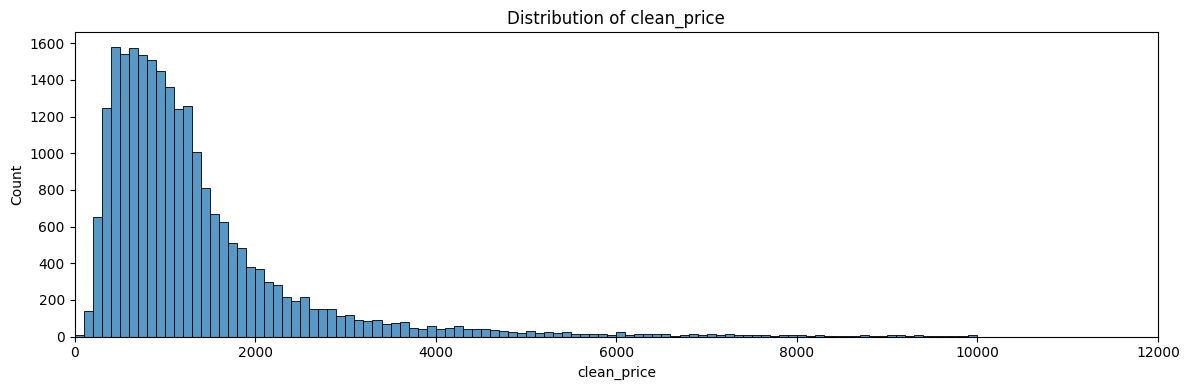

In [88]:
# Plot histogram to visualize the distribution of 'clean_price'
plot_histogram(
    df=df,
    vars=['clean_price'],
    bins=100,
    binrange=(0,10000)
)

En el gráfico podemos visualizar la distribución claramente sesgada a la derecha (*right-skewed*) de la variable `price`, lo que indica que la mayoría de los listings tienen precios relativamente bajos, mientras que existe una cola larga de valores altos que representan propiedades premium, posibles outliers o errores de carga. 

Para visualizar mejor la forma de la distribución, se limitó el rango del histograma a **0–10,000**. Esto se hizo porque los valores extremos (algunos superiores a 20,000, 50,000 o incluso a 100,000) distorsionaban la escala del gráfico, impidiendo observar los patrones reales del mercado estándar.

Se observa que la mayor concentración de precios está entre **500 y 2,000** por noche. A partir de los **2,000**, la frecuencia comienza a disminuir progresivamente, formando la **cola larga** que se extiende hasta el límite superior del gráfico.

Esta visualización complementa el resumen estadístico previo, confirmando que:
- La mayoría de los precios se concentran en el rango económico y estándar.
- Los valores altos deben analizarse cuidadosamente para decidir si se tratan como propiedades premium válidas, errrores o como outliers a filtrar.

### Detección y análisis de valores atípicos

#### Interquartile Range

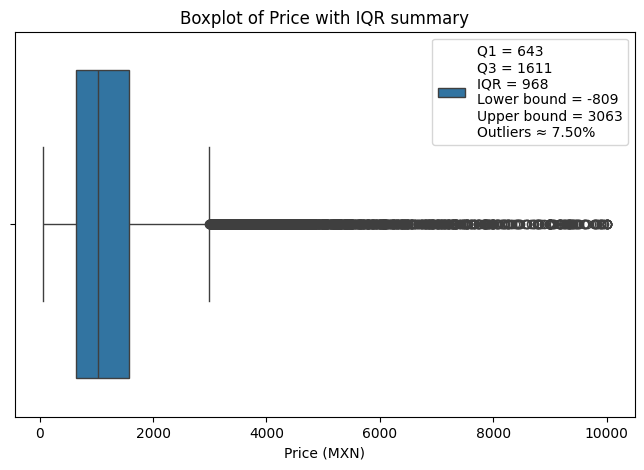

In [89]:
# Select the target column
col = df['clean_price']

# ======= IQR calculation =======

# Compute Q1, Q3, IQR, and bounds to identify outliers
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR
outliers_pct = len(col[(col < lower_bound_iqr) | (col > upper_bound_iqr)]) / len(col) * 100

# ====== Plot boxplot =============

# Limit the range before plotting (exclude extreme values above 10,000)
col_range = col[col.between(0, 10000)]

# Create boxplot visualization of price distribution
plt.figure(figsize=(8, 5))
sns.boxplot(x=col_range)

# Add legend with IQR summary statistics
legend_text = (
    f"Q1 = {Q1:.0f}\n"
    f"Q3 = {Q3:.0f}\n"
    f"IQR = {IQR:.0f}\n"
    f"Lower bound = {lower_bound_iqr:.0f}\n"
    f"Upper bound = {upper_bound_iqr:.0f}\n"
    f"Outliers ≈ {outliers_pct:.2f}%"
)

plt.title("Boxplot of Price with IQR summary")
plt.xlabel("Price (MXN)")
plt.legend([legend_text], loc="upper right", frameon=True)
plt.show()




El gráfico muestra la distribución de `price` junto con un resumen estadístico basado en el criterio de Tukey (IQR). Este enfoque permite identificar valores atípicos al analizar la dispersión central de los datos. En este caso:

- Q1 (25%) = **643**
- Q3 (75%) = **1,611**
- lo que define el rango intercuartílico (IQR) como **968**.

Un IQR de 968 indica que la mitad de los listings se concentran en un intervalo de casi mil pesos, lo cual refleja un mercado con cierta heterogeneidad pero sin ser extremadamente disperso.
  
A partir de estos valores, se calcula un límite inferior de -809 (irrelevante en la práctica por tratarse de precios negativos) y un límite superior de 3,063. Según este criterio, aproximadamente **7.5% de los listings** tienen precios fuera de este rango y se consideran outliers.

El boxplot refleja visualmente esta estructura: la caja central representa el IQR, concentrando el 50% de los datos, mientras que los bigotes se extienden hasta los límites definidos por Tukey. Los puntos que aparecen fuera de los bigotes corresponden a precios considerados atípicos. La mediana se encuentra cerca de los 1,100, lo que indica una ligera asimetría hacia precios bajos.

Este comportamiento muestra, al igual que el histograma, que existe una cola larga de precios elevados, típica de mercados con segmentos de lujo, ubicaciones privilegiadas o inconsistencias en los datos. Aunque el criterio de IQR es útil para detectar extremos, puede resultar demasiado estricto si nuestro objetivo es modelar el mercado general, ya que podría estar excluyendo un segmento no despreciable de propiedades.

El análisis con IQR permite delimitar el rango típico de precios y detectar valores que se desvían del comportamiento central. Sin embargo, conviene complementar este enfoque con otros criterios más flexibles (como percentiles) para evitar excluir propiedades relevantes del mercado estándar.


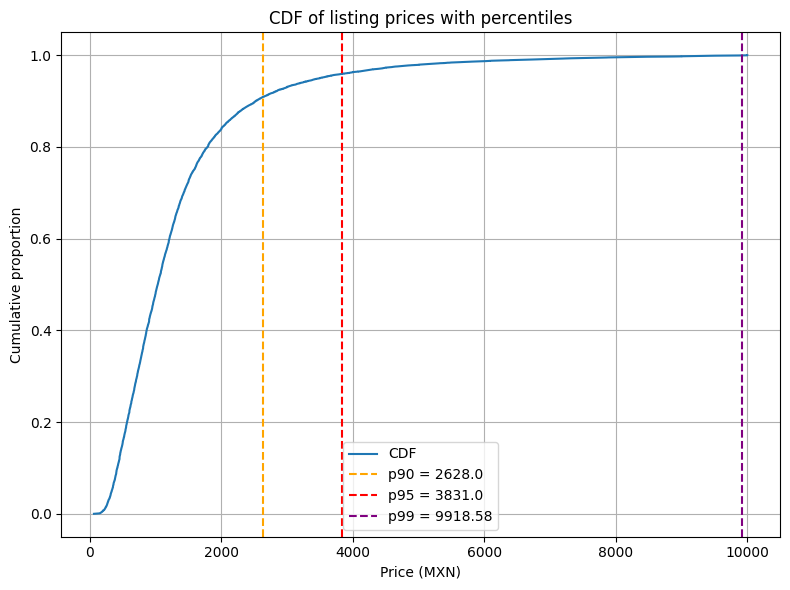

In [90]:
# Sort the prices to build the CDF
col_sorted = np.sort(col_range)

# Compute cumulative proportion (CDF values)
cdf = np.arange(1, len(col_sorted) + 1) / len(col_sorted)

# Calculate key percentiles
p90 = np.percentile(col, 90)   # 90th percentile
p95 = np.percentile(col, 95)   # 95th percentile
p99 = np.percentile(col, 99)   # 99th percentile

# Plot the CDF curve
plt.figure(figsize=(8,6))
plt.plot(col_sorted, cdf, label="CDF")

# Add vertical lines for percentiles
plt.axvline(p90, color='orange', linestyle='--', label=f'p90 = {p90}')
plt.axvline(p95, color='red', linestyle='--', label=f'p95 = {p95}')
plt.axvline(p99, color='purple', linestyle='--', label=f'p99 = {p99.round(2)}')

# Add labels, title, grid, and legend
plt.xlabel("Price (MXN)")
plt.ylabel("Cumulative proportion")
plt.title("CDF of listing prices with percentiles")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


El gráfico muestra la **función de distribución acumulada (CDF)** de los precios de los listings. Esta curva representa, para cada precio, el porcentaje acumulado de listings que tienen un precio igual o menor. Esta herramienta nos permite entender la distribución completa del mercado, más allá de la mediana o el rango intercuartílico.

La curva azul muestra cómo se acumulan los precios desde los más bajos hasta los más altos. Los percetiles p90, p95 y p99 están marcados con líneas verticales (naranja, roja y morada), lo que permite visualizar claramente dónde se ubican los extremos superiores del mercado.

- El **P90** indica el límite superior del mercado estándar: cualquier listing por encima de ~2,600 ya pertenece al 10% más caro.  
- El **P95** refina aún más ese corte, mostrando que listings por encima de ~3,800 ya son parte del 5% más exclusivo.  
- El **P99** revela que solo el 1% de los listings superan los ~9,900, lo que confirma la existencia de una cola larga de precios elevados.

El análisis de percentiles complementa perfectamente el enfoque del IQR. Mientras que el IQR delimita el rango central, los percentiles permiten entender la estructura de la cola superior del mercado. En este caso, los valores de p90, p95 y p99 confirman que el mercado tiene una distribución asimétrica hacia precios altos, con una minoría de listings que elevan significativamente el rango máximo.



### Verificación de integridad y limpieza de datos


Antes de realizar cualquier validación o limpieza sobre `price`, es necesario asegurar que el dataset represente el *mercado vigente* y no incluya listings que ya no están activos. El objetivo del modelo es predecir el precio más actual posible. Por lo tanto, conservar listings que llevan años sin reservas podría añadir ruido estructural, alterar la forma de la distribución y reducir la calidad del modelo.

En este dataset no existe una variable explícita que indique la última fecha de renta. Sin embargo, podemos aproximar la actividad del listing utilizando:

- `last_review` → proxy de la última estancia confirmada.
- `number_of_reviews` → número total de reseñas acumuladas.

**Criterio de clasificación**

Se clasifican los listings en dos grupos:

- *Activos recientes o nuevos*: última reseña en los últimos 24 meses o listings con number_of_reviews == 0 (posibles casos de publicación reciente).
- *Inactivos*: listings con reseñas antiguas (más de 24 meses) o inconsistencias en la fecha de última reseña.

Se excluirán los listings inactivos, ya que no estarían representando las condiciones actuales del mercado. Con esta acción reduciremos tanto el ruido estructural y el riesgo de outliers en nuestro dataset.

In [91]:
# 1. Convert date columns to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')

today = pd.Timestamp.today()

# 2. Define temporal cutoff (24 months)
cutoff_active = today - pd.DateOffset(months=24)

# ===== Classification logic =====

# 3. Flag active or new listings (no reviews yet OR last review within cutoff period)
df['is_active_or_new'] = (
    (df['number_of_reviews'] == 0) |
    ((df['last_review'].notna()) & (df['last_review'] >= cutoff_active))
)

# 4. Flag inactive listings (have reviews but not recent OR missing/inconsistent review history)
df['is_inactive'] = (
    (df['number_of_reviews'] > 0) &
    (
        df['last_review'].isna() |
        (df['last_review'] < cutoff_active)
    )
)

# 5. Build clean dataset (current market only: active or new listings)
df_clean = df[df['is_active_or_new']].copy()

# Print classification summary of listings
print("===== Listings Classification Summary =======")
print("Total original listings:", len(df))
print("Active or new listings:", df['is_active_or_new'].sum())
print("Inactive listings:", df['is_inactive'].sum())
print("Total listings in df_clean:", len(df_clean))


===== Listings Classification Summary =======
Total original listings: 23567
Active or new listings: 21802
Inactive listings: 1765
Total listings in df_clean: 21802


Después de aplicar el criterio de filtrado temporal, se eliminaron 1,636 listings clasificados como inactivos, lo que representa aproximadamente el 7% del dataset original.

El nuevo dataset `df_clean` contiene 21,970 listings considerados activos recientes o nuevos. Con esto, aseguramos que la información utilizada refleje las condiciones actuales del mercado y esté alineada con el objetivo predictivo del modelo: estimar precios vigentes. Excluir los listings inactivos ayudará a reducir el riesgo de incorporar señales de precio obsoletas que no reflejan el mercado actual. 

Con el dataset ya alineado al mercado actual, el siguiente paso es refinar la variable `price`. Como punto de partida en la evaluación y depuración de nuestra variable target, calculamos la distribución de `price_per_guest` a nivel global. Para ello utilizamos percentiles detallados que permiten capturar tanto la tendencia central como los extremos de la distribución. Este análisis inicial no solo ayudará a identificar outliers evidentes, sino también a detectar patrones anómalos, sesgos estructurales y posibles inconsistencias en la captura de datos, lo que sienta las bases para una limpieza más precisa y una modelación más confiable.


In [92]:
# Compute price per guest
df_clean['price_per_guest'] = df_clean['clean_price'] / df_clean['accommodates']

# Summary statistics with custom percentiles
df_clean['price_per_guest'].describe(percentiles=[0.001, 0.005, 0.01, 0.1, 0.9, 0.95, 0.99, 0.995, 0.999])

count     21802.000000
mean        576.452054
std        7666.131851
min          14.062500
0.1%         34.800063
0.5%         72.202333
1%           92.500000
10%         180.850000
90%         777.900000
95%        1007.178125
99%        2197.000000
99.5%      3510.391250
99.9%     10158.818900
max      900000.000000
Name: price_per_guest, dtype: float64

La distribución presenta señales claras de comportamiento extremo:

1. *Asimetría positiva pronunciada*  
   La media (575) es considerablemente mayor que la mediana (360), lo que indica una cola derecha pesada.

2. *Dispersión explosiva*  
   La desviación estándar (7,636) es más de 12 veces la media, lo que sugiere la presencia de valores atípicos extremos que distorsionan la distribución.

3. *Cola superior muy pesada*  
   El 99% de los listings se encuentra por debajo de 2,199 por huesped, sin embargo el valor máximo alcanza 900,000 por huesped. Esta diferencia es estadísticamente sospechosa.

4. *Saltos abruptos en los percentiles altos*  
   El salto de p99 (2,199) a p99.9 (10,119) y posteriormente a 900,000 no parece reflejar una transición adecuada hacia el segmento de lujo, sino posibles inconsistencias o errores de captura.

En conjunto, estos indicadores sugieren que la distribución global mezcla mercado real con valores potencialmente erróneos o estructuralmente inconsistentes.

Pero evaluar `price_per_guest` de forma agregada implicaría asumir que todos los listings pertenecen al mismo sub-mercado económico. El mercado de Airbnb está estructuralmente segmentado por `room_type`, donde cada categoría responde a dinámicas distintas de oferta, demanda y disposición a pagar:

- Entire home/apt  
- Private room  
- Shared room  
- Hotel room  

Cada uno representa un sub-mercado con niveles de precio y variabilidad propios. Si analizamos todo de forma global:

- Los alojamientos de lujo pueden parecer outliers cuando en realidad son coherentes dentro de su segmento.
- Los alojamientos económicos pueden comprimir artificialmente la distribución.
- Los hoteles, aunque pocos, pueden inflar la varianza.
- Las verdaderas inconsistencias pueden quedar ocultas dentro de la agregación.

Para evaluar correctamente la integridad del precio por huésped, es necesario analizar la distribución dentro de cada `room_type`. Por estas razones, el siguiente paso consistirá en evaluar la distribución de `price_per_guest` por `room_type` en lugar de basarnos únicamente en estadísticas globales.

In [93]:
# 1. Compute lower and upper quantile thresholds per room_type

# We compute the 1st and 99.9th percentiles of price_per_guest
# separately for each room_type. This allows us to control
# extreme values within each sub-market instead of globally.
quantiles_by_room = (
    df_clean
    .groupby("room_type")["price_per_guest"]
    .quantile([0.01, 0.999])
    .unstack()
)

# Rename quantile columns for clarity
quantiles_by_room.columns = ["lower_ppg", "upper_ppg"]

# Print quantile thresholds by room_type
print("====== Quantiles by room_type =========\n")
print(quantiles_by_room)


# 2. Attach quantile thresholds to each listing

# Merge the computed quantile thresholds back to the dataset
# so each listing has its corresponding lower and upper bounds
# based on its room_type.
df_with_limits = df_clean.merge(quantiles_by_room, on="room_type", how="left")


# 3. Identify extreme observations (vectorized approach)

# Create boolean masks for lower and upper violations
# to efficiently flag outliers without repeated groupby lookups.
df_with_limits["is_above_upper"] = (
    df_with_limits["price_per_guest"] > df_with_limits["upper_ppg"]
)

df_with_limits["is_below_lower"] = (
    df_with_limits["price_per_guest"] < df_with_limits["lower_ppg"]
)

# Print counts of extreme listings by room_type
print("\n====== Extreme listing counts by room_type =========\n")
counts_by_room = (
    df_with_limits
    .groupby("room_type")
    .agg(
        total=("price_per_guest", "count"),
        above_upper=("is_above_upper", "sum"),
        below_lower=("is_below_lower", "sum"),
    )
)
print(counts_by_room)


# 4. Pre-cleaning distribution summary

# Generate detailed distribution snapshot before trimming
# including very low and very high percentiles to inspect tail behavior.
print("\n======== PRE-cleaning summary of price_per_guest by room_type ========\n")
summary_pre = (
    df_clean
    .groupby("room_type")["price_per_guest"]
    .describe(percentiles=[0.001, 0.005, 0.01, 0.1, 0.9, 0.95, 0.99, 0.995, 0.999])
    .round(2)
    .T
)
print(summary_pre)


====== Quantiles by room_type =========

                 lower_ppg      upper_ppg
room_type                                
Entire home/apt  105.47875    8441.606729
Hotel room       103.00000  358234.816000
Private room      92.26300   10243.126900
Shared room       24.12000    9872.335000

====== Extreme listing counts by room_type =========

                 total  above_upper  below_lower
room_type                                       
Entire home/apt  14984           15          150
Hotel room          50            1            0
Private room      6522            7           66
Shared room        246            1            3

======== PRE-cleaning summary of price_per_guest by room_type ========

room_type  Entire home/apt  Hotel room  Private room  Shared room
count             14984.00       50.00       6522.00       246.00
mean                473.33    14629.75        717.03       274.17
std                 594.98    59418.45      12944.07       815.52
min                  

El análisis por segmento confirma que el comportamiento de la cola superior no es homogéneo entre categorías.

1. *Entire home/apt*
   - p99.9 ≈ 8,400  
   - Máximo ≈ 22,500
   - Se detectan 16 valores por encima del límite superior y 151 por debajo del inferior.
   - La cola es amplia pero relativamente consistente con un mercado premium amplio.

2. *Private room*
   - p99.9 ≈ 10,200  
   - Máximo ≈ 900,000  
   - 7 valores por encima del límite superior.
   - La diferencia entre p99.9 y el máximo sugiere la presencia de valores estructuralmente inconsistentes.

3. *Shared room*
   - p99.9 ≈ 9,800  
   - Máximo ≈ 12,841  
   - Solo 1 valor extremo superior y 3 por debajo del inferior.
   - Mercado más compacto y estable.

4. *Hotel room*
   - p99 ≈ 277,200  
   - P99.9 ≈ 358,200  
   - Máximo ≈ 367,200
   - Aunque solo hay 57 observaciones, la dispersión es extraordinariamente alta.
   - La desviación estándar supera ampliamente la media.
   - La cola superior es desproporcionada en comparación con otros segmentos.

**Aplicación del trimming por percentiles**

In [94]:
# Apply trimming based on group-specific quantiles 

# Keep only listings within the 1%–99.9% interval
# defined per room_type.
df_clean = df_with_limits[
    (~df_with_limits["is_above_upper"]) &
    (~df_with_limits["is_below_lower"])
].copy()


# Post-cleaning distribution summary
print("\n======== POST-cleaning summary of price_per_guest by room_type ========\n")
summary_post = (
    df_clean
    .groupby("room_type")["price_per_guest"]
    .describe(percentiles=[0.001, 0.005, 0.01, 0.1, 0.9, 0.95, 0.99, 0.995, 0.999])
    .round(2)
    .T
)
print(summary_post)


======== POST-cleaning summary of price_per_guest by room_type ========

room_type  Entire home/apt  Hotel room  Private room  Shared room
count             14819.00       49.00       6449.00       242.00
mean                463.65     7433.79        457.22       225.39
std                 389.09    31001.15        551.99       132.76
min                 105.50      103.00         92.50        25.00
0.1%                109.37      103.00         95.50        25.03
0.5%                116.85      103.00        103.56        25.18
1%                  125.84      103.00        113.07        25.47
10%                 194.00      210.20        175.00        50.10
90%                 783.37     3648.27        763.60       371.80
95%                1000.01     3662.90       1004.00       469.15
99%                1748.05   154237.44       2569.60       589.75
99.5%              2490.86   168926.72       3827.38       623.85
99.9%              4918.20   180678.14       8008.89       701.35
ma

Para controlar la influencia de valores extremos sin eliminar segmentos legítimos del mercado, se aplicó un trimming basado en percentiles específicos por room_type:

- Límite inferior: percentil 1  
- Límite superior: percentil 99.9  

Este enfoque se basó en lo siguiente:

- Cada sub-mercado tiene su propia escala de precios.  
- Aplicar un único umbral global sería metodológicamente incorrecto.
- El trimming se basa en la estructura interna de cada categoría, no en criterios arbitrarios.
- Eliminar valores estructuralmente inconsistentes mejorará la estabilidad estadística del entrenamiento. 
- El impacto en tamaño muestral es mínimo:
   - Entire home/apt: -167 observaciones  
   - Private room: -69 observaciones  
   - Shared room: -4 observaciones  
   - Hotel room: -1 observación  

Tras el trimming, como podemos observar en las estadísticas *post-cleaning*, la desviación estándar disminuye considerablemente en todos los segmentos, especialmente en Private room y Hotel room, lo que indica que los valores eliminados tenían una influencia desproporcionada. 

Dado que el segmento Hotel room aún presenta un comportamiento atípico y tiene un reducido tamaño muestral, analizaremos con mayor detalle la cola superior de este segmento.

In [95]:
# Filter hotel room listings and display top 10 by price_per_guest
print("=========== Top Hotel Room Listings (Price per Guest) ===========")
display(df_clean[['listing_url', 'room_type', 'accommodates', 'clean_price', 'price_per_guest']][df_clean['room_type'] == 'Hotel room'] \
    .sort_values('price_per_guest', ascending=False).head(10))


=========== Top Hotel Room Listings (Price per Guest) ===========


,listing_url,room_type,accommodates,clean_price,price_per_guest
13717,https://www.airbnb.com/rooms/1118176220387018952,Hotel room,4,734464.0,183616.000000
13712,https://www.airbnb.com/rooms/1118173216727497991,Hotel room,6,734464.0,122410.666667
2978,https://www.airbnb.com/rooms/33644111,Hotel room,2,7345.0,3672.500000
13715,https://www.airbnb.com/rooms/1118175893833356107,Hotel room,2,7297.0,3648.500000
13710,https://www.airbnb.com/rooms/1118168877265272898,Hotel room,6,21890.0,3648.333333
13718,https://www.airbnb.com/rooms/1118176724690604169,Hotel room,4,14593.0,3648.250000
13716,https://www.airbnb.com/rooms/1118175965894565797,Hotel room,2,7133.0,3566.500000
13709,https://www.airbnb.com/rooms/1118168393291847001,Hotel room,6,21399.0,3566.500000
13719,https://www.airbnb.com/rooms/1118176774826797541,Hotel room,4,14266.0,3566.500000
3426,https://www.airbnb.com/rooms/37326050,Hotel room,2,6806.0,3403.000000


Después de la limpieza de valores extremos, el segmento `Hotel room` sigue presentando una desviación estándar desproporcionadamente alta en relación con su tamaño muestral (56 observaciones).

Al analizar esta variable por separado, se identificaron 2 listings con `price_per_guest` entre $122,000 y $183,000, mientras que el resto del segmento se encuentra por debajo de $5,000 por huesped.

Estos registros rompen el orden de magnitud del mercado y comparten el mismo precio por noche (`clean_price`), lo que sugiere posible inconsistencia estructural (error de captura o unidad temporal incorrecta) más que observaciones legítimas del mercado premium.

Estos 2 listings fueron inspeccionados manualmente en la plataforma de Airbnb, lo que confirmó que los valores observados no corresponden con lo precios reales mostrados en la plataforma, sino que presentan inconsistencias en su información capturada. Esta validación externa confirmó las sospechas, por lo tanto, se eliminarán del dataset.

In [96]:
# Remove inconsistent hotel room listings
df_clean = df_clean[
    ~(
        (df_clean["room_type"] == "Hotel room") &
        (df_clean["clean_price"] == 734464)
    )
].copy()

In [97]:
# Compute descriptive statistics of price_per_guest by room_type
# after removing inconsistencies in Hotel room listings
print("============== Price per Guest by Room Type (after cleaning Hotel room inconsistencies) ================")
df_clean.groupby("room_type")["price_per_guest"] \
    .describe(percentiles=[0.001, 0.005, 0.01, 0.1, 0.9, 0.95, 0.99, 0.995, 0.999]) \
    .round(2).T


============== Price per Guest by Room Type (after cleaning Hotel room inconsistencies) ================


room_type,Entire home/apt,Hotel room,Private room,Shared room
count,14819.00,47.00,6449.00,242.00
mean,463.65,1238.91,457.22,225.39
std,389.09,1214.63,551.99,132.76
min,105.50,103.00,92.50,25.00
0.1%,109.37,103.00,95.50,25.03
0.5%,116.85,103.00,103.56,25.18
1%,125.84,103.00,113.07,25.47
10%,194.00,204.40,175.00,50.10
90%,783.37,3566.50,763.60,371.80
95%,1000.01,3648.31,1004.00,469.15


Tras eliminar los dos listings extremos del segmento Hotel room, se volvió a analizar la distribución de `price_per_guest` para evaluar el impacto de la limpieza.

*Antes de la eliminación:*
- Media ≈ 7,400
- Desviación estándar ≈ 31,000  
- Máximo ≈ 183,600  

*Después de la eliminación:*
- Media ≈ 1,230 
- Desviación estándar ≈ 1,214  
- Máximo ≈ 3,672  

La reducción drástica en la media y la desviación estándar confirma que los dos registros eliminados estaban inflando artificialmente la distribución del segmento.

Tras su eliminación:

- La cola superior muestra una progresión suave hasta el P99.9.
- El máximo se encuentra alineado con los percentiles altos.
- La variabilidad es consistente con un mercado premium real, pero no desproporcionado.
- La distribución de `price_per_guest` en Hotel room queda estadísticamente estable y económicamente coherente.

In [98]:
# Check global price distribution after trimming
df_clean['clean_price'].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).round(2)


count     21557.00
mean       1491.03
std        2540.85
min          61.00
95%        3729.00
99%        9000.00
99.5%     12683.78
99.9%     27866.00
max      134967.00
Name: clean_price, dtype: float64

Como siguiente paso, analizaremos la distribución de `price` segmentada por `room type`. Esta desagregación es necesaria porque cada categoría presenta dinámicas distintas de precios y niveles de dispersión. Al revisar las distribuciones por tipo de habitación podremos identificar patrones específicos, evaluar la consistencia de los valores extremos y asegurar que las métricas reflejen adecuadamente las condiciones de cada segmento del mercado.

In [99]:
# Compute descriptive statistics of clean_price by room_type
print("=================== Price by Room Type ====================")
df_clean.groupby("room_type")["clean_price"] \
    .describe(percentiles=[0.001, 0.005, 0.01, 0.1, 0.9, 0.95, 0.99, 0.995, 0.999]) \
    .round(2).T


=================== Price by Room Type ====================


room_type,Entire home/apt,Hotel room,Private room,Shared room
count,14819.00,47.00,6449.00,242.00
mean,1769.13,4527.43,874.34,305.45
std,2798.28,5383.83,1643.54,209.00
min,185.00,415.00,144.00,61.00
0.1%,273.27,415.00,179.00,62.20
0.5%,353.00,415.00,198.00,66.00
1%,405.00,415.00,214.00,66.00
10%,680.00,559.00,319.00,153.10
90%,2950.20,13153.80,1508.20,536.00
95%,4178.10,14494.90,2173.60,696.50


Tras la depuración inicial basada en `price_per_guest`, observamos que la distribución de price se estabilizó en términos globales. Sin embargo, al desagregar por room type se identifican diferencias relevantes entre segmentos.

En particular, los grupos *Entire home/apt* y *Private room* presentan colas superiores largas que concentran valores extremos y elevan la dispersión de sus métricas. Estos comportamientos sugieren la necesidad de un análisis más detallado de la cola alta en ambos segmentos, con el fin de distinguir entre precios premium legítimos y posibles inconsistencias en la captura de datos.

Adicionalmente, verificaremos la cola baja en todos los segmentos, ya que precios inusualmente bajos pueden ser igualmente problemáticos: desde errores de registro hasta estrategias de fijación de precios que distorsionan la distribución.

Este paso permitirá refinar aún más la representación del mercado y asegurar que las métricas de precio reflejen adecuadamente tanto las condiciones típicas como los extremos legítimos de cada categoría de alojamiento.

In [100]:
# High-price tail for Entire home/apt
print("=========== Top Entire Home Listings (Price) ===========")
display(
    df_clean[['listing_url','room_type', 'accommodates', 'clean_price', 'price_per_guest']]
    [df_clean['room_type'] == 'Entire home/apt']
    .sort_values('clean_price', ascending=False)
    .head(10)   # Top 10 most expensive Entire home/apt listings
)

# High-price tail for Private room
print("=========== Top Private Room Listings (Price) ===========")
display(
    df_clean[['listing_url', 'room_type', 'accommodates', 'clean_price', 'price_per_guest']]
    [df_clean['room_type'] == 'Private room']
    .sort_values('clean_price', ascending=False)
    .head(10)   # Top 10 most expensive Private room listings
)

=========== Top Entire Home Listings (Price) ===========


,listing_url,room_type,accommodates,clean_price,price_per_guest
11640,https://www.airbnb.com/rooms/971862063970613804,Entire home/apt,16,134967.0,8435.4375
13175,https://www.airbnb.com/rooms/1082786626555804393,Entire home/apt,16,100711.0,6294.4375
14780,https://www.airbnb.com/rooms/1179196519229213225,Entire home/apt,16,82956.0,5184.7500
11504,https://www.airbnb.com/rooms/963168269231638310,Entire home/apt,16,70407.0,4400.4375
11507,https://www.airbnb.com/rooms/963739323536104747,Entire home/apt,16,70407.0,4400.4375
13282,https://www.airbnb.com/rooms/1090723594470224536,Entire home/apt,16,64566.0,4035.3750
10930,https://www.airbnb.com/rooms/923988124566655570,Entire home/apt,16,63650.0,3978.1250
16237,https://www.airbnb.com/rooms/1265297765156699205,Entire home/apt,16,59800.0,3737.5000
12736,https://www.airbnb.com/rooms/1049392855494869044,Entire home/apt,16,50000.0,3125.0000
3368,https://www.airbnb.com/rooms/36799468,Entire home/apt,6,49500.0,8250.0000


=========== Top Private Room Listings (Price) ===========


,listing_url,room_type,accommodates,clean_price,price_per_guest
4010,https://www.airbnb.com/rooms/41404517,Private room,10,100989.0,10098.900
2035,https://www.airbnb.com/rooms/25676577,Private room,2,20000.0,10000.000
20622,https://www.airbnb.com/rooms/1475491135309789112,Private room,2,19400.0,9700.000
20996,https://www.airbnb.com/rooms/1487286449446647057,Private room,2,19400.0,9700.000
14858,https://www.airbnb.com/rooms/1183431082893996025,Private room,2,16438.0,8219.000
14855,https://www.airbnb.com/rooms/1183346281861984437,Private room,2,16438.0,8219.000
483,https://www.airbnb.com/rooms/10996988,Private room,16,12534.0,783.375
14840,https://www.airbnb.com/rooms/1182725093001596200,Private room,2,12533.0,6266.500
250,https://www.airbnb.com/rooms/6810612,Private room,16,11476.0,717.250
9828,https://www.airbnb.com/rooms/849318651327303243,Private room,2,11075.0,5537.500


Al analizar las colas superiores por `room type`, observamos que los valores extremos en *Entire home/apt* corresponden a propiedades premium legítimas, consistentes con el mercado de alojamientos completos.

En contraste, dentro del segmento *Private room* se identificó un registro con un precio de $100,989 por noche, que además exige una estancia mínima de 30 noches, lo que implica un costo total cercano a 4 millones. Este valor resulta desproporcionado para una habitación privada estándar y no refleja condiciones reales de mercado.

La presencia de este registro introduce una ruptura de escala que distorsiona la distribución y afecta la interpretación estadística. Por ello, se justifica su eliminación como un caso de inconsistencia en la captura de datos, asegurando que la representación del mercado permanezca robusta.

In [101]:
# Remove inconsistent private room listings
df_clean = df_clean[
    ~(
        (df_clean["room_type"] == "Private room") &
        (df_clean["clean_price"] == 100989)
    )
].copy()

In [102]:
# Room types to analyze
room_types = df_clean['room_type'].unique()

# Loop through each room type and display the bottom listings
for rt in room_types:
    print(f"=========== Bottom Listings ({rt}) ===========")
    display(
        df_clean[['listing_url', 'room_type','property_type','accommodates', 'clean_price', 'price_per_guest']]
        [df_clean['room_type'] == rt]
        .sort_values('clean_price', ascending=True)
        .head(15)   # Bottom 20 listings for this room type
    )

=========== Bottom Listings (Entire home/apt) ===========


,listing_url,room_type,property_type,accommodates,clean_price,price_per_guest
12461,https://www.airbnb.com/rooms/1028554958685714247,Entire home/apt,Entire guesthouse,1,185.0,185.0
13558,https://www.airbnb.com/rooms/1109740296743060696,Entire home/apt,Entire guesthouse,1,193.0,193.0
20620,https://www.airbnb.com/rooms/1475452657541126489,Entire home/apt,Entire guesthouse,1,203.0,203.0
3769,https://www.airbnb.com/rooms/39743478,Entire home/apt,Entire guesthouse,2,214.0,107.0
5390,https://www.airbnb.com/rooms/49163066,Entire home/apt,Entire rental unit,2,225.0,112.5
3241,https://www.airbnb.com/rooms/35714471,Entire home/apt,Entire rental unit,2,237.0,118.5
16938,https://www.airbnb.com/rooms/1304464351009986855,Entire home/apt,Entire rental unit,2,243.0,121.5
21233,https://www.airbnb.com/rooms/1496385829561818160,Entire home/apt,Entire place,1,243.0,243.0
21574,https://www.airbnb.com/rooms/1508266211777323064,Entire home/apt,Entire rental unit,2,248.0,124.0
3116,https://www.airbnb.com/rooms/34859922,Entire home/apt,Entire rental unit,2,254.0,127.0


=========== Bottom Listings (Private room) ===========


,listing_url,room_type,property_type,accommodates,clean_price,price_per_guest
11771,https://www.airbnb.com/rooms/982936992407688705,Private room,Private room in home,1,144.0,144.0
2016,https://www.airbnb.com/rooms/25428079,Private room,Private room in condo,1,158.0,158.0
2012,https://www.airbnb.com/rooms/25345464,Private room,Private room in condo,1,162.0,162.0
12598,https://www.airbnb.com/rooms/1037719844522311272,Private room,Private room in guesthouse,1,172.0,172.0
4671,https://www.airbnb.com/rooms/45371347,Private room,Private room in home,1,173.0,173.0
3980,https://www.airbnb.com/rooms/41177855,Private room,Private room in rental unit,1,178.0,178.0
15718,https://www.airbnb.com/rooms/1234311916678132155,Private room,Private room in home,1,179.0,179.0
1973,https://www.airbnb.com/rooms/24967533,Private room,Private room in condo,1,179.0,179.0
603,https://www.airbnb.com/rooms/12814363,Private room,Private room in home,1,180.0,180.0
3759,https://www.airbnb.com/rooms/39641624,Private room,Private room in rental unit,1,180.0,180.0


=========== Bottom Listings (Hotel room) ===========


,listing_url,room_type,property_type,accommodates,clean_price,price_per_guest
3472,https://www.airbnb.com/rooms/37721233,Hotel room,Room in casa particular,1,415.0,415.0
3233,https://www.airbnb.com/rooms/35617592,Hotel room,Room in casa particular,1,415.0,415.0
2639,https://www.airbnb.com/rooms/31315549,Hotel room,Room in hotel,2,523.0,261.5
2641,https://www.airbnb.com/rooms/31315727,Hotel room,Room in hotel,2,523.0,261.5
2656,https://www.airbnb.com/rooms/31468145,Hotel room,Room in bed and breakfast,1,556.0,556.0
2640,https://www.airbnb.com/rooms/31315704,Hotel room,Room in hotel,3,561.0,187.0
2636,https://www.airbnb.com/rooms/31311837,Hotel room,Room in hotel,5,618.0,123.6
2637,https://www.airbnb.com/rooms/31312409,Hotel room,Room in hotel,6,618.0,103.0
2632,https://www.airbnb.com/rooms/31307371,Hotel room,Room in hotel,6,618.0,103.0
2638,https://www.airbnb.com/rooms/31314962,Hotel room,Room in hotel,3,648.0,216.0


=========== Bottom Listings (Shared room) ===========


,listing_url,room_type,property_type,accommodates,clean_price,price_per_guest
17279,https://www.airbnb.com/rooms/1327580316106887410,Shared room,Shared room in rental unit,1,61.0,61.00
17327,https://www.airbnb.com/rooms/1329216692344341917,Shared room,Shared room in rental unit,1,66.0,66.00
17326,https://www.airbnb.com/rooms/1329216484039838694,Shared room,Shared room in rental unit,1,66.0,66.00
17325,https://www.airbnb.com/rooms/1329216366778118239,Shared room,Shared room in rental unit,1,66.0,66.00
17288,https://www.airbnb.com/rooms/1328379085023652183,Shared room,Shared room in rental unit,1,68.0,68.00
17369,https://www.airbnb.com/rooms/1330812883745588663,Shared room,Shared room in rental unit,1,68.0,68.00
17370,https://www.airbnb.com/rooms/1330813161002410973,Shared room,Shared room in rental unit,1,68.0,68.00
17324,https://www.airbnb.com/rooms/1329216197106208806,Shared room,Shared room in rental unit,1,79.0,79.00
17319,https://www.airbnb.com/rooms/1329198445829894378,Shared room,Shared room in rental unit,1,97.0,97.00
13896,https://www.airbnb.com/rooms/1131277216020537630,Shared room,Shared room in home,4,127.0,31.75


- **Entire home/apt**

Al analizar la cola inferior de precios dentro de la categoría *Entire home/apt*, se identificaron valores bajos atípicos para este tipo de propiedades. Sin embargo, una validación manual en la plataforma confirmó que estos listings son legítimos y corresponden principalmente a tipos de propiedad categorizadas como *Entire guesthouse* o *unidades pequeñas independientes* en `property_type`.

Es importante destacar que la categoría Entire home/apt hace referencia al uso exclusivo del espacio, pero no implica necesariamente mayor tamaño, lujo o ubicación premium. En muchos casos, se trata de construcciones anexas, estudios compactos o propiedades ubicadas en zonas periféricas, lo cual podría justificar precios accesibles sin representar errores o anomalías en los datos.

En etapas posteriores, la variable `property_type` será analizada con mayor detalle para capturar mejor estas diferencias estructurales en el modelo.

- **Shared room**

En la categoría de *Shared room* se identificaron registros con valores inferiores a $100. Una validación manual en la plataforma reveló que estos precios no corresponden al precio base por noche, sino al precio promocional de una noche adicional. Dado que el dataset captura estos valores promocionales como si fueran el precio regular, se consideran errores de medición y no representativos del mercado real.

Por lo tanto, se eliminarán estos listings de *Shared room*, ya que no reflejan el precio base efectivo y podrían distorsionar el entrenamiento del modelo.

- **Private room** y **Hotel room**

La cola baja observada de *Private room* fue validada manualmente y corresponde a habitaciones privadas legítimas, ubicadas en zonas periféricas o dentro de viviendas compartidas. No se detectaron anomalías estructurales ni errores de captura.

En el caso de *Hotel room*, aunque el número de observaciones es reducido, los precios bajos identificados fueron verificados y corresponden a tarifas reales en establecimientos pequeños.

In [103]:
# Remove inconsistent shared room listings
df_clean = df_clean[
    ~(
        (df_clean["room_type"] == "Shared room") &
        (df_clean["clean_price"] < 100)
    )
].copy()

Con el objetivo de evaluar el impacto de la depuración realizada en `price`, compararemos la distribución de `price` antes y después de eliminar los registros inconsistentes.

Con el objetivo de evaluar el impacto de la depuración aplicada sobre `price` (filtrado temporal, ajustes derivados del análisis de `price_per_guest` y del análisis de la distribución de `price` por `room_type`), se comparará la distribución de esta variable antes y después de la eliminación de los registros inconsistentes. 

In [104]:
# Descriptive statistics of original price
price_dist_before = df['clean_price'].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).round(2)

# Descriptive statistics of clean price
price_dist_after = df_clean['clean_price'].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).round(2)

# Combine into a single comparison table
comparison_table = pd.concat([price_dist_before, price_dist_after], axis=1)
comparison_table.columns = ['Before Cleaning', 'After Cleaning']

print("========== Price Distribution Before vs After Cleaning ==========\n")
print(comparison_table)


========== Price Distribution Before vs After Cleaning ==========

       Before Cleaning  After Cleaning
count         23567.00        21547.00
mean           1792.54         1487.00
std           13230.94         2449.20
min              61.00          127.00
95%            3831.00         3728.10
99%            9918.58         9000.00
99.5%         14720.75        12616.74
99.9%         68761.64        27682.56
max          900000.00       134967.00


Lo que podemos observar:

- La desviación estándar cayó de 13,230 a 2,276, lo que confirma que los registros eliminados estaban inflando artificialmente la dispersión del target.

- Estabilidad en la mediana y percentiles centrales. La mediana prácticamente no cambió (1,039 → 1,050), lo que indica que la estructura del mercado típico permanece intacta.

- Corrección de la cola extrema. El máximo pasó de 900,000 a 100,711 y el p99.9 se redujo considerablemente (68,761 → 27,589). Esto sugiere que la limpieza eliminó rupturas de escala sin afectar el segmento premium legítimo.

La depuración basada en `price_per_guest` y en la distribución de `price` por `room_type` no solo corrigió inconsistencias estructurales, sino que también estabilizó la distribución de `price`, reduciendo varianza extrema sin alterar la estructura central del mercado.

En secciones posteriores se abordarán otros grupos de variables (por ejemplo, ubicación y características estructurales), cuyo análisis podría derivar en validaciones adicionales y, de ser necesario, en nuevas etapas de limpieza para corregir comportamientos atípicos, inconsistencias o posibles errores de registro.

### Transformación logarítmica de `price`

Tras la depuración, la variable `price` muestra una distribución más coherente desde el punto de vista económico, sin rupturas de escala evidentes. No obstante, como suele ocurrir con variables monetarias, conserva una marcada asimetría: una cola derecha extensa y valores extremos que dominan la escala.

Este comportamiento no responde a un error, sino a una característica inherente del mercado. Los precios evolucionan de manera multiplicativa, no lineal, ya que escalan proporcionalmente con factores de demanda, ubicación y atributos del inmueble.

- Ajustes porcentuales: Los anfitriones tienden a modificar precios en términos relativos (ej. +20% en temporada alta, –15% en temporada baja), más que mediante incrementos fijos.

- Heterogeneidad del mercado: El precio por noche base de cada propiedad varía ampliamente según ubicación, tipo de inmueble y servicios, lo que hace que un ajuste lineal (ej. +$50 para todos) sea poco representativo.

- Práctica en modelado: Es habitual aplicar transformaciones logarítmicas (`log(price)`), ya que permiten capturar distribuciones sesgadas y linealizar efectos multiplicativos en modelos de regresión.

Por estas razones, se incorpora la transformación logarítmica de la variable price (`log(price)`), con los siguientes objetivos:

- Reducir la asimetría de la distribución.

- Atenuar la influencia de valores extremos sin necesidad de eliminarlos.

- Estabilizar la varianza, facilitando un comportamiento más homogéneo.

- Aproximar la estructura de los datos a supuestos compatibles con modelos lineales.

- Favorecer relaciones más proporcionales entre la variable objetivo y las explicativas.

- Interpretar efectos en términos relativos (variaciones porcentuales) en lugar de diferencias absolutas.

Esta transformación no elimina las observaciones superiores de la distribución, sino que las integra en una escala más adecuada para el análisis estadístico y la construcción de modelos predictivos.

In [105]:
# Create a price variable transformed into a logarithm
df_clean['log_price'] = np.log(df_clean['clean_price'])

In [106]:
# Descriptive statistics of original price
price_clean_dist = df_clean['clean_price'].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).round(2)

# Descriptive statistics of log-transformed price
price_log_dist = df_clean['log_price'].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).round(2)

# Combine into a single comparison table
comparison_table = pd.concat([price_clean_dist, price_log_dist], axis=1)
comparison_table.columns = ['Before log', 'After log']

print("========== Price Distribution: Clean Price vs Log-Transformed Price ==========\n")
print(comparison_table)


========== Price Distribution: Clean Price vs Log-Transformed Price ==========

       Before log  After log
count    21547.00   21547.00
mean      1487.00       6.97
std       2449.20       0.73
min        127.00       4.84
95%       3728.10       8.22
99%       9000.00       9.10
99.5%    12616.74       9.44
99.9%    27682.56      10.23
max     134967.00      11.81


Tras aplicar la transformación logarítmica, la distribución del target muestra una compresión significativa de la dispersión sin alterar la estructura relativa del mercado.

La desviación estándar se redujo de 2,276 a 0.73, lo que indica una estabilización importante de la varianza. Sin embargo, las relaciones proporcionales entre valores se mantienen intactas: la diferencia relativa entre propiedades económicas y premium sigue presente, pero ahora en una escala más manejable.

Los percentiles superiores muestran una progresión suave y continua, sin saltos abruptos, lo que sugiere que la cola premium está integrada de forma estable en la nueva escala.

Desde el punto de vista estadístico, la transformación ayudará a:

- Reducir la heterocedasticidad (dispersión creciente del error en valores altos).
- Disminuir el impacto desproporcionado de errores en listings extremadamente caros.
- Evitar que los residuos del modelo estén dominados por un pequeño número de observaciones en la cola superior.

En consecuencia, `log(price)` presenta propiedades más adecuadas para el modelado, especialmente en modelos que asumen varianza constante de los errores, como la regresión lineal.

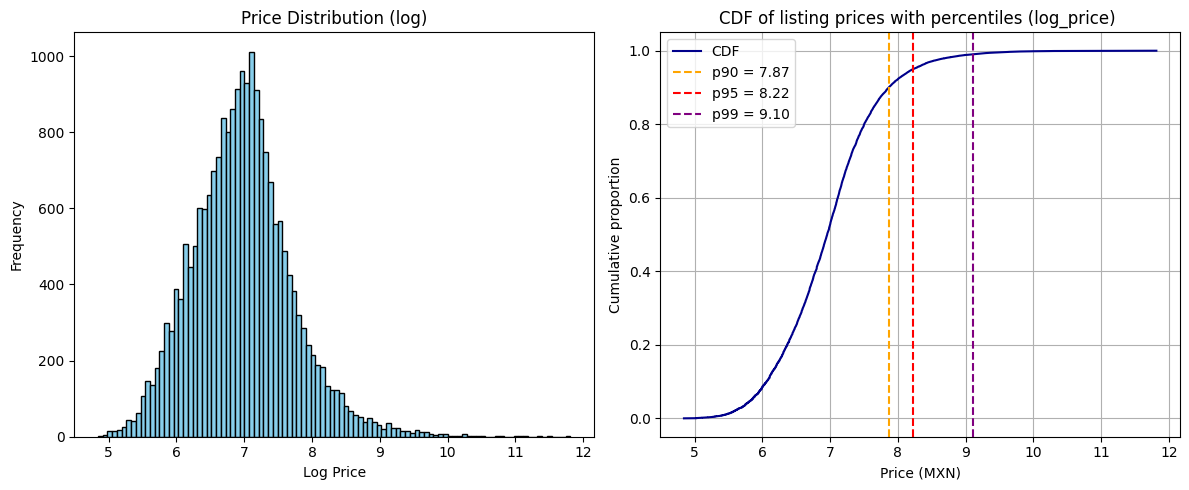

In [107]:
# Sort the prices to build the CDF
col = df_clean['log_price']
col_sorted = np.sort(col)
cdf = np.arange(1, len(col_sorted) + 1) / len(col_sorted)

# Calculate key percentiles
p90 = np.percentile(col, 90)
p95 = np.percentile(col, 95)
p99 = np.percentile(col, 99)

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left subplot: Histogram of log_price ---
axes[0].hist(df_clean['log_price'], bins=100, color='skyblue', edgecolor='black')
axes[0].set_title("Price Distribution (log)")
axes[0].set_xlabel("Log Price")
axes[0].set_ylabel("Frequency")

# --- Right subplot: CDF of original prices ---
axes[1].plot(col_sorted, cdf, label="CDF", color='darkblue')
axes[1].axvline(p90, color='orange', linestyle='--', label=f'p90 = {p90:.2f}')
axes[1].axvline(p95, color='red', linestyle='--', label=f'p95 = {p95:.2f}')
axes[1].axvline(p99, color='purple', linestyle='--', label=f'p99 = {p99:.2f}')
axes[1].set_xlabel("Price (MXN)")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_title("CDF of listing prices with percentiles (log_price) ")
axes[1].grid(True)
axes[1].legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


La distribución de `log(price)` muestra una forma aproximadamente unimodal y cercana a simétrica, con una ligera asimetría positiva residual hacia la derecha.
La mayor concentración de observaciones se encuentra entre valores logarítmicos de ~6.5 y 7.5, lo que corresponde al rango central del mercado. La cola superior se extiende de manera gradual, sin saltos abruptos ni acumulaciones anómalas.

Esto indica que la transformación logarítmica logró:
- Reducir significativamente la asimetría observada en la escala original.
- Integrar el segmento premium sin que domine la distribución.
- Generar una estructura más compatible con supuestos de modelos lineales.

La función de distribución acumulada (CDF) presenta una transición suave y continua, con mayor pendiente en la zona central (alrededor de la mediana), lo que refleja la alta densidad del mercado típico. A partir de los percentiles superiores, la curva se aplana progresivamente, indicando que:

- Los valores extremos existen, pero representan una fracción pequeña del total.
- No hay rupturas de régimen ni concentraciones anómalas en la cola superior.

En conjunto, el CDF confirma que la distribución transformada es estable, continua y adecuada para modelado estadístico.

## 7. Descripción y Agrupamiento de las Características

### Grupos de características

Una vez estabilizada la variable objetivo (`log(price)`), el siguiente paso consiste en evaluar sistemáticamente y seleccionar las variables candidatas al modelo. El dataset de Airbnb incluye un conjunto amplio de variables que describen distintas dimensiones de cada listing. Para facilitar su análisis y posterior ***feature engineering***, las variables se agruparán según el tipo de información que representan.

#### Características excluidas del modelo

Algunas categorías de variables se documentan como parte del dataset, pero quedan fuera del modelo de precios por razones metodológicas, de alcance o de riesgo de data leakage.

**Administrative and Technical Identifiers**  
Estas variables cumplen funciones técnicas o administrativas y no contienen información relevante para la estimación del precio. Su inclusión no aporta señal y podría introducir ruido innecesario.

- id
- listing_url
- scrape_id
- source
- host_id
- host_url
- host_name
- host_location
- host_neighbourhood
- picture_url
- host_thumbnail_url
- host_picture_url
- license

**Listing Descriptive Text**  
Las variables textuales descriptivas no se incluyen en el modelo, ya que su análisis requeriría técnicas de procesamiento de lenguaje natural (NLP), las cuales se encuentran fuera del alcance de este proyecto.

- name
- description
- neighborhood_overview
- host_about

**Availability and Calendar Information**  
Las variables de disponibilidad futura reflejan decisiones operativas del anfitrión y condiciones de mercado posteriores al establecimiento del precio, por lo que su uso podría introducir data leakage en un escenario de predicción estática.

- has_availability
- availability_30
- availability_60
- availability_90
- availability_365
- availability_eoy
- calendar_updated
- calendar_last_scraped

**Estimated Performance Metrics**  
Estas variables son métricas derivadas del desempeño histórico del listing y están directamente influenciadas por el precio. Incluirlas en el modelo implicaría utilizar información que no estaría disponible al momento de recomendar un precio, generando leakage.

- estimated_occupancy_l365d
- estimated_revenue_l365d

**Temporal Variables**  
Variables asociadas a fechas específicas, como eventos de scraping o historial de reseñas, no se consideran debido a que el modelo propuesto es estático y no incorpora componentes temporales.

- last_scraped
- host_since
- first_review
- last_review
- number_of_reviews
- number_of_reviews_ltm
- number_of_reviews_l30d
- number_of_reviews_ly
- reviews_per_month
- minimum_nights_avg_ntm
- maximum_nights_avg_ntm

**Stay Rule Range Variables**  
Estas variables representan variaciones históricas de las restricciones de estancia que ya están capturadas de manera implícita en las reglas principales del calendario. Incluirlas generaría redundancia y riesgo de multicolinealidad, sin aportar valor adicional al modelo.

- minimum_minimum_nights
- maximum_minimum_nights
- minimum_maximum_nights
- maximum_maximum_nights



#### Características consideradas para el modelo  

Con base en el alcance del proyecto y en consideraciones de calidad de datos e interpretabilidad, el modelo podría construirse utilizando únicamente los siguientes grupos de variables y sus correspondientes features.

**Target Variable**
Variable objetivo del modelo, no se utiliza como feature.

- price

**Location-related Features**  
Variables que capturan diferencias de precio asociadas a la ubicación del listing dentro de la ciudad.

- neighbourhood
- neighbourhood_cleansed
- neighbourhood_group_cleansed
- latitude
- longitude

**Property and Room Characteristics**  
Atributos estructurales del tipo de alojamiento ofrecido.

- property_type
- room_type

**Room and Capacity Information**  
Variables que describen el tamaño y la capacidad del alojamiento, y que representan uno de los principales determinantes del precio.

- accommodates
- bathrooms
- bathrooms_text
- bedrooms
- beds

**Booking Constraints**  
Variables que definen restricciones operativas sobre la duración de la estancia y que pueden influir indirectamente en el precio del listing.

- minimum_nights
- maximum_nights

**Amenities**  
Información relacionada con las comodidades disponibles en el listing.

- amenities

**Host Behavior and Reputation**  
Variables asociadas al perfil y experiencia del anfitrión, que pueden influir indirectamente en el precio percibido.

- host_response_time
- host_response_rate
- host_acceptance_rate
- host_listings_count
- host_is_superhost
- host_identity_verified
- host_has_profile_pic
- host_verifications
- host_total_listings_count
- calculated_host_listings_count
- calculated_host_listings_count_entire_homes
- calculated_host_listings_count_private_rooms
- calculated_host_listings_count_shared_rooms
- instant_bookable

**Review Scores**  
Variables que reflejan la percepción de calidad del listing por parte de los huéspedes.

- review_scores_rating
- review_scores_accuracy
- review_scores_cleanliness
- review_scores_checkin
- review_scores_communication
- review_scores_location
- review_scores_value

**Notas:**
- Estas variables no garantizan inclusión final, se validarán en esta sección y en **Feature Engineering**.
- Algunas podrían transformarse, agruparse o descartarse mas adelante.
- El objetivo es capturar señales estructurales y estables, coherentes con el modelo propuesto.

## 8. Exploración de características y evalución de calidad

Antes de realizar cualquier transformación o selección de variables, es necesario *explorar y evaluar la calidad* de las features candidatas al modelo. El propósito de esta sección no es realizar *Feature Engineering*, sino analizar su calidad, estabilidad y viabilidad predictiva antes de cualquier decisión de ingeniería.

Cada grupo de variables será evaluada bajo los siguientes criterios:

- *Completitud:* Proporción de valores nulos y patrón de ausencia.
- *Coherencia estructural:* Verificación de combinaciones improbables o inconsistentes (ej. private room con 10 baños).
- *Cardinalidad:* Especialmente relevante para variables categóricas de alta dimensionalidad.
- *Relevancia respecto al target:* Evidencia preliminar de relación con `price` mediante análisis descriptivo o bivariado.
- *Disponibilidad operativa:* Si la variable está disponible en escenarios de cold-start o únicamente en listings consolidados.
- *Redundancia y colinealidad:* Identificación de variables altamente correlacionadas o que representen la misma información con distinta codificación.
- *Riesgo de data leakage:* Si la variable contiene información derivada del comportamiento posterior a la publicación o dependiente del precio mismo.

En esta fase se trabajará sobre un subconjunto del dataset compuesto exclusivamente por variables candidatas. Las observaciones y conclusiones obtenidas aquí determinarán qué variables avanzan a la etapa de *Feature Engineering*, donde se definirán formalmente las transformaciones que formarán parte del pipeline de modelado.

In [108]:
# Define feature columns to be used in the model
feature_cols = [

    # Listing url
    "listing_url",
   
    # Location-related
    "neighbourhood", "neighbourhood_cleansed", "neighbourhood_group_cleansed",
    "latitude", "longitude",

    # Property and Room Characteristics
    "property_type", "room_type",

    # Room and Capacity Information
    "accommodates", "bathrooms", "bathrooms_text", "bedrooms", "beds",

    # Booking Constraints and Stay Rules
    "minimum_nights", "maximum_nights",

    # Amenities
    "amenities",

    # Host Behavior and Reputation
    "host_response_time", "host_response_rate", "host_acceptance_rate",
    "host_listings_count", "host_is_superhost", "host_identity_verified",
    "host_has_profile_pic", "host_verifications", "host_total_listings_count",
    "calculated_host_listings_count", "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms", "calculated_host_listings_count_shared_rooms",
    "instant_bookable",

    # Review Scores
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location", "review_scores_value",

     # Target
    "price","clean_price","log_price",

    # Exploratory features
    "price_per_guest"
]

# Create new DataFrame containing only selected feature columns
df_features = df_clean[feature_cols].copy()

### Características relacionadas con la ubicación

In [109]:
# Define location-related features in variable 'location_features'
location_features = [
    "neighbourhood", "neighbourhood_cleansed", "neighbourhood_group_cleansed",
    "latitude", "longitude"
]

In [110]:
# Generate a basic profile of location features
basic_profile(df_features, location_features)

======== Basic Profile ========


,data_type,non_null,unique,null,null_ratio_%
latitude,float64,21547,14797,0,0.00
longitude,float64,21547,14058,0,0.00
neighbourhood,str,10702,228,10845,50.33
neighbourhood_cleansed,str,21547,16,0,0.00
neighbourhood_group_cleansed,float64,0,0,21547,100.00


Las variables `latitude` y `longitude` están completas y con alta cardinalidad. Estas variables son la representación mas granular de la ubicación. Se considerará transformarlas en features derivados más interpretables, como distancia al centro, agrupaciones geográficas (clustering) o zonas definidas.  

La variable `neighbourhood_group_cleansed` está completamente vacía (100% nulos), por lo que se eliminará de las variables candidatas. La variable `neighbourhood` tiene un 49% de valores nulos y una alta cardinalidad (229 categorías), contiene los nombres de barrios tal como los ingresaron los hosts, lo que genera mucha variabilidad (errores de escritura, abreviaciones).

La variable `neighbourhood_cleansed` es una versión procesada y estandarizada del campo anterior, los valores están reducidos a un conjunto fijo de categorías (16) sin nulos, lo que corresponde a las 16 alcaldías de la CDMX. Se mantendrá como variable categórica principal de ubicación.


##### Distribución de listings por alcaldía

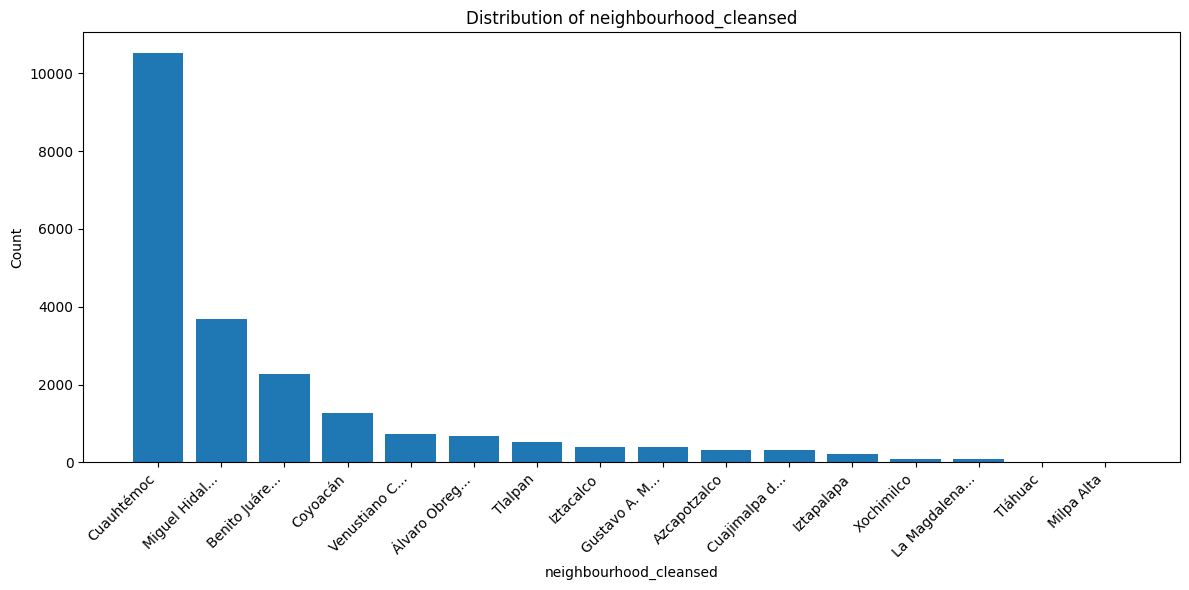

In [111]:
# Plot barplot to visualize frequency distribution of each neighbourhood
plot_barplot(
    df=df_features,
    vars=['neighbourhood_cleansed'],
    figsize_height=6
)


La distribución de listings entre las alcaldías es muy desigual, lo que refleja la verdadera estructura del mercado de alquileres a corto plazo en la Ciudad de México. Las zonas centrales concentran una gran cantidad de propiedades, mientras que las zonas periféricas tienen una representación limitada. Este desequilibrio es previsible y se mantiene, ya que el objetivo es modelar condiciones de mercado realistas en lugar de imponer una cobertura geográfica uniforme.

##### Distribución de precios por alcaldía

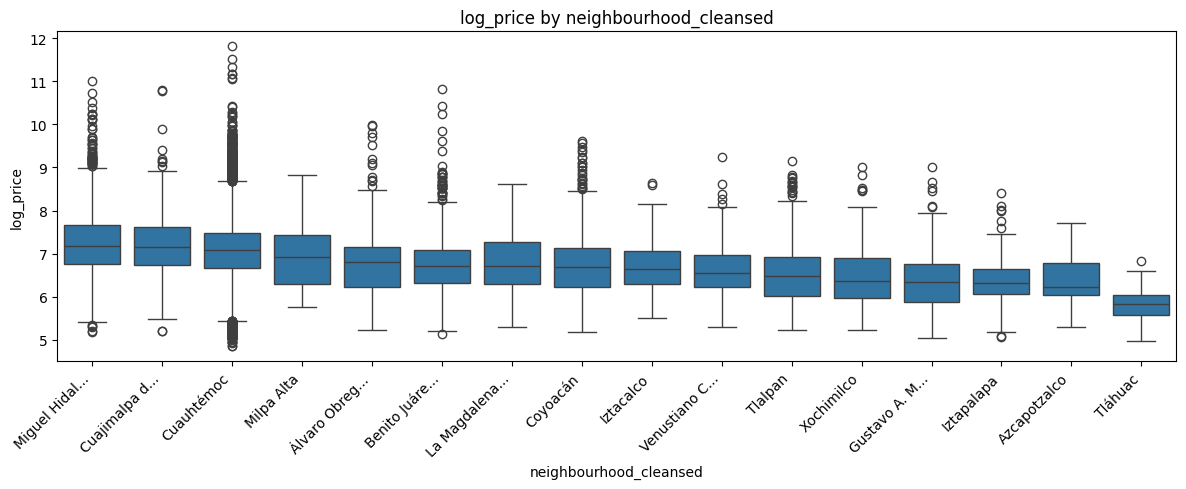

In [112]:
# Plot boxplot to visualize distribution of log_price by neighbourhood
plot_boxplot(
    df=df_features,
    vars=['neighbourhood_cleansed'],
    target= 'log_price',
    figsize_height=5
)

In [113]:
# Compute median log_price grouped by neighbourhood
print("========== Median log_price by neighbourhood ==========")
df_features.groupby('neighbourhood_cleansed')['log_price'].median().sort_values(ascending=False)


========== Median log_price by neighbourhood ==========


neighbourhood_cleansed
Miguel Hidalgo            7.174724
Cuajimalpa de Morelos     7.159292
Cuauhtémoc                7.079184
Milpa Alta                6.921658
Álvaro Obregón            6.802395
Benito Juárez             6.705639
La Magdalena Contreras    6.703187
Coyoacán                  6.688975
Iztacalco                 6.639876
Venustiano Carranza       6.549651
Tlalpan                   6.472346
Xochimilco                6.364737
Gustavo A. Madero         6.345636
Iztapalapa                6.309918
Azcapotzalco              6.220590
Tláhuac                   5.834811
Name: log_price, dtype: float64

El gráfico de boxplots de `log_price` por `neighbourhood` evidencia diferencias claras en el nivel y la dispersión de precios entre alcaldías. Alcaldías como Miguel Hidalgo y Cuauhtémoc concentran precios más altos y distribuciones más amplias, reflejando tanto alojamientos premium como una mayor heterogeneidad en la oferta. 

En contraste, alcaldías periféricas como Iztapalapa, Azcapotzalco y Tláhuac muestran medianas considerablemente más bajas y distribuciones más compactas, lo que indica un mercado más homogéneo y orientado a listings de menor precio.

La presencia de outliers también es relevante, ya que evidencia la existencia de alojamientos con precios atípicos que se alejan del comportamiento general del área. Estos casos pueden corresponder a propiedades de lujo muy específicas o a estrategias de fijación de precios poco comunes.

Estos patrones sugieren que `neighbourhood` captura una parte relevante de la variabilidad del precio. En particular:

- Introduce variaciones sistemáticas en el nivel de precios, evidentes en las diferencias de medianas entre alcaldías.
- Refleja factores estructurales del mercado inmobiliario y turístico, donde la ubicación es uno de los determinantes principales del valor del alojamiento.

##### Validación espacial y barrios

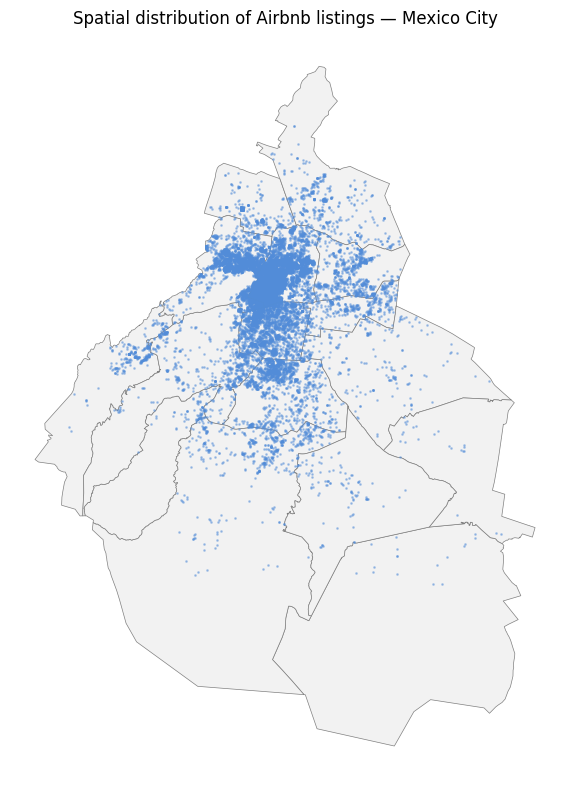

In [114]:
# Load neighborhood polygons
neigh_gdf = gpd.read_file("../data/raw_data/neighbourhoods.geojson")

# Create GeoDataFrame for listings
listings_gdf = gpd.GeoDataFrame(
    df_features,
    geometry=gpd.points_from_xy(
        df_features["longitude"],
        df_features["latitude"]
    ),
    crs="EPSG:4326"
)

# Ensure both GeoDataFrames use the same CRS
if neigh_gdf.crs != listings_gdf.crs:
    listings_gdf = listings_gdf.to_crs(neigh_gdf.crs)

# Plot map
fig, ax = plt.subplots(figsize=(8, 8))

# Plot neighborhoods (map)
neigh_gdf.plot(
    ax=ax,
    color="#f2f2f2",  
    edgecolor="gray",
    linewidth=0.5
)

# Plot listings (points)
listings_gdf.plot(
    ax=ax,
    color="#528cd8",
    markersize=1,
    alpha=0.4
)

ax.set_title("Spatial distribution of Airbnb listings — Mexico City")
ax.axis("off")

plt.tight_layout()
plt.show()

In [115]:
# Validate spatial coherence: compare neighbourhood labels with point-in-polygon assignment

NEIGH_COL = "neighbourhood_geo"

# Rename neighbourhood column in polygons for clarity
neigh_gdf = neigh_gdf.rename(
    columns={"neighbourhood": "neighbourhood_geo"}
)

# Spatial join: assign each listing to a neighbourhood polygon (point-in-polygon)
listings_geo_joined = gpd.sjoin(
    listings_gdf,
    neigh_gdf[[NEIGH_COL, "geometry"]],
    how="left",
    predicate="within"
)

# Check coherence: does dataset label match polygon assignment?
listings_geo_joined["neighbourhood_match"] = (
    listings_geo_joined["neighbourhood_cleansed"]
    == listings_geo_joined[NEIGH_COL]
)

# Compute summary metrics (match and mismatch rates)
match_rate = listings_geo_joined["neighbourhood_match"].mean() * 100
mismatch_rate = 100 - match_rate

# Extract mismatched listings for inspection
mismatches = listings_geo_joined[
    listings_geo_joined["neighbourhood_match"] == False
]

# Sample of mismatches with key attributes
mismatches_sample = mismatches[
    ["neighbourhood_cleansed", NEIGH_COL, "latitude", "longitude"]
].head(10)

# Print validation results
print("========== Spatial Coherence Validation Results ==========")
print(f"Match rate: {match_rate:.2f}%")
print(f"Mismatch rate: {mismatch_rate:.2f}%\n")

# Print sample of mismatched listings
print("========== Sample of Mismatched Listings ==========")
print(mismatches_sample)


========== Spatial Coherence Validation Results ==========
Match rate: 100.00%
Mismatch rate: 0.00%

========== Sample of Mismatched Listings ==========
Empty DataFrame
Columns: [neighbourhood_cleansed, neighbourhood_geo, latitude, longitude]
Index: []


Se visualizó la distribución geográfica de los listings utilizando las coordenadas de latitud y longitud sobre un mapa de la Ciudad de México. Todos los puntos se encuentran dentro de los límites esperados de la ciudad, lo que indica que las coordenadas son espacialmente consistentes y no presentan errores graves de geocodificación.

Adicionalmente, se realizó una validación de coherencia espacial asignando cada listing a un polígono de barrio mediante una operación point-in-polygon y comparando dicho resultado con la variable `neighbourhood_cleansed` del dataset. El análisis arrojó una *tasa de coincidencia del 100%*, confirmando una consistencia total entre la ubicación geográfica de los listings y su etiqueta de barrio.

Estos resultados validan el uso conjunto de las coordenadas geográficas y las variables basadas en alcaldías dentro del proceso de modelado.

### Características de la propiedad y tipo de alojamiento

In [116]:
# Define property and room features in variable 'property_and_room_features'
property_and_room_features = ["property_type", "room_type"]  

# Generate a basic profile of property and room features
basic_profile(df_features, property_and_room_features)

======== Basic Profile ========


,data_type,non_null,unique,null,null_ratio_%
property_type,str,21547,76,0,0.0
room_type,str,21547,4,0,0.0


Podemos observar que las variables `property_type` y `room_type` están completas: no presentan valores nulos y tienen cobertura total en los 21,666 registros. Sin embargo, su estructura es muy distinta.

`room_type` tiene únicamente 4 categorías distintas, lo que la convierte en una variable compacta y manejable. Es fácil de interpretar y probablemente muy informativa para explicar variaciones en el precio, ya que, como vimos anteriormente, la diferencia entre un alojamiento completo, una habitación privada o una habitación compartida suele implicar diferencias importantes en el precio por noche del alojamiento.

En contraste, `property_type` presenta 76 categorías únicas. Esta alta cardinalidad refleja la diversidad de tipos de vivienda disponibles en la plataforma (por ejemplo: apartamentos, casas, lofts, guesthouses, entre otros). Aunque esta granularidad puede aportar información adicional sobre las características estructurales del alojamiento, también implica una distribución más fragmentada de las observaciones entre categorías. Para esta variable podríamos aplicar algún tipo de agrupación o simplificación que capture las diferencias estructurales más relevantes entre propiedades.

##### Distribución de `property_type` y `room_type`

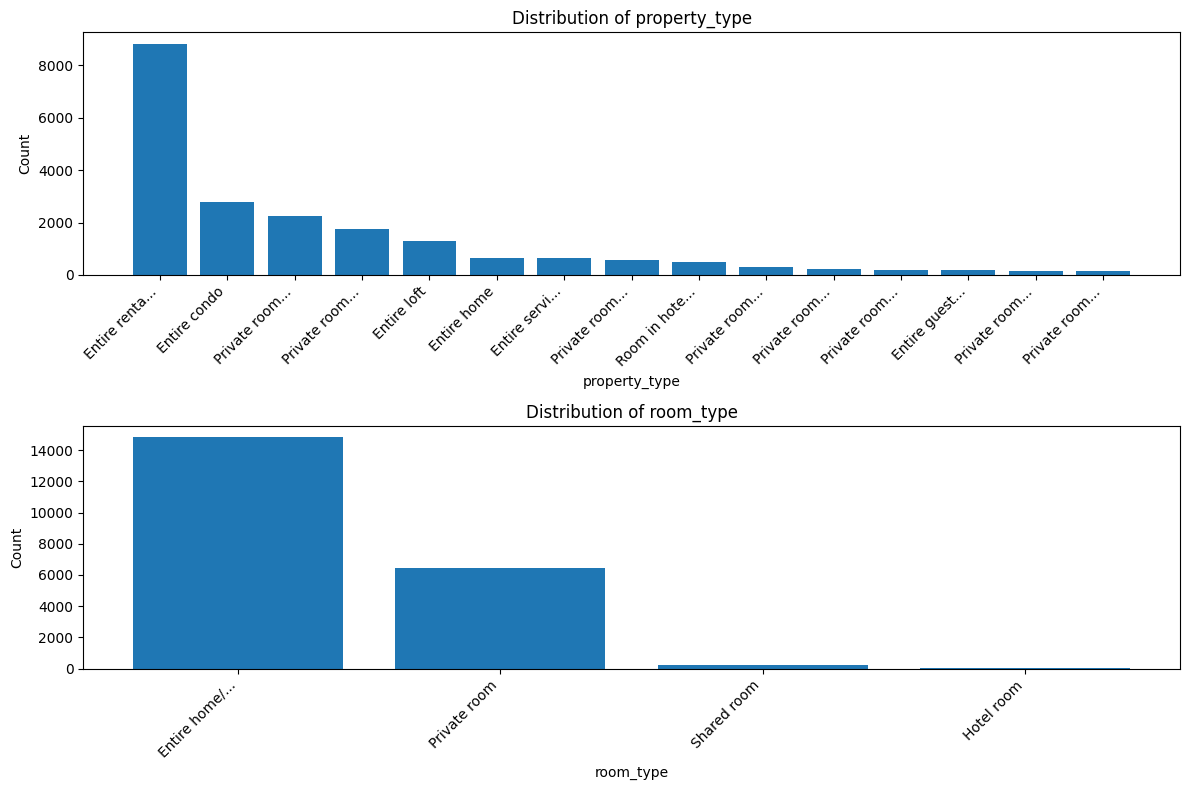

In [117]:
# Plot barplot to visualize frequency distribution of property and room features
# Apply top 15 most frequent categories only to property_type
plot_barplot(
    df=df_features,
    vars=property_and_room_features,
    top_n= 15
)

Para `property_type`, en el gráfico se observa que la categoría *Entire rental unit* domina con diferencia, superando las 8,000 propiedades. Esto indica que la mayoría de los anfitriones ofrecen unidades completas, lo cual puede reflejar una preferencia del mercado por espacios privados. Otras categorías como *Entire condo* y *Private room in rental unit* también tienen presencia significativa, mientras que tipos más específicos como lofts o casas completas aparecen en menor proporción. También existe una larga cola de categorías con muy baja frecuencia, donde muchas de ellas no superaran las 10 observaciones, lo que refleja tipos de propiedades con una oferta marginal y poco representativa.

`room_type` presenta una estructura mucho más compacta: apenas cuatro categorías, de las cuales *Entire home/apt* y *Private room* representan la gran mayoría de los listings. *Shared room* y *Hotel room*, tienen una presencia significativamente menor.

La distribución de `room_type` refleja la estructura real del mercado. La oferta en Airbnb CDMX está claramente orientada hacia espacios completos y habitaciones privadas, lo que indica una preferencia dominante por opciones con mayor nivel de privacidad.

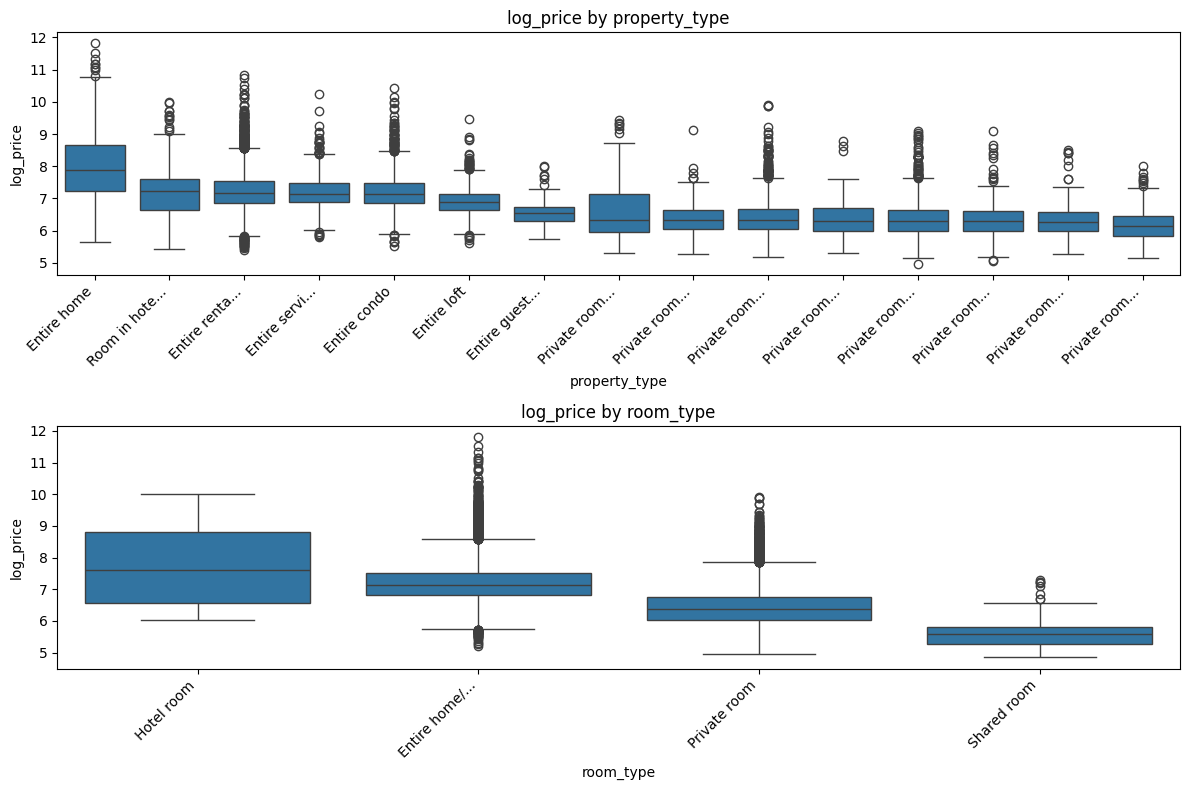

In [118]:
# Plot boxplot to visualize distribution of log_price by property and room features
# Apply top 15 most frequent categories only to property_type
plot_boxplot(
    df=df_features,
    vars=property_and_room_features,
    target= 'log_price',
    top_n = 15
)

==== MODIFICAR DESPUES DE ARREGLAR LA FUNCION ========

El boxplot de `room_type` muestra una separación clara entre las distintas categorías de alojamiento. En general, los alojamientos clasificados como *Entire home/apt* presentan las medianas de precio más altas y la mayor dispersión, lo cual refleja la diversidad de este tipo de propiedades disponibles en la plataforma, desde departamentos pequeños hasta alojamientos de mayor valor.

*Private room* presenta una mediana inferior y una menor variabilidad, *Shared room* y *Hotel room* se concentran en rangos de precio más bajos y con menor dispersión relativa. 

En conjunto, el gráfico evidencia que `room_type` introduce diferencias sistemáticas en el nivel de precios, lo que confirma su relevancia como variable explicativa para el modelo.

El boxplot de `property_type` muestra variaciones adicionales en el precio dependiendo de la estructura física del alojamiento. Las categorías correspondientes a propiedades completas, como *Entire rental unit* y *Entire condo* , presentan medianas más elevadas y mayor dispersión, reflejando la heterogeneidad en este tipo de alojamientos.

Categorías asociadas a habitaciones dentro de una propiedad, como *Private room in rental unit* o *Private room in home*, presentan medianas más bajas y distribuciones más compactas. Esto es consistente con la menor privacidad y el menor espacio ofrecido en este tipo de hospedaje.

También se observan algunas categorías con precios sistemáticamente más bajos, como **Private room in guesthouse** o **Room in hotel**, lo que sugiere que ciertos tipos de propiedad están asociados a segmentos de mercado más económicos.

En general, este análisis sugiere que `property_type` captura diferencias estructurales entre alojamientos que pueden influir en el precio, aunque su alta cardinalidad requiere considerar estrategias de agrupación o reducción de categorías antes de incorporarla en el modelo predictivo.

##### Agrupación de `property_type`

In [119]:
# Show all rows in output (no truncation)
#pd.set_option("display.max_rows", None)

# Print counts of property_type
print("======== Counts of property type =======\n")
print(df_features['property_type'].value_counts())

# Reset option back to default (truncated output)
#pd.reset_option("display.max_rows")


======== Counts of property type =======

property_type
Entire rental unit                8810
Entire condo                      2763
Private room in rental unit       2239
Private room in home              1747
Entire loft                       1309
                                  ... 
Shared room in casa particular       1
Private room in minsu                1
Tower                                1
Private room in earthen home         1
Barn                                 1
Name: count, Length: 76, dtype: int64


Como podemos observar, la variable `property_type` contiene un gran número de categorías muy específicas (por ejemplo: *Entire rental unit*, *Private room in home*, *Room in boutique hotel*, etc.). Muchas de estas categorías combinan dos tipos de información:

- Tipo de habitación (por ejemplo: *Entire*, *Private room*, *Shared room*)
- Tipo de propiedad o estructura inmobiliaria donde se encuentra (por ejemplo: *apartment*, *house*, *hotel*)

Dado que el dataset ya incluye una variable separada llamada `room_type`, mantener todas las categorías originales de `property_type` podría introducir redundancia y una alta cardinalidad que puede dificultar el análisis y el modelado.

Para mejorar la interpretabilidad y la estabilidad del modelo, `property_type` se transformará en categorías más amplias que representen el tipo estructural donde se encuentra la propiedad. Esto permite reducir el ruido generado por categorías poco frecuentes y tratar de forma consistente propiedades similares.

En este proceso, las categorías originales se agruparán en un conjunto reducido de grupos:

- **Apartment / Condos / lofts:** Espacios privados o compartidos dentro departamentos o unidades residenciales.
- **Houses / Townhouses / Villas:** Espacios privados o compartidos dentro de viviendas completas o casas.
- **Hotel / Hospitality / Hostels:** Espacios que brindan alojamientos y  servicios de un hotel.
- **Guesthouses / Guestauites:** Espacios donde residen los anfitriones y alquilan habitaciones a turistas
- **Unique / Nature stays:** Espacios no convencionales, distintivas o inmersos en naturaleza.
- **Others:** Categorías ambiguas o de muy baja frecuencia que no encajan claramente en los grupos principales.

Esta transformación simplificará el espacio de características mientras conserva la información estructural más relevante sobre el tipo de alojamiento.

In [120]:
property_map = {
    # Apartments / Condos / Lofts
    "Entire rental unit": "apartment",
    "Entire condo": "apartment",
    "Entire loft": "apartment",
    "Entire serviced apartment": "apartment",
    "Room in serviced apartment": "apartment",
    "Room in aparthotel": "apartment",
    "Private room in condo": "apartment",
    "Private room in loft": "apartment",
    "Private room in serviced apartment": "apartment",
    "Shared room in condo": "apartment",
    "Private room in rental unit": "apartment",
    "Shared room in rental unit": "apartment",
    "Shared room in loft": "apartment",

    # Houses / Townhouses / Villas
    "Entire home": "house",
    "Entire townhouse": "house",
    "Entire villa": "house",
    "Entire cottage": "house",
    "Entire vacation home": "house",
    "Private room in home": "house",
    "Private room in townhouse": "house",
    "Private room in vacation home": "house",
    "Private room in villa": "house",
    "Shared room in home": "house",
    "Shared room in townhouse": "house",
    "Private room in casa particular": "house",
    "Casa particular": "house",
    "Room in casa particular": "house",
    "Shared room in casa particular": "house",
    "Tiny home": "house",
    "Private room in tiny home": "house",
    "Earthen home": "house",
    "Private room in earthen home": "house",

    # Guesthouses / Guestauites
    "Entire guesthouse": "guesthouse",
    "Entire guest suite": "guesthouse",
    "Private room in guesthouse": "guesthouse",
    "Private room in guest suite": "guesthouse",
    "Shared room in guesthouse": "guesthouse",

    # Hotel / Hospitality / Hostels
    "Room in hotel": "hotel",
    "Room in boutique hotel": "hotel",
    "Private room in hostel": "hotel",
    "Shared room in hostel": "hotel",
    "Entire hostel": "hotel",
    "Shared room in hotel": "hotel",
    "Private room in bed and breakfast": "hotel",
    "Shared room in bed and breakfast": "hotel",
    "Room in bed and breakfast": "hotel",
    
    # Unique / Nature stays
    "Dome": "unique/nature",
    "Private room in dome": "unique/nature",
    "Hut": "unique/nature",
    "Private room in hut": "unique/nature",
    "Yurt": "unique/nature",
    "Private room in yurt": "unique/nature",
    "Tent": "unique/nature",
    "Private room in tent": "unique/nature",
    "Barn": "unique/nature",
    "Private room in barn": "unique/nature",
    "Camper/RV": "unique/nature",
    "Farm stay": "unique/nature",
    "Private room in farm stay": "unique/nature",
    "Cabin": "unique/nature",
    "Entire cabin": "unique/nature",
    "Private room in cabin": "unique/nature",
    "Entire chalet": "unique/nature",
    "Chalet": "unique/nature",
    "Entire bungalow": "unique/nature",
    "Bungalow": "unique/nature",
    "Lighthouse": "unique/nature",
    "Private room in lighthouse": "unique/nature",
    "Nature lodge": "unique/nature",
    "Private room in nature lodge": "unique/nature",
    "Holiday park": "unique/nature",
    "Private room in resort": "unique/nature",
    "Private room in minsu": "unique/nature",
    "Private room in cottage": "unique/nature",
    "Shipping container": "unique/nature",
    "Private room in shipping container": "unique/nature",
    "Castle": "unique/nature",
    "Private room in castle": "unique/nature",
    "Tower": "unique/nature",
    "Private room in tower": "unique/nature"

    # Other (ambiguous)
}

# Apply the mapping
df_features["property_group"] = df_features["property_type"].map(property_map).fillna("other")

# View the proportion of each group
df_features['property_group'].value_counts(normalize=True)*100


property_group
apartment        77.245092
house            13.393976
hotel             4.617812
guesthouse        3.736019
unique/nature     0.816819
other             0.190282
Name: proportion, dtype: float64

Después de agrupar las categorías originales de `property_type` en `property_group`, se observa que la gran mayoría de los alojamientos pertenecen al grupo *apartment*, lo cual es esperable en un entorno urbano como la CDMX donde predominan los departamentos y unidades en edificios residenciales.

Los *house* representan el segundo grupo más frecuente, seguido por *guesthouse* y *hotel*, que corresponden principalmente a alojamientos dentro de propiedades privadas, compartidas o establecimientos de hospitalidad.

Las categorías *unique/nature* y *other* concentran una proporción muy pequeña de los registros. Estas incluyen tipos de alojamiento poco convencionales, inmersos en naturaleza o difíciles de clasificar dentro de las categorías principales.

======= Mean price by property group =======

                    mean    median  count
property_group                           
apartment       7.044477  7.028644  16644
hotel           6.924242  6.866933    995
other           6.848492  6.579251     41
house           6.779230  6.505036   2886
unique/nature   6.690582  6.374933    176
guesthouse      6.296407  6.291569    805


======= Counts by Room type vs Property group =======

property_group   apartment  guesthouse  hotel  house  other  unique/nature
room_type                                                                 
Entire home/apt      13573         260      3    840     17            126
Hotel room               9           0     36      2      0              0
Private room          3041         493    849   1991     24             50
Shared room             21          52    107     53      0              0


======= Mean price by Room type and Property group =======

property_group   apartment  guesthouse  hotel  ho

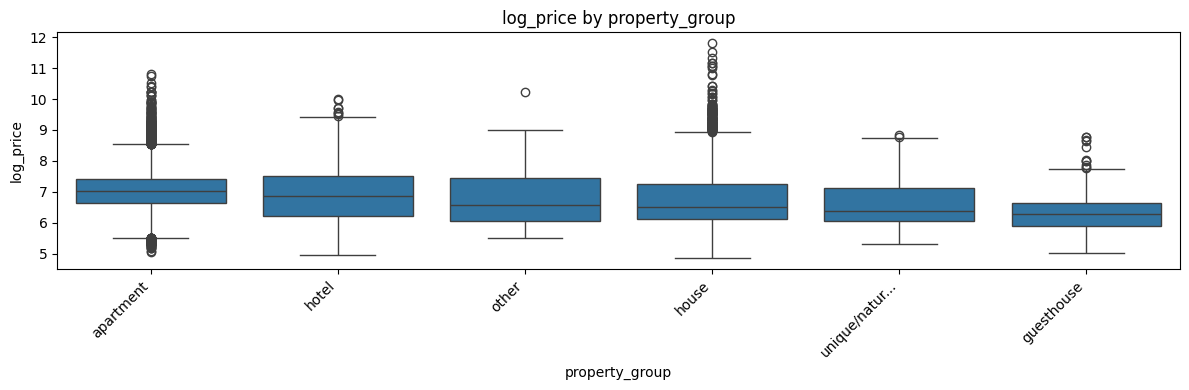

In [121]:
print("======= Mean price by property group =======\n")
print(df_features.groupby(['property_group'])['log_price'].agg(['mean', 'median', 'count']). \
      sort_values(by='mean', ascending=False))
print("\n")

print("======= Counts by Room type vs Property group =======\n")
print(pd.crosstab(df_features['room_type'], 
                  df_features['property_group']))
print("\n")

# Pivot table con mean log_price
print("======= Mean price by Room type and Property group =======\n")
print(pd.pivot_table(
    df_features,
    values="log_price",
    index="room_type",
    columns="property_group",
    aggfunc="mean"
).round(2))
print("\n")

# Plot boxplot to visualize distribution of log_price by property groups
plot_boxplot(
    df=df_features,
    vars= ['property_group'],
    target= 'log_price'
)


La distribución de `property_group` muestra que el tipo de espacio de la propiedad sí introduce ciertas diferencias en el precio de los alojamientos, aunque su efecto podría ser moderado en comparación con otras variables como `room_type`.

El grupo *apartment* presenta la media más alta, lo cual es consistente con la distribución observada previamente: la mayoría de los listings en esta categoría corresponden a propiedades completas (Entire home/apt), que suelen tener tarifas más elevadas.

El grupo *hotel* muestra también precios relativamente altos, se observa que las habitaciones privadas en *hotel* presentan una media mayor que las habitaciones privadas en *apartment*, *house* o *guesthouse* y el mismo comportamiento con las habitaciones compartidas, una mayor media en *hotel* que en *house* o *guesthouse* Esto sugiere que incluso cuando el tipo de habitación es el mismo (*Private room* o *Shared room*), el contexto de la propiedad influye en el valor del alojamiento.

Por su parte, *house* presenta una media inferior a *apartment* y *hotel*, lo cual puede explicarse por la alta proporción de habitaciones privadas y compartidas dentro de viviendas, una modalidad común en plataformas como Airbnb. Sin embargo, dentro de las propiedades tipo *Entire room/apt*, *House* presenta la media mas alta, lo cual es consistente con el hecho de que alojamientos enteros en viviendas completas ofrecen mayor espacio y privacidad.

Las categorías *guesthouse* y *unique/nature* tienden a mostrar precios más bajos en promedio. En el caso de las *guesthouses*, esto se relaciona con el hecho de que muchas corresponden a habitaciones dentro de propiedades compartidas, mientras que *unique/nature* agrupa alojamientos menos convencionales o con menor volumen de oferta.

En conjunto, estos resultados sugieren que `property_group` captura ciertas diferencias estructurales en el mercado de alojamientos, aunque su capacidad explicativa del precio probablemente sea menor que la de variables relacionadas con el tipo de habitación o la capacidad del alojamiento.

### Características del alojamiento y capacidad

In [122]:
# Define room and capacity features in variable 'room_and_capacity_features'
room_and_capacity_features = ["accommodates", "bathrooms", "bedrooms", "beds"]

# Generate an advanced statistical profile of 'room_and_capacity_features'
advanced_profile(df_features, room_and_capacity_features)


===== Numerical Statistics =====


,accommodates,bathrooms,bedrooms,beds
dtype,int64,float64,float64,float64
count,21547,21547,21547,21547
non_null,21547,21535,21450,21531
null,0,12,97,16
null_ratio_%,0.0,0.06,0.45,0.07
unique,16,28,21,28
mean,3.379,1.438,1.52,1.932
std,2.296,0.896,1.049,1.592
coef_var,0.679,0.623,0.69,0.824
IQR,2.0,1.0,1.0,1.0


El resumen estadístico de las variables de `accommodates`, `bathrooms`, `bedrooms` y `beds` muestra lo siguiente:

- **Media vs mediana:** En la mayoría de las variables, la media tiende a ser mayor que la mediana, lo que indica *asimetría positiva* (cola hacia la derecha). Esto sugiere la presencia de valores altos poco frecuentes que elevan el promedio.  En general, los alojamientos tienen capacidad en promedio para ~3.4 personas, ~1.45 baños, ~1.5 dormitorios y ~1.9 camas.
- **Máximos muy alejados del percentil 75:** La brecha entre el tercer cuartil (Q3) y el valor máximo es amplia (21 baños, 40 dormitorios, 40 camas), lo que evidencia *valores extremos* que podrían corresponder a propiedades atípicas o posibles errores de registro. 
- **Concentración en percentiles bajos**: Los percentiles 25, 50 y 75 están relativamente próximos entre sí en comparación con el rango total, lo que indica que la mayor parte de los alojamientos se concentra en capacidades pequeñas o medianas (2–4 huéspedes, 1–2 baños, 1–2 dormitorios, 1–2 camas).

Este resumen confirma que el mercado estándar en la Ciudad de México está dominado por alojamientos pequeños (1–4 huéspedes, 1–2 dormitorios, 1 baño), mientras que los alojamientos grandes son minoritarios y presentan valores extremos que conviene revisar. Estas variables son altamente informativas para explicar el precio, pero podrían requerir limpieza de outliers y validación de registros inconsistentes para mejorar la calidad del modelo predictivo.

##### Distribución de las variables en **room_and_capacity_features**

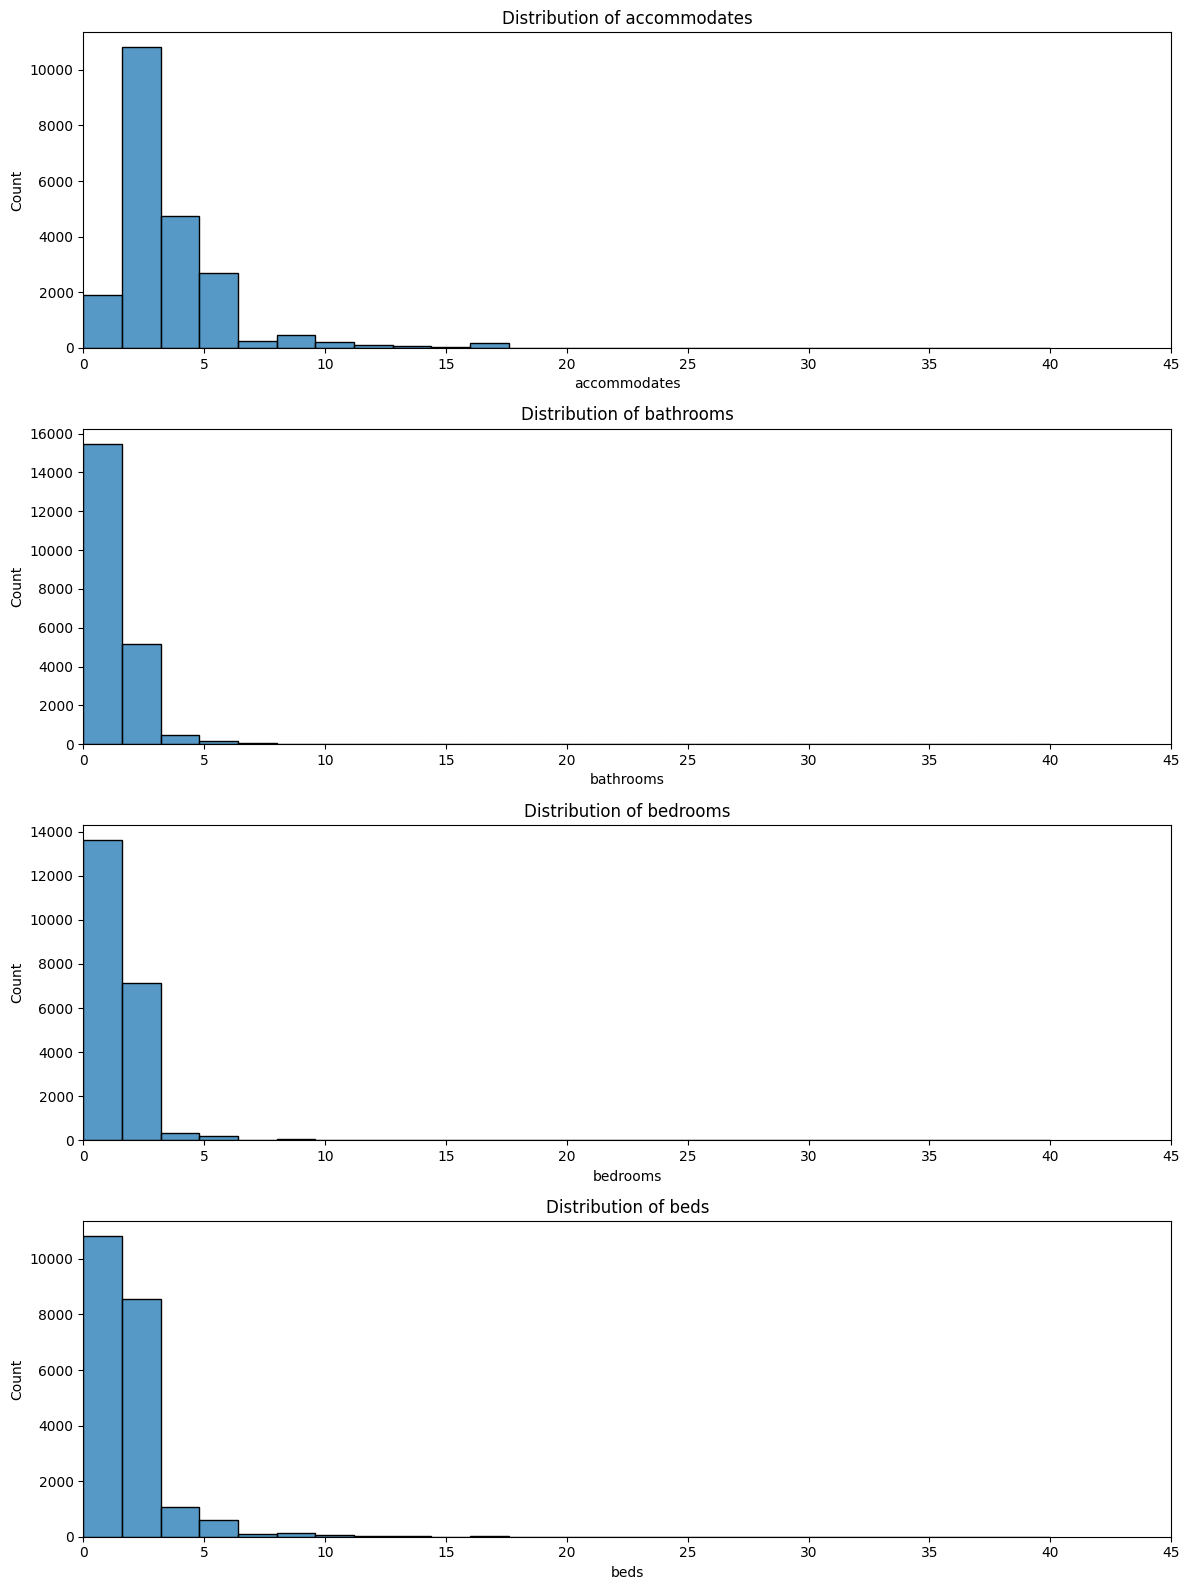

In [123]:
# Plot histogram to visualize the distribution of room and capacity features
plot_histogram(
    df= df_features,
    vars= room_and_capacity_features,
    bins= 25
)

Las gráficas de distribución confirman y visualizan lo que el resumen numérico sugiere:

``accommodates``:
- Fuerte concentración entre 2 y 4 personas.
- Caída progresiva en frecuencias a partir de 6 huéspedes.
- Cola derecha extensa hasta valores altos (10+), aunque con muy baja frecuencia.
- El mercado está dominado por alojamientos pequeños o medianos.

``bathrooms``:
- Alta concentración en 1 y 2 baños.
- Algunos valores fraccionarios (0.5, 1.5, etc.), lo cual es consistente con baños compartidos o medios baños.
- Existencia de valores extremos muy altos que generan una cola larga y poco representativa.
- La mayoría de propiedades tiene entre 1 y 2 baños, lo que es coherente con estructuras residenciales estándar.

`bedrooms`:
- Gran concentración en 1 dormitorio.
- Disminución rápida conforme aumenta el número de habitaciones.
- Presencia de valores máximos muy alejados del patrón general.
- En el mercado predominan estudios y apartamentos pequeños.

`beds`:
- Distribución similar a bedrooms, pero con mayor variabilidad relativa.
- Mayor dispersión en valores intermedios.


Estas variables presentan tres características estructurales claras:

1. *Distribuciones asimétricas positivas.*
2. *Alta concentración en valores bajos.*
3. *Colas largas con posibles outliers.*

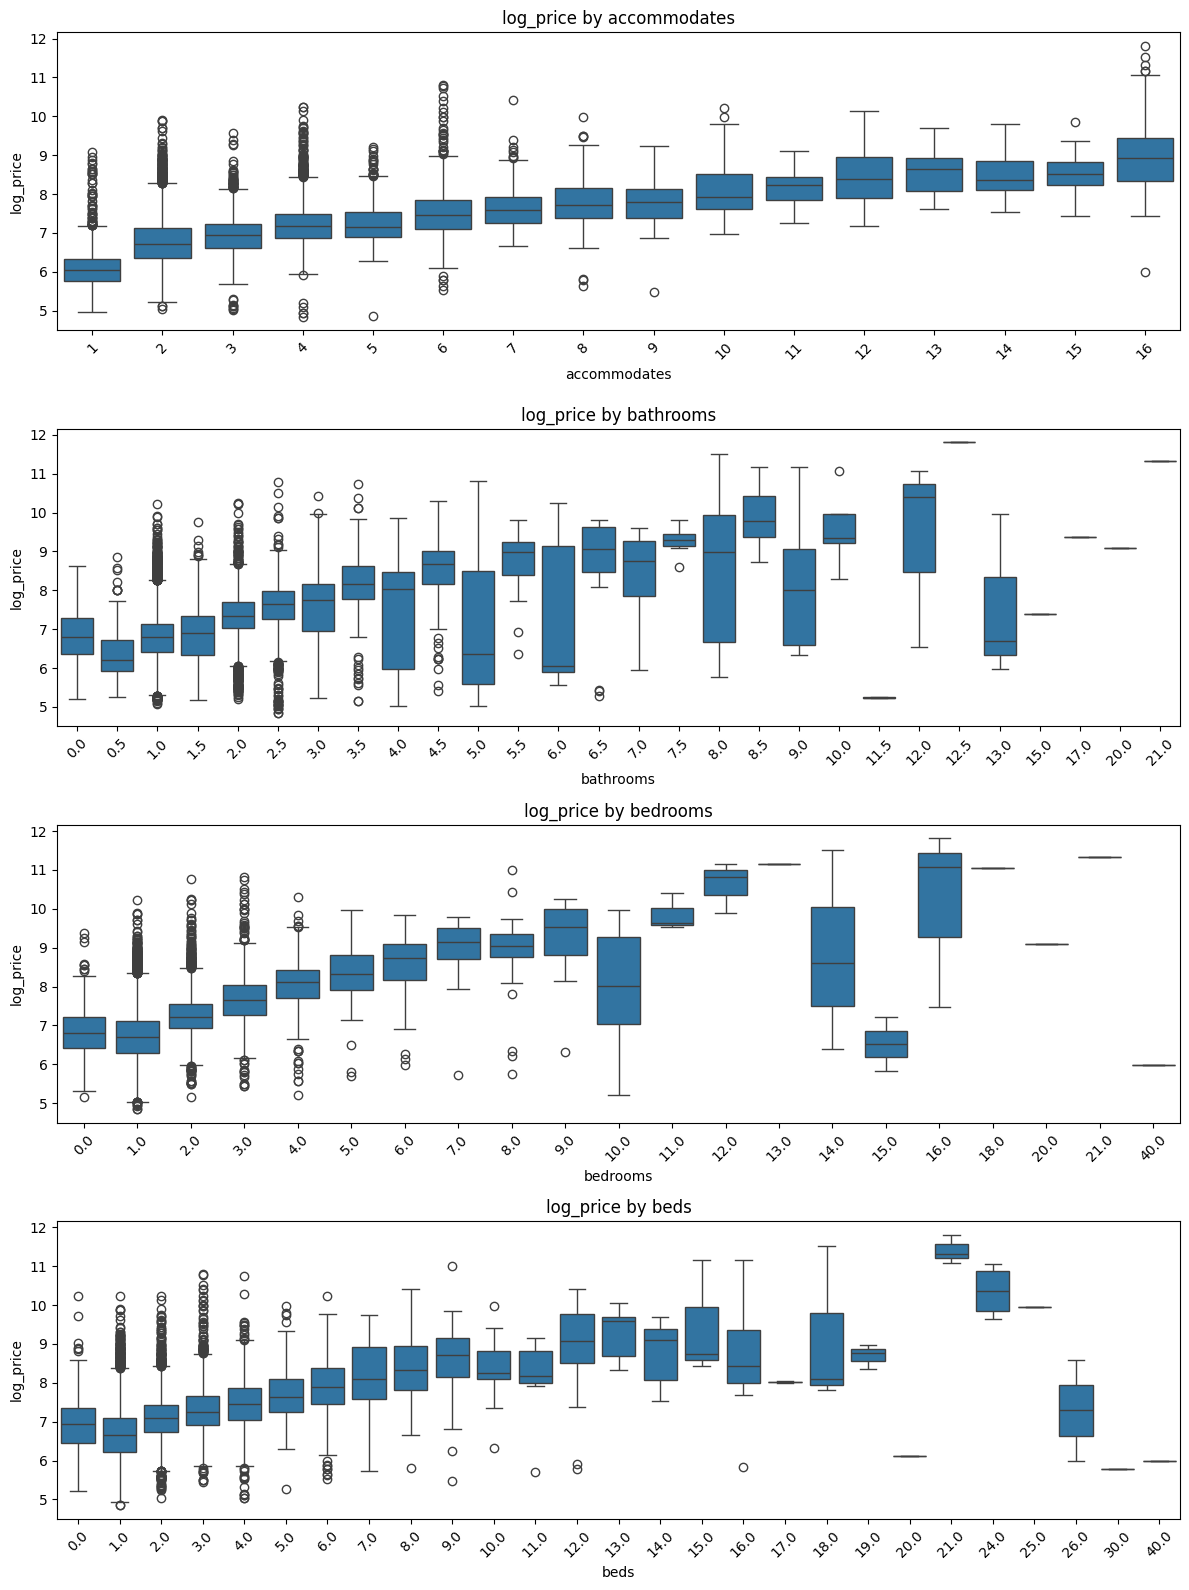

In [124]:
# Plot boxplot to visualize distribution of log_price by room and capacity features
plot_boxplot(
    df=df_features,
    vars=room_and_capacity_features,
    target= 'log_price'
)

En general, se observa una relación positiva entre estas variables y la mediana del precio por noche en escala logarítmica: a medida que aumenta la capacidad del alojamiento o el número de habitaciones, baños o camas, el precio tiende a incrementarse.

En el caso de `accommodates`, la relación es relativamente clara y consistente. La mediana aumenta de forma gradual conforme crece el número de huéspedes permitidos, lo que refleja que propiedades con mayor capacidad suelen ser más grandes o ofrecer más comodidades, y por lo tanto tienden a tener tarifas más altas.

Para `bedrooms`, `bathrooms` y `beds` se observa inicialmente un patrón similar: la mediana aumenta conforme crece el número de habitaciones, baños o camas disponibles. Sin embargo, a partir de ciertos valores elevados estas relaciones comienzan a volverse inestables, con variaciones abruptas en la mediana entre niveles consecutivos. Este comportamiento suele indicar que, en los valores más altos, el número de observaciones es reducido o que se trata de propiedades atípicas.

Debido a esta inestabilidad en los valores extremos, se considerará limitar los valores máximos de estas variables para reducir el efecto de outliers y mejorar la estabilidad de las relaciones entre la capacidad del alojamiento y el precio.

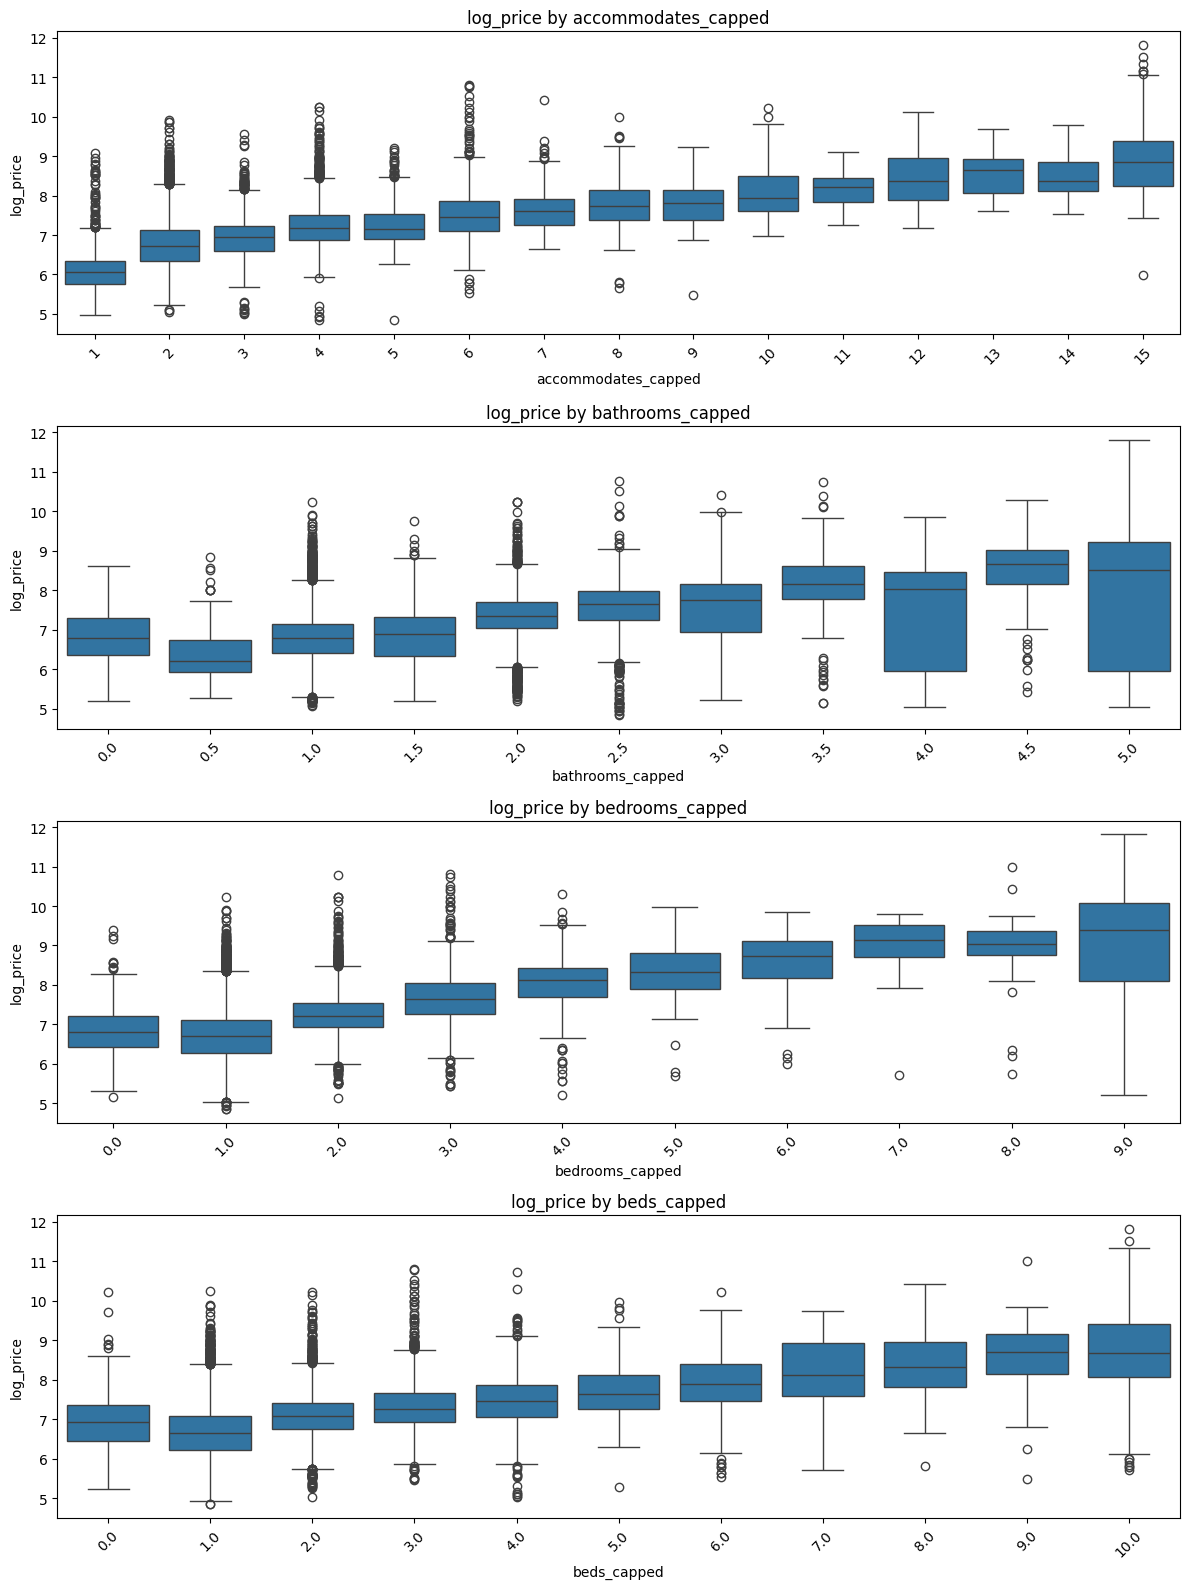

In [125]:
# Cap values for room capacity variables based on EDA
cap_values = {
    "accommodates": 15,
    "bedrooms": 9,
    "beds": 10,
    "bathrooms": 5
}

# Apply capping
for col, cap in cap_values.items():
    capped_col = f"{col}_capped"   # new column
    df_features[capped_col] = df_features[col].clip(upper=cap)

# Define list of room and capacity features with capped values
room_and_capacity_features_capped = ['accommodates_capped', 'bathrooms_capped', 'bedrooms_capped', 'beds_capped']

# Plot boxplot to visualize distribution of log_price by room and capacity features (capped)
plot_boxplot(
    df= df_features,
    vars= room_and_capacity_features_capped,
    target= 'log_price'
)

Tras aplicar el capping a las variables de capacidad del alojamiento, observamos que la relación entre estas variables y el precio se vuelve más estable y consistente.

`bedrooms_capped` y `beds_capped` mantienen una tendencia positiva en la mayor parte de su rango. Aunque en los valores más altos todavía se observan ligeras fluctuaciones, estas son esperables debido al menor número de observaciones en propiedades muy grandes.

Para `bathrooms_capped`, la relación también es positiva en los primeros niveles, aunque presenta algo más de variabilidad en valores altos. Esto se debe principalmente a que los alojamientos con muchos baños son relativamente poco frecuentes en el conjunto de datos.

En el caso de `accommodates_capped`, la relación positiva entre la capacidad máxima de huéspedes y el precio ya estaba presente antes del capping. El capping en esta variable no se aplicó para corregir una relación errática, sino para reducir la influencia de valores muy poco frecuentes en los niveles más altos de capacidad. En estos rangos, el número de observaciones es reducido y suele corresponder a propiedades atípicas (por ejemplo, alojamientos muy grandes o espacios utilizados para eventos). Limitar estos valores permitirá preservar la tendencia general de la variable mientras se mejora la estabilidad de su comportamiento en el conjunto de datos.

En conjunto, el capping permitió reducir la influencia de valores extremos y estabilizar las relaciones entre las variables de capacidad y el precio, preservando al mismo tiempo la señal económica principal: *los alojamientos más grandes o con mayor capacidad tienden a tener precios más elevados.*

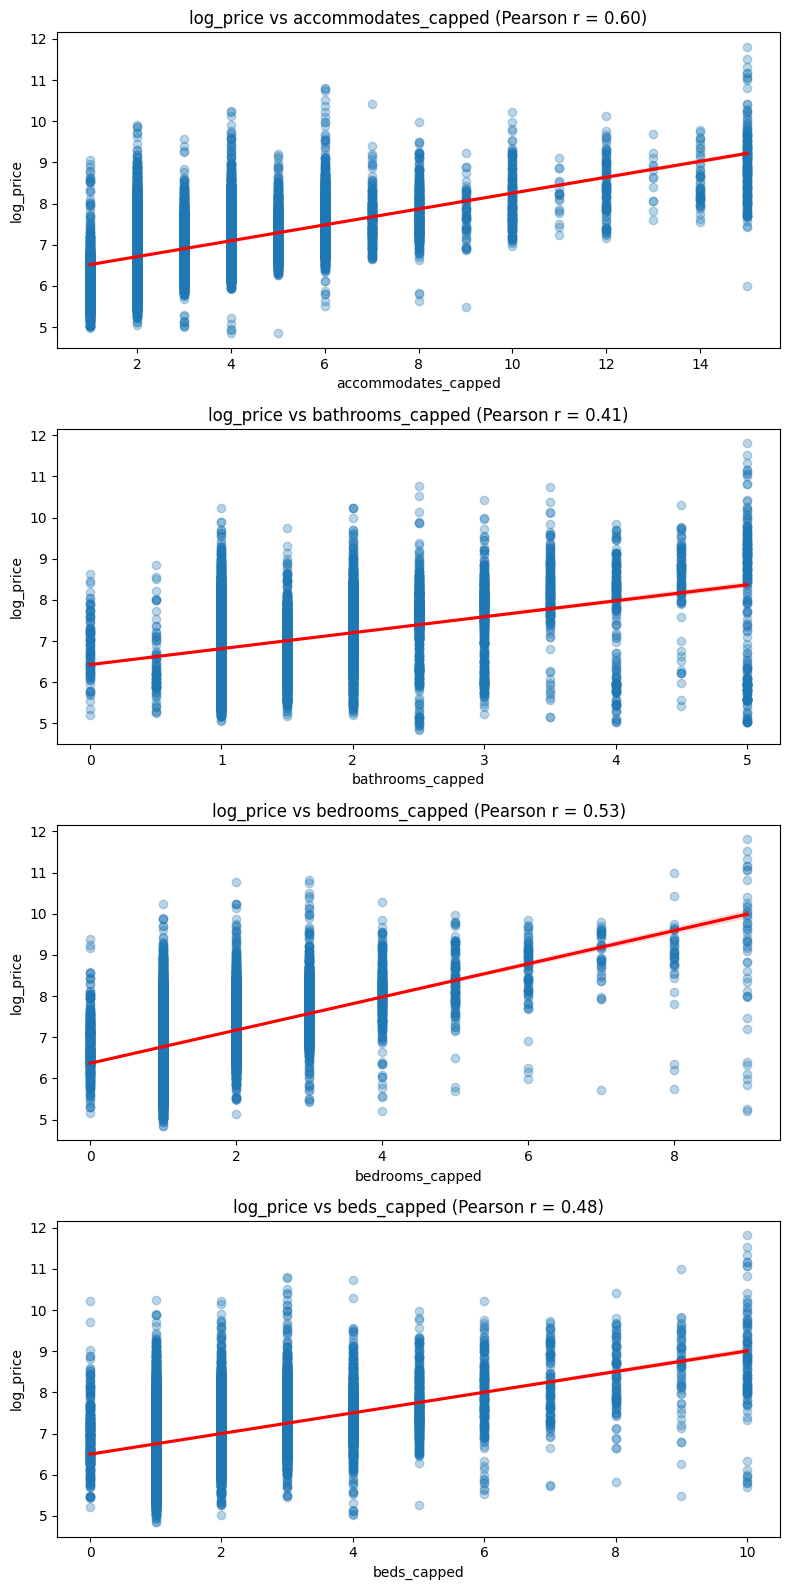

In [126]:
# Plot regplot to visualize relationship between log_price and room and capacity features (capped)
plot_regplot(
    df= df_features,
    vars= room_and_capacity_features_capped,
    target= 'log_price',
    figsize_width= 8
)

### Características sobre restricciones de reserva

In [127]:
# Define booking constraints features in variable 'booking_constraints_features'
booking_constraints_features = ["minimum_nights", "maximum_nights"]

# Generate a basic profile of booking constraints features
print("===== Basic profile of booking constraints =====")
basic_profile(df_features, booking_constraints_features)

===== Basic profile of booking constraints =====
======== Basic Profile ========


,data_type,non_null,unique,null,null_ratio_%
maximum_nights,int64,21547,172,0,0.0
minimum_nights,int64,21547,52,0,0.0


Este grupo de variables describe las *restricciones de estancia* impuestas por el anfitrión (mínimo y máximo de noches permitidas). Estas reglas no determinan directamente el precio, pero pueden influir en la flexibilidad del alojamiento y en el tipo de reserva que puede recibir.

En el dataset no presentan valores nulos y muestran una cardinalidad moderada a alta (53 y 172 valores únicos), lo que refleja cierta variabilidad en las reglas aplicadas.

Dado su carácter operativo, estas variables podrían capturar niveles de flexibilidad del listing, lo que potencialmente impacta en la demanda y, de forma indirecta, en el precio. Por ello se consideran candidatas a evaluación en el modelo, aunque su efecto esperado es secundario frente a variables estructurales como capacidad, ubicación o tipo de propiedad.

##### Distribución de `minimum_nights` y `maximum_nights`

In [128]:
# Compute relative frequency (normalized counts) for each booking constraint feature
for var in booking_constraints_features:
    print(f"====== Relative frequency of {var} ======")
    print(df[var].value_counts(normalize=True).sort_values(ascending=False).head(15))
    print("\n")

====== Relative frequency of minimum_nights ======
minimum_nights
1      0.509187
2      0.276064
3      0.102898
4      0.026775
5      0.018797
7      0.017058
30     0.016591
15     0.005686
6      0.005134
10     0.003819
14     0.002758
28     0.001952
20     0.001740
365    0.001358
8      0.001231
Name: proportion, dtype: float64


====== Relative frequency of maximum_nights ======
maximum_nights
365     0.466288
1125    0.234396
30      0.045784
90      0.035049
60      0.028090
730     0.021343
180     0.019986
28      0.012730
15      0.012348
31      0.011584
120     0.011329
7       0.006874
100     0.005983
45      0.005219
20      0.005092
Name: proportion, dtype: float64




Podemos observar que las restricciones de estancia están altamente concentradas en pocos valores.

`minimum_nights`:
- Aproximadamente el 90% de los listings exige entre 1 y 4 noches*.
- Valores como 7, 10, 15 o 30 noches corresponden a políticas más restrictivas, generalmente asociadas a alquileres de media estancia.

`maximum_nights`:
Las estancias máximas muestran una estructura distinta.
- La mayoría de los hosts (alrededor del 46%) permiten estancias de 1 año.
- Valores como 730 y 1125 (2 y 3 años) sugieren que muchos anuncios no imponen un límite práctico de estancia.
- Restricciones menores (30–90 noches) podrían asociarse a regulaciones locales o estrategias de rotación de huéspedes.

`minimum_nights` podría capturar diferencias en la estrategia de reserva del listing (flexibilidad para estancias cortas), mientras que `maximum_nights` parece reflejar la ausencia de restricciones reales en muchos anuncios, funcionando más como un indicador de política general o cumplimiento normativo que como una condición operativa del hospedaje.

##### Relación de `minimum_nights` y `maximum_nights` con el precio

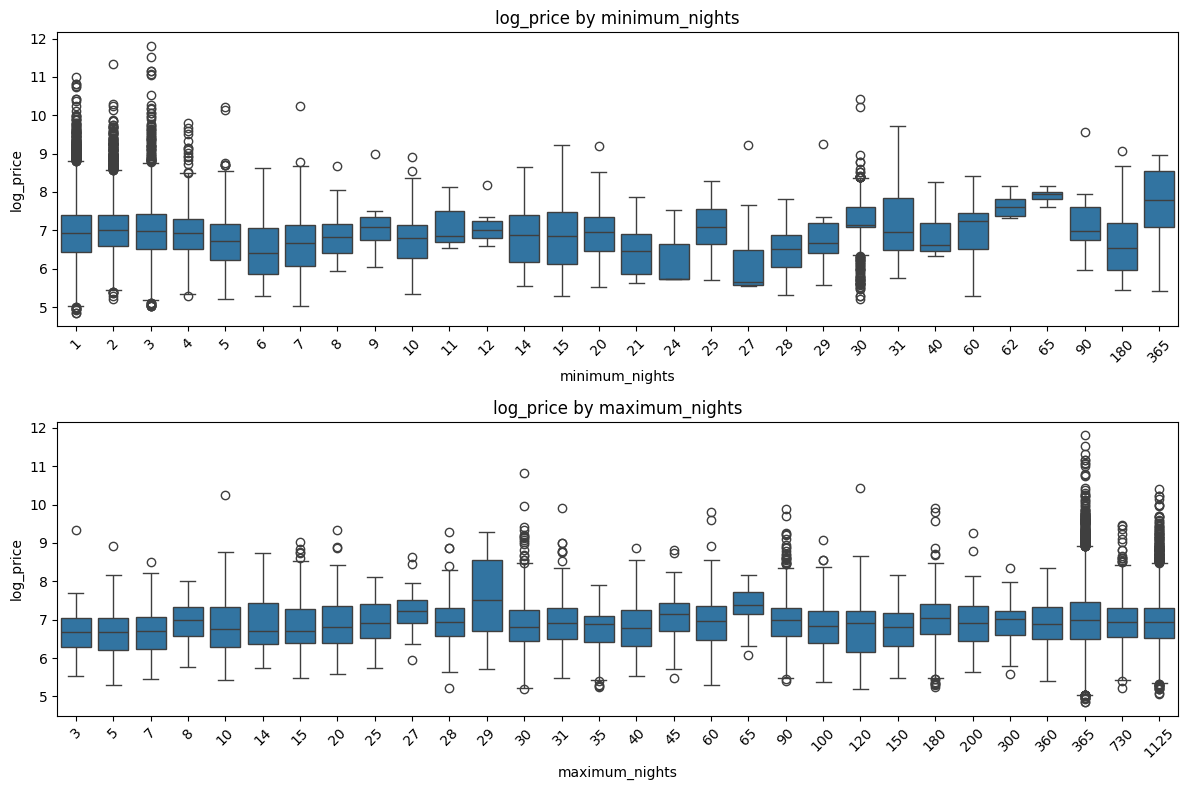

In [129]:
# Plot boxplot to visualize distribution of log_price by booking constraints features
# Apply top 30 most frequent categories
plot_boxplot(
    df=df_features,
    vars= booking_constraints_features,
    target= 'log_price',
    top_n = 30
)

Se analizó la relación entre `log_price` y las variables `minimum_nights` y `maximum_nights` considerando los valores más frecuentes (top 30) en el conjunto de datos.

Para `minimum_nights`, se observa que los valores más comunes (particularmente entre 1 y 3 noches) presentan medianas de precio muy similares, alrededor de 6.94–6.99 en `log_price`. Esto sugiere que, dentro de este rango, las diferencias en el número mínimo de noches no representan cambios relevantes en el comportamiento del precio, sino que corresponden al mismo tipo de mercado: estancias cortas de carácter turístico.

A medida que aumentan los valores de `minimum_nights`, la frecuencia de observaciones disminuye y comienzan a aparecer fluctuaciones en la mediana de precio. Sin embargo, estas variaciones no siguen un patrón claramente monotónico, lo cual indica que la señal económica de esta variable no depende del valor exacto, sino más bien del tipo de estancia que representa. En particular, valores cercanos a 30 noches suelen asociarse con estancias de larga duración o alquiler mensual, lo que constituye un segmento de mercado distinto dentro de la plataforma.

Debido a esta estructura, utilizar `minimum_nights` como una variable numérica continua no captura adecuadamente la lógica del mercado. Por esta razón, se considerará segmentar `minimum_nights` en rangos representativos de diferentes tipos de estancia (por ejemplo, estancias cortas, medias y de largo plazo), permitiendo que el modelo capture mejor estas diferencias estructurales.

En contraste, el análisis de `maximum_nights` muestra que las medianas se mantienen relativamente estables a lo largo de los distintos valores, generalmente alrededor de 6.7–7.0. No se observa una tendencia clara que indique que permitir estancias más largas esté asociado sistemáticamente con precios más altos o más bajos. Además, muchos de los valores altos (por ejemplo 365, 730 o 1125 noches) suelen corresponder a límites administrativos o configuraciones predeterminadas de la plataforma, más que a restricciones reales que influyan en el precio del alojamiento.

Por lo tanto, `maximum_nights` no parece aportar información relevante para explicar la variación en el precio, por lo que se decide no incluir esta variable en el modelo. En cambio, `minimum_nights` se transformará mediante segmentación para capturar de forma más adecuada las diferentes estrategias de estancia presentes en el mercado.

##### Segmentación de `minimum_nights`

====== Distribution of minimum_nights_segment (%) ======
minimum_nights_segment
short_stay     0.898408
medium_stay    0.080429
long_term      0.021163
Name: proportion, dtype: float64

====== Median log_price by minimum_nights_segment ======
minimum_nights_segment
long_term      7.166266
medium_stay    6.782192
short_stay     6.959399
Name: log_price, dtype: float64


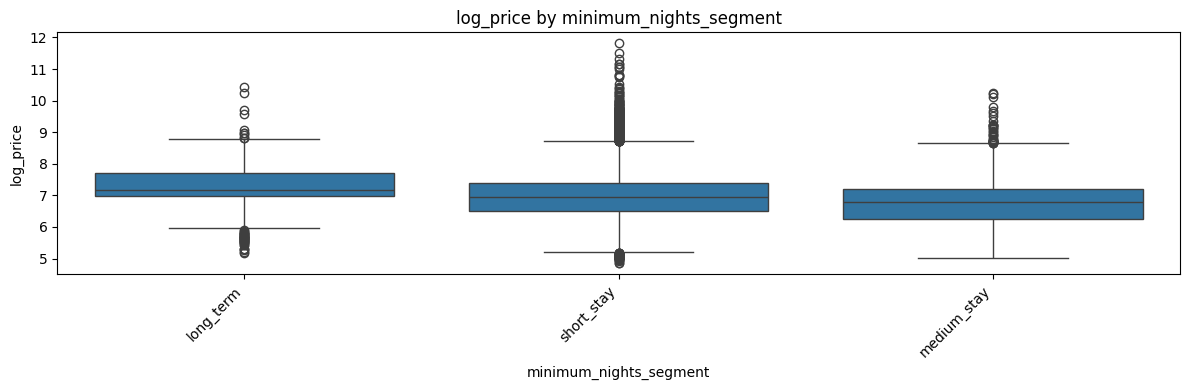

In [130]:
# Define conditions to segment minimum_nights into stay categories
conditions = [
    df_features["minimum_nights"] <= 3,
    (df_features["minimum_nights"] >= 4) & (df_features["minimum_nights"] <= 29),
    #(df_features["minimum_nights"] >= 8) & (df_features["minimum_nights"] <= 29),
    df_features["minimum_nights"] >= 30
]

# Define labels (choices) for each stay category
choices = [
    "short_stay",
    "medium_stay",
    #"extended_stay",
    "long_term"
]

# Create new feature 'minimum_nights_segment' based on conditions and choices
df_features["minimum_nights_segment"] = np.select(
    conditions,
    choices,
    default="unknown"
)

# Print distribution (%) of minimum_nights_segment categories
print("====== Distribution of minimum_nights_segment (%) ======")
print(df_features['minimum_nights_segment'].value_counts(normalize=True))

# Print median log_price for each minimum_nights_segment category
print("\n====== Median log_price by minimum_nights_segment ======")
print(df_features.groupby('minimum_nights_segment')['log_price'].median())

# Plot boxplot to visualize log_price distribution by minimum_nights_segment
plot_boxplot(
    df=df_features,
    vars=['minimum_nights_segment'],
    target='log_price'
)

Con el objetivo de capturar mejor la posible relación entre la duración mínima de estancia y el precio, se optó por segmentar la variable en tres categorías representativas de distintos tipos de estancia:

- *short_stay*: hasta 3 noches
- *medium_stay*: entre 4 y 29 noches
- *long_term*: 30 noches o más

La distribución resultante muestra un alto desbalance entre los segmentos. Aproximadamente el 90% de los listings pertenecen al segmento *short_stay*, mientras que *medium_stay* representa cerca del 8% y *long_term* alrededor del 2% del conjunto de datos. 

Al analizar la mediana de `log_price` por segmento, se observan diferencias moderadas entre los grupos. El segmento *long_term* presenta la mediana de precio más alta, seguido por *short_stay*, mientras que *medium_stay* muestra valores ligeramente menores. Aunque estas diferencias no son extremadamente pronunciadas, sugieren que la duración mínima de estancia puede reflejar distintas estrategias comerciales por parte de los anfitriones, lo que podría aportar cierta señal para el modelo.

Sin embargo, debido al desbalance significativo entre los segmentos, es probable que el efecto de esta variable sea secundario en comparación con otras características estructurales del alojamiento (como tipo de propiedad, ubicación o capacidad). Aun así, se decide mantener la variable segmentada (`minimum_nights_segment`) como una feature categórica, ya que podría capturar información contextual sobre el tipo de estancia al que está orientado cada listing.

### Características de amenidades y servicios

In [131]:
# Generate a basic profile of 'amenities'
print("===== Basic profile of amenities =====")
print(basic_profile(df_features, ['amenities']))

# Display the first 10 entries of the 'amenities' column to inspect raw values
print("\n===== First 10 entries of amenities =====")
print(df_features['amenities'].head(10))


===== Basic profile of amenities =====
======== Basic Profile ========


,data_type,non_null,unique,null,null_ratio_%
amenities,str,21547,20063,0,0.0


None

===== First 10 entries of amenities =====
0    ["Garden view", "Resort access", "Washer", "Co...
1    ["Piano", "Patio or balcony", "Wifi", "Refrige...
2    ["Self check-in", "Dining table", "Elevator", ...
3    ["Pack \u2019n play/Travel crib", "Self check-...
4    ["Elevator", "Wifi", "Hot water", "Microwave",...
5    ["Laundromat nearby", "City skyline view", "He...
6    ["Hair dryer", "Washer", "Iron", "Refrigerator...
7    ["HDTV with Netflix", "Dining table", "Ceiling...
8    ["HDTV with Netflix", "Laundromat nearby", "Se...
9    ["Private entrance", "Heating", "Room-darkenin...
Name: amenities, dtype: str


La variable `amenities` describe el conjunto de servicios, comodidades y características adicionales que ofrece cada listing. Estos pueden incluir comodidades básicas (wifi, calefacción, agua caliente), electrodomésticos (refrigerador, lavadora), características del espacio (balcón, vista al jardín), y extras como acceso a resort, HDTV con Netflix o pianos.

Está almacenada como un tipo de dato `object` que contiene listas de cadenas de texto. Presenta 21,639 registros no nulos, lo que significa que no hay valores faltantes, y muestra una alta cardinalidad con 20,150 combinaciones únicas de amenidades. Esto implica que no es directamente utilizable en su forma original para modelado y requerirá transformación.

En términos económicos, la variable `amenities` puede interpretarse como un proxy de:

- Nivel de confort.
- Segmento del listing (básico vs premium).
- Tipo de experiencia ofrecida al huésped.

Sin embargo, no todas las amenities tienen el mismo peso. Algunas son prácticamente estándar (por ejemplo, Wifi o cocina), mientras que otras pueden diferenciar significativamente un listing (como aire acondicionado, estacionamiento o espacios de trabajo).

A partir de amenities se podrían derivar múltiples features útiles para el modelo:

- *Cantidad de amenities*  
  → indicador general de nivel de equipamiento

- *Presencia de amenities clave (variables binarias)*  
  → por ejemplo: aire acondicionado, lavadora, estacionamiento, workspace

- *Indicadores de calidad o segmento*  
  → agrupaciones como amenities básicas vs premium

Dado su alto nivel de detalle, esta variable tiene el potencial de aportar señal relevante sobre el precio, especialmente cuando se transforma adecuadamente. No obstante, su complejidad requiere un proceso cuidadoso de limpieza, estructuración y reducción de dimensionalidad antes de ser utilizada en el modelo.


#### Conteo de amenidades por listing y distribución

In [132]:
# Convert the 'amenities' column (stored as strings that look like lists)
df_features["amenities_list"] = df_features["amenities"].apply(ast.literal_eval)

# Create a new column 'amenities_count' by counting the number of elements in each list of amenities
df_features["amenities_count"] = df_features["amenities_list"].apply(len)

# Generate descriptive statistics for the 'amenities_count' column
df_features['amenities_count'].describe(percentiles=[0.01,0.9])

count    21547.000000
mean        33.144753
std         15.536421
min          0.000000
1%           4.000000
90%         53.000000
max        102.000000
Name: amenities_count, dtype: float64

=========== Median log_price and count by amenities_count ==============

                   median  count
amenities_count                 
0                6.558786      6
1                7.167038      9
2                6.607286     32
3                6.415097     65
4                6.416732    161
...                   ...    ...
87               7.086626      2
89               7.910591      1
92               9.343909      1
101              8.661640      1
102              7.170120      1

[92 rows x 2 columns]

=========== Boxplot of log_price by amenities_count ==============


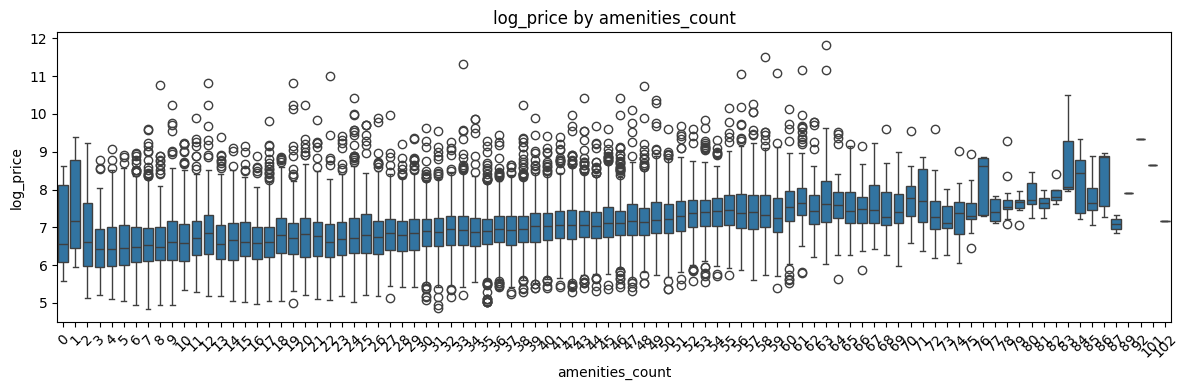

In [133]:
# Compute median log_price and count of listings grouped by amenities_count
print("=========== Median log_price and count by amenities_count ==============\n")
print(df_features.groupby("amenities_count")["log_price"].agg(
    median="median",
    count="count"
))

# Plot boxplot to visualize distribution of log_price by amenities_count
print("\n=========== Boxplot of log_price by amenities_count ==============")
plot_boxplot(
    df=df_features,
    vars=['amenities_count'],
    target='log_price'
)


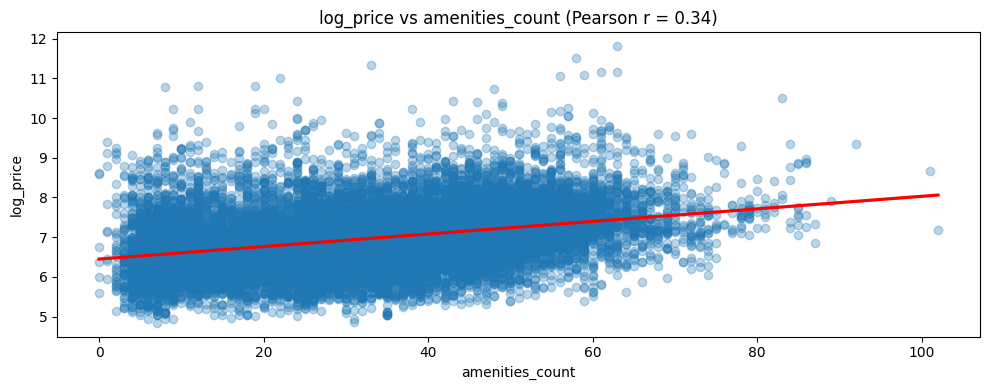

In [134]:
# Plot regplot to visualize relationship between log_price and amenities_count
plot_regplot(
    df=df_features,
    vars=['amenities_count'],
    target= 'log_price',
    figsize_width=10
)

El análisis conjunto de la mediana de `log_price` y la frecuencia de `amenities_count` revela un patrón relevante pero no completamente lineal. En los valores bajos de `amenities_count` (0–3), se observa muy baja frecuencia de observaciones y alta variabilidad en la mediana del precio, esto indica que estos valores pertenecen a una zona poco representativa, donde las estimaciones son inestables y poco confiables.

A partir de aproximadamente 4–5 amenities, la frecuencia aumenta significativamente y la relación comienza a estabilizarse. En este rango la mediana muestra una tendencia creciente general y la relación, aunque no perfectamente monótona, se vuelve más consistente. En rangos medios (20–50 amenities), donde se concentra la mayor densidad de datos, la mediana aumenta de forma progresiva y la variabilidad se reduce en comparación con los extremos bajos

En valores altos (>60 amenities) la frecuencia vuelve a disminuir considerablemente. Aparecen valores atípicos con medianas elevadas, producto de muy pocas observaciones y la relación pierde estabilidad y se vuelve susceptible a ruido.

**Correlación entre `amenities_count` y `log_price`**

El coeficiente de correlación de Pearson entre `amenities_count` y `log_price` es 0.33, lo cual indica una **relación positiva moderada. Esto implica que existe una tendencia clara: a mayor número de amenities, mayor precio. Sin embargo, la variable no explica por sí sola la variabilidad del precio, la relación está influenciada por otros factores (tipo de propiedad, capacidad, ubicación, etc.)

La variable `amenities_count` actúa como un proxy del nivel de equipamiento del listing. En términos generales:

- Listings con más amenities tienden a ofrecer una mejor experiencia o mayor nivel de confort
- Esto se refleja en precios más altos, aunque con rendimientos decrecientes a medida que aumenta el número de amenities

Dado el comportamiento observado, se consideraran las siguientes transformaciones:

- *Capping superior*

Se aplicará un capping en valores altos de amenities_count debido a:  
→ Baja frecuencia en los extremos superiores.  
→ Alta variabilidad en la mediana del precio.  
→ Evidencia de rendimientos decrecientes, donde amenities adicionales aportan cada vez menos información.  

- *Posible binning / agrupamiento*  

Se considera la creación de una variable adicional agrupada debido a:  
→ La existencia de una zona inicial inestable (0–3 amenities).  
→ La presencia de una relación no estrictamente lineal.  
→ La necesidad de capturar niveles de equipamiento (bajo, medio, alto) de forma más robusta.  

- *Posible categorización por tipo de amenidades*  

Además del conteo total, se considera la posibilidad de crear variables categóricas basadas en la presencia de amenidades específicas de alto valor (por ejemplo: jacuzzi, alberca, gimnasio, estacionamiento, etc.). Esto permitiría identificar listings con características tipo “premium”, que no necesariamente se capturan únicamente con el número total de amenidades. Este enfoque podría ser relevante porque:  

→ No todas las amenidades tienen el mismo impacto en el precio.  
→ Algunas amenidades específicas pueden tener un efecto desproporcionado sobre el valor del listing.  
→ Permite enriquecer la representación del nivel de calidad más allá del simple conteo.

#### Capping en `amenities_count`

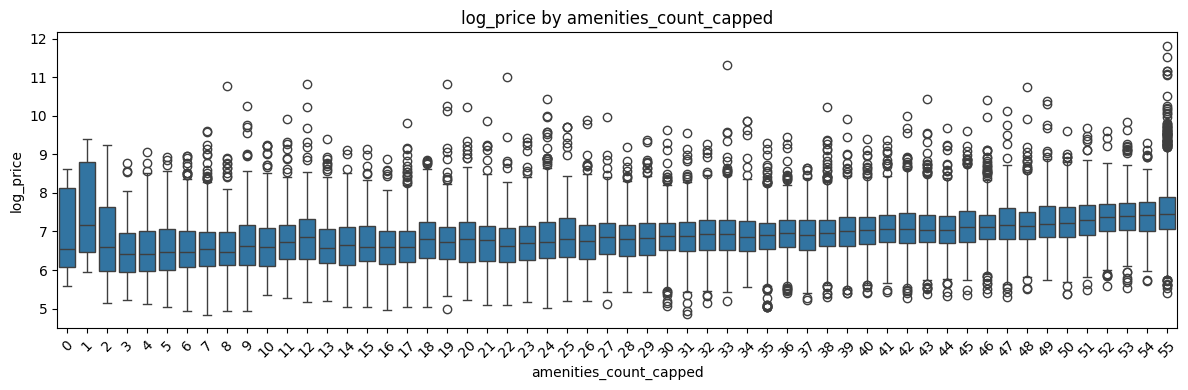

In [135]:
# Cap values for room capacity variables
df_features['amenities_count_capped'] = df_features['amenities_count'].clip(upper=55)

# Plot boxplot to visualize distribution of log_price by amenities_count (capped)
plot_boxplot(
    df=df_features,
    vars= ['amenities_count_capped'],
    target= 'log_price'
    )

Tras aplicar el capping en 55, la distribución de `amenities_count_capped` muestra una mejora clara en términos de estabilidad sin perder la tendencia general de la variable.Se mantiene una tendencia creciente general en la mediana de `log_price` conforme aumenta el número de amenities:

- En rangos bajos (0–10), la relación sigue siendo algo irregular, principalmente por la baja frecuencia de estas observaciones.
- A partir de ~20 amenities, la relación se vuelve más *consistente y progresiva*.
- En rangos altos (40–60), la mediana continúa aumentando de forma relativamente estable.
- Se redujo la varianza en los extremos y se mantuvo la relación positiva con el precio.

En términos prácticos, realizar esto implica asumir que a partir de cierto punto, tener más amenities adicionales no aporta información significativamente distinta para explicar el precio.

#### Binning en `amenities_count`

============== Distribution of amenities_count_binned (%) ===================
amenities_count_binned
medium    0.565972
high      0.333736
low       0.100292
Name: proportion, dtype: float64

============ Median log_price by amenities_count_binned ============
amenities_count_binned
high      7.221105
medium    6.845880
low       6.507278
Name: log_price, dtype: float64

========== Boxplot of log_price by amenities_count_binned ==========


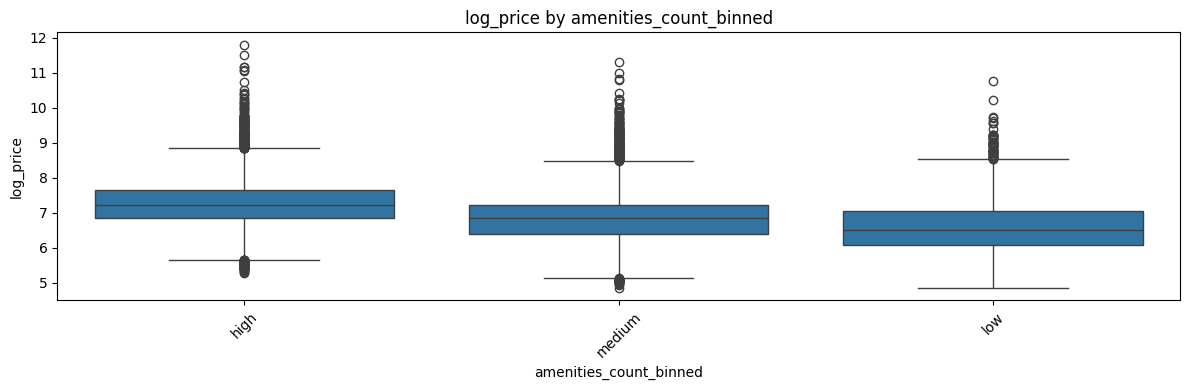

In [136]:
# Create binned categories for amenities_count (low, medium, high)
df_features['amenities_count_binned'] = pd.cut(
    df_features['amenities_count'],
    bins=[-1, 10, 40, np.inf],
    labels=["low", "medium", "high"]
)

# Print distribution (%) of listings across amenities_count_binned categories
print("============== Distribution of amenities_count_binned (%) ===================")
print(df_features['amenities_count_binned'].value_counts(normalize=True))

# Print median log_price by amenities_count_binned category
print("\n============ Median log_price by amenities_count_binned ============")
print(df_features.groupby('amenities_count_binned', observed=False)['log_price'].median().sort_values(ascending=False))

# Plot boxplot to visualize log_price distribution by amenities_count_binned
print("\n========== Boxplot of log_price by amenities_count_binned ==========")
plot_boxplot(
    df=df_features,
    vars=['amenities_count_binned'],
    target='log_price'
)


La variable `amenities_count` fue transformada mediante binning en tres niveles, logrando una distribución balanceada:

- *Medium*: ~56.6%
- *High*: ~33.4%
- *Low*: ~10.0%

Esta segmentación permite representar de forma más estable los distintos niveles de equipamiento de los listings.

En relación con el precio, se observa un comportamiento consistente:

- *Low* → menor cantidad de amenidades → menor nivel de precio (≈ 6.50)
- *Medium* → nivel intermedio (≈ 6.84)
- *High* → mayor cantidad de amenidades → mayor nivel de precio (≈ 7.22)

Esto confirma una relación positiva entre el nivel de amenidades y el precio del alojamiento, donde propiedades mejor equipadas tienden a presentar precios más altos. El binning facilitará la interpretación al agrupar los listings en niveles de equipamiento del alojamiento, lo cual puede ser útil para el modelado, dado que la variable `amenities_count_capped` también conserva información relevante en su forma continua, ambas representaciones podrían considerarse en etapas posteriores.

#### Transformación y evaluación de amenidades

##### Descomposición y normalización de `amenities`

A continuación, se procederá a descomponer y normalizar la información contenida en la variable `amenities`, con el objetivo de analizar cada amenidad de forma individual y evaluar su frecuencia en el dataset.

In [137]:
# Explode amenities_list so each amenity becomes a separate row
all_amenities = df_features['amenities_list'].explode()

# Basic normalization of amenity strings
all_amenities = all_amenities.str.strip()            # remove leading/trailing spaces
all_amenities = all_amenities.str.lower()            # convert to lowercase
all_amenities = all_amenities.str.replace("-", " ")  # replace hyphens with spaces

# Compute frequency of amenities (sorted descending)
freq_amenities = all_amenities.value_counts().sort_values(ascending=False)

# Display the top 250 most frequent amenities
freq_amenities.head(250)


amenities_list
wifi                                                               18831
kitchen                                                            18648
hot water                                                          18018
hangers                                                            16399
cooking basics                                                     16180
                                                                   ...  
mabe oven                                                             82
sauna                                                                 81
private backyard – not fully fenced                                   79
paid washer                                                           79
clothing storage: walk in closet, closet, wardrobe, and dresser       78
Name: count, Length: 250, dtype: int64

A partir de este proceso, se identificó que existe un conjunto de amenidades altamente frecuentes (wifi, kitchen, hot water, essentials, entre otros), presentes en la gran mayoría de los listings. También se observan amenidades de frecuencia media y baja que podrían capturar diferencias relevantes en términos de confort, nivel del alojamiento y tipo de experiencia ofrecida (refrigerador, tv, pool, elevator, free parking, entre otras ).

Dado que esta variable presenta alta cardinalidad y múltiples variaciones semánticas, no resulta eficiente ni robusto utilizar todas las amenidades de forma directa. Por lo cual se adoptará un enfoque estructurado basado en:

- Selección de amenidades relevantes, considerando frecuencia, interpretabilidad y potencial relación con el precio.
- Agrupación conceptual amenidades, organizandolas en grupos como: Basics, Convenience, Comfort, Entertainment, Outdoor.
- Transformación a varaibles binarias (*has_amenity*), que permitirán capturar la presencia o ausencia de amenidades relevantes especificas en cada listing.
- Construcción de un score de amenidades, diseñado para resumir el nivel de equipamiento de cada propiedad de manera compacta e interpretable.


Este enfoque permitirá transformar una variable compleja y no estructurada en un conjunto de features interpretables y comparables, lo que facilitará tanto el análisis exploratorio como la incorporación de las amenidades en nuestro modelo predictivo.

##### Selección y agrupación de amenidades relevantes

In [138]:
selected_amenities = [

    # Essentials / Basics
    'wifi',
    'kitchen',
    'hot water',
    'essentials',
    'bed linens',              
    'microwave',               
    'refrigerator',
    'air conditioning',
    'ac   split type ductless system',
    'heating',
    'cooking basics',
    'dishes and silverware',
    
    # Comfort & Funcionality
    'washer',
    'iron',
    'hair dryer',
    'dedicated workspace',
    'dining table',
    'dishwasher',
    'freezer',
    'coffee maker',
    'blender',

    # Convenience / Access
    'self check-in',
    'private entrance',
    'elevator',
    'free parking',
    'pets allowed',
    'cleaning available during stay',

    # Entertaiment
    'tv',
    'netflix',
    'hbo max',
    'prime video',
    'disney+',
    'apple tv',
    'hulu',
    'pool table',
    'piano',
    'game console',
    'ping pong table',

    # Outdoor / Experience
    'patio or balcony',
    'backyard',
    'pool',
    'sauna',
    'city skyline view',
    'outdoor furniture',
    'outdoor dining area',    

    # Safety
    'smoke alarm',
    'carbon monoxide alarm',
    'fire extinguisher',
    'exterior security cameras on property',
    'first aid kit '
    
]

Tras el proceso de selección y depuración, las amenidades se organizaron en grupos conceptuales que facilitarán su interpretación y uso en el modelo:

- *Essentials / Basics:* características fundamentales que aseguran funcionalidad mínima y comodidad básica en el alojamiento.

- *Comfort & Functionality:* elementos que mejoran la practicidad y el confort cotidiano del huésped.

- *Convenience / Access:* facilidades relacionadas con accesibilidad, entrada y servicios adicionales que simplifican la experiencia.

- *Entertainment:* amenidades orientadas al ocio y entretenimiento dentro del alojamiento.

- *Outdoor / Experience:* atributos que enriquecen la experiencia al aire libre y el atractivo del entorno.

- *Safety:* equipamiento de seguridad y prevención que aporta confianza y protección al huésped.

Una vez seleccionadas y agrupadas las amenidades, se procederá con la creación de las columnas binarias (*has_amenity*) que indicarán la presencia o ausencia de cada amenidad relevante en los listings.

##### Transformación de `amenities` en variables binarias `has_amenities`

In [139]:
# 1. Clean and normalize amenities_list (lowercase, remove special characters, strip spaces)
df_features["amenities_list_clean"] = df_features["amenities_list"].apply(
    lambda lst: [re.sub(r'[^a-z0-9\s+\-]', '', a.lower()).strip() for a in lst]
)

# 2. Convert each amenities list into a set (to remove duplicates and allow fast membership checks)
df_features["amenities_set"] = df_features["amenities_list_clean"].apply(set)


# ======== Special features ========

# 3. Create binary feature for Washer (excluding dishwasher)
df_features["has_washer"] = df_features["amenities_set"].apply(
    lambda s: any(("washer" in a and "dishwasher" not in a) for a in s)
)

# 4. Create binary feature for Pool (excluding pool table and whirlpool variants)
df_features["has_pool"] = df_features["amenities_set"].apply(
    lambda s: any(
        ("pool" in a) and not any(e in a for e in ['pool table','whirlpool','wirpool','whirpool'])
        for a in s
    )
)

# 5. Create binary feature for Streaming platforms (Netflix, HBO, Prime Video, Disney+, Apple TV, Hulu)
streaming_keywords = ['netflix','hbo','prime video','disney+','apple tv','hulu']

df_features["has_streaming_platform"] = df_features["amenities_set"].apply(
    lambda s: any(any(k in a for k in streaming_keywords) for a in s)
)


# ======== Other common amenities ==========

# 6. Define a list of common amenities
simple_amenities = [
    'wifi','kitchen','hot water','essentials','bed linens','microwave',
    'refrigerator','air conditioning','heating','cooking basics','dishes and silverware','iron',
    'hair dryer','dedicated workspace','dining table','dishwasher','freezer',
    'coffee maker','blender','self check-in','private entrance','elevator',
    'free parking','pets allowed','cleaning available during stay','tv','pool table',
    'piano','game console','ping pong table','patio or balcony','backyard',
    'sauna','city skyline view','outdoor furniture','outdoor dining area',
    'smoke alarm','carbon monoxide alarm','fire extinguisher',
    'exterior security cameras on property','first aid kit'
]

# 7. Create binary features for each amenity in simple_amenities list
for amenity in simple_amenities:
    col = "has_" + amenity.replace(" ", "_").replace("+", "plus").replace("-","_")
    
    df_features[col] = df_features["amenities_set"].apply(
        lambda s: any(amenity in a for a in s)
    )


In [140]:
# Collect all binary amenity features (columns starting with 'has_')
has_amenities = [col for col in df_features.columns if col.startswith("has_")]

# Compute mean occurrence rate of each amenity (proportion of listings with the amenity)
df_features[has_amenities].mean().sort_values(ascending=False)


has_wifi                                     0.990486
has_kitchen                                  0.892189
has_tv                                       0.860491
has_hot_water                                0.843923
has_cooking_basics                           0.750917
has_dishes_and_silverware                    0.743305
has_iron                                     0.742331
has_essentials                               0.717269
has_dedicated_workspace                      0.702093
has_bed_linens                               0.698566
has_refrigerator                             0.694018
has_coffee_maker                             0.681580
has_microwave                                0.677681
has_carbon_monoxide_alarm                    0.657679
has_hair_dryer                               0.635587
has_self_check_in                            0.587924
has_smoke_alarm                              0.578364
has_washer                                   0.573119
has_dining_table            

Tras la creación de las columnas binarias (*has_amenity*), se observa que existen amenidades altamente frecuentes en el dataset, como *has_wifi* (99%), *has_kitchen* (89%), *has_tv* (86%) y *has_hot_water* (84%). Estas variables, al estar presentes en casi todos los listings, aportan poca variabilidad y por lo tanto podrían tener un impacto limitado en la diferenciación de precios.

En contraste, también se observan amenidades de frecuencia media (30–70%) como *has_washer*, *has_hair_dryer*, *has_coffee_maker*, *has_elevator* y *has_free_parking*. Y amenidades poco frecuentes (<10%) como *has_pool*, *has_sauna*, *has_dishwasher* o *has_ping_pong_table*, aunque su presencia es rara, estas amenidades podrían estar asociadas con un mayor nivel de lujo o alojamientos diferenciados, lo que podría reflejarse en precios más altos.

Finalmente, aparecen amenidades poco frecuentes (<10%) como `has_pool`, `has_sauna`, `has_dishwasher`, `has_ping_pong_table` o `has_piano`. Aunque su presencia es rara, tienden a estar asociadas con un mayor nivel de lujo o experiencias diferenciadas, lo que puede reflejarse en precios más altos.

A partir de este análisis podríamos destacar 3 grupos de amenidades:  

- *Amenidades universales:* (wifi, kitchen, TV) → útiles como control, pero podrían tener un escaso poder explicativo.  
- *Amenidades intermedias:* (washer, hair dryer, elevator, free parking) → Podrían aportar variabilidad y una relación mas consistente con el precio.  
- *Amenidades raras:* (pool, sauna, piano) → aunque poco frecuentes, podrían ser indicadores de propiedades premium y conviene analizarlas con cuidado para evitar sobreajuste (que el modelo se ajuste demasiado a estos casos especificos en lugar de generalizar)

##### Evaluación de las variables `has_amenities`

Con el fin de evaluar la relevancia de estas amenidades en el dataset, se analizarán distintos aspectos de cada amenidad, enparticular, se calcularán

- *Proporción de listings*, que cuentan con cada amenidad.  
- *Medianas del precio*, para listings con y sin la amenidad.  
- *Diferencia en medianas*, como medida del impacto típico asociado a la presencia de la amenidad.  
- *Correlación (r)*, entre cada amenidad y el precio, para identificar relaciones consistentes.  




In [141]:
# 1. Collect all amenity columns that start with "has_"
has_amenities = [col for col in df_features.columns if col.startswith("has_")]

# 2. Initialize a list to store results
results = []

# 3. Loop through each amenity column
for col in has_amenities:
    # Proportion of listings that have the amenity
    proportion = df_features[col].mean()
    
    # Mean log_price for listings with and without the amenity
    median_true = df_features.loc[df_features[col], "log_price"].median()
    median_false = df_features.loc[~df_features[col], "log_price"].median()
    
    # Difference in means (impact of having the amenity)
    median_diff = median_true - median_false
    
    # Correlation between amenity (binary) and log_price
    corr = df_features[col].corr(df_features["log_price"])
    
    # Append results as a dictionary
    results.append({
        "feature": col,
        "proportion": proportion,
        "median_true": median_true,
        "median_false": median_false,
        "median_diff": median_diff,
        "correlation_r": corr
    })

# 4. Convert results into a DataFrame
impact_has_amenities= pd.DataFrame(results).set_index("feature")

# 6. Display the final table
impact_has_amenities.sort_values(by="proportion", ascending=False)


,proportion,median_true,median_false,median_diff,correlation_r
feature,,,,,
has_wifi,0.990486,6.956545,6.866933,0.089612,-0.000722
has_kitchen,0.892189,6.984716,6.666957,0.317760,0.085161
has_tv,0.860491,7.025538,6.320768,0.704770,0.284825
has_hot_water,0.843923,6.987490,6.711740,0.275750,0.096524
has_cooking_basics,0.750917,7.013466,6.709304,0.304161,0.137028
has_dishes_and_silverware,0.743305,7.005789,6.745236,0.260553,0.124625
has_iron,0.742331,7.031741,6.666957,0.364784,0.191472
has_essentials,0.717269,7.013915,6.762730,0.251186,0.140048
has_dedicated_workspace,0.702093,6.991637,6.882437,0.109199,0.071495


El análisis conjunto de proporción (`proportion`), diferencia de medianas (`median_diff`) y correlación (`correlation_r`) se realizó para entender no solo qué amenidades están asociadas a precios más altos, sino también qué tan consistente y representativa es dicha relación dentro del dataset.

En términos generales, se observa una relación positiva entre la presencia de algunas amenidades y el precio, lo cual sugiere que este conjunto de variables está capturando una dimensión subyacente importante: el nivel o calidad general del listing. Sin embargo, esta señal no es homogénea.

Por un lado, destacan amenidades con un comportamiento sólido:

- Presentan diferencias de mediana altas y correlaciones moderadas
- Tienen una proporción razonable dentro del dataset

Ejemplos como *TV, hair dryer, elevator, free parking o coffee maker* muestran que no solo están asociadas a precios más altos, sino que además lo hacen de manera consistente. Esto sugiere que podrian ser buenos indicadores del nivel del alojamiento y que aportarían señal útil para el modelo, ya que combinan impacto y estabilidad.

Por otro lado, existen amenidades con un patrón distinto:

- Alta diferencia de mediana
- Baja correlación
- Baja proporción

Estas amenidades con diferencias de mediana elevadas pero baja correlación, como *dishwasher, pool o sauna*, están claramente asociadas a listings más caros, pero su baja frecuencia y alta variabilidad hacen que su relación con el precio sea menos estable. En la práctica, esto indica que capturan casos específicos (probablemente segmentos premium o de lujo), pero no generalizan bien a todo el conjunto de datos.

También se identifican amenidades con presencia casi universal como *wifi, kitchen, essentials, hot water*. Aunque muestran diferencias positivas, su alta proporción (≈80–99%) implica que no discriminan eficazmente entre listings. En la práctica, estas amenidades representan condiciones o equipamiento mínimo esperado más que factores diferenciadores.

En el extremo opuesto, aparecen amenidades con:

- Bajo impacto
- Correlación casi nula o negativa

Como *piano o game console*, aunque en principio podrían interpretarse como características adicionales, su comportamiento sugiere que están asociadas a tipos específicos de listings o segmentos de mercado que no necesariamente corresponden a precios más altos. Este tipo de amenidades podrían aportar valor para segmentación, pero no como indicadores directos de precio.

Un aspecto clave es que muchas de estas amenidades no actúan de forma independiente, sino que podrían estar altamente correlacionadas entre sí. Estas múltiples variables podrían estar capturando una misma dimensión latente, el nivel socioeconómico o de confort del listing. Esto implica que incluir todas las variables directamente en el modelo podría introducir redundancia y multicolinealidad, afectando su estabilidad y capacidad de generalización.

Por ello, más que centrarse en el efecto individual de cada amenidad, el enfoque adecuado consistiría en sintetizar esta información. Esto puede lograrse mediante la selección de un subconjunto representativo de estas variables o de forma más robusta, mediante la construcción de variables agregadas como un *amenities score* o una estragia de ponderación, que capturen de manera más eficiente la señal global presente en este conjunto de features.


##### Score de amenidades

Con el objetivo de reducir la complejidad derivada del uso de múltiples variables binarias (*has_amenity*) y capturar de forma más eficiente la información contenida en ellas, se construirá una variable agregada denominada `amenities_score`.

Este score buscará representar el *nivel general del listing en términos de amenidades*, integrando en una sola métrica la señal que actualmente se encuentra distribuida entre múltiples features altamente correlacionadas.

**Enfoque general y seleccion de amenidades**

En lugar de realizar una suma simple de amenidades, se utilizará un enfoque ponderado, donde cada variable contribuye en función de su relación con el precio. Para ello, se asignará un peso a cada amenidad considerando:

- La diferencia en la mediana del precio entre listings que la incluyen y los que no (median_diff)
- La consistencia de dicha relación (correlation_r)

De esta forma, el `amenities_score` se construirá como una suma ponderada de las variables seleccionadas, priorizando aquellas con mayor capacidad explicativa.

Es importante destacar que no todas las variables *has_amenity* serán incluidas en el cálculo del score. 

Esto se debe a varias razones:

- Algunas amenidades presentan *alta frecuencia* (e.g., wifi, kitchen), por lo que no discriminan entre listings
- Otras muestran *bajo impacto o relación inconsistente* con el precio
- Existe *alta correlación entre múltiples amenidades*, lo que implica redundancia en la información

Incluir todas las variables en el score introduciría ruido y reduciría su capacidad para capturar señal relevante. Por ello, se seleccionará un subconjunto de amenidades que aporten información significativa, sean relativamente estables en su relación con el precio y no estén completamente redundadas por otras variables.

Adicionalmente, algunas amenidades no serán incluidas en el score, pero sí se mantendrán como variables individuales dentro del dataset.

Esto ocurre en casos donde:

- La amenidad representa una *característica distintiva o específica* (e.g., pool, free parking)
- Su efecto puede no ser completamente capturado por un score agregado
- Puede aportar valor adicional al modelo como feature independiente

Este esquema permitirá separar dos tipos de información:

- *Señal global* → capturada por amenities_score
- *Señal específica* → capturada por un conjunto reducido de variables has_amenity

De esta manera, se esperar lograr un balance entre reducción de dimensionalidad, interpretabilidad y capacidad explicativa.

**Calculo de amenities score**

============ Distribution of normalized amenities score =================
       amenities_score_norm
count          21547.000000
mean               0.500136
std                0.207397
min                0.000000
25%                0.353700
50%                0.534108
75%                0.658599
max                1.000000

=========== Distribution of amenities score norm ===========


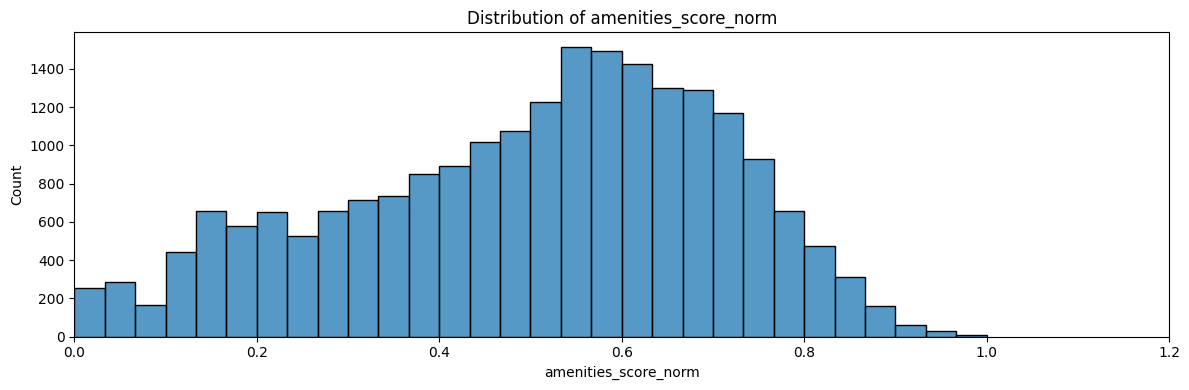

In [142]:
# ========== Amenities Score ===============

# 1. Select amenities to be included in the score (based on EDA)

# Define thresholds
min_prop = 0.03   # exclude amenities too rare
max_prop = 0.95   # exclude amenities too common
min_diff = 0.20   # minimum median price difference
min_corr = 0.08   # minimum correlation with price

# Apply filters
selected_amenities = impact_has_amenities[
    (impact_has_amenities['proportion'] >= min_prop) &
    (impact_has_amenities['proportion'] <= max_prop) &
    (impact_has_amenities['median_diff'] >= min_diff) &
    (impact_has_amenities['correlation_r'] >= min_corr)
]

# Final list of selected amenities
selected_has_amenities = selected_amenities.index.tolist()


# 2. Create weights dictionary for selected amenities
# Weight = median_diff * correlation_r

weights = (
    impact_has_amenities
    .loc[selected_has_amenities, ["median_diff", "correlation_r"]]
    .prod(axis=1)   # multiply the two columns
    .to_dict()      # convert to dictionary {amenity: weight}
)

# 4. Initialize amenities score
df_features["amenities_score"] = 0

# 4. Calculate weighted score for each listing
for col in selected_has_amenities:
    df_features["amenities_score"] += df_features[col] * weights[col]

# 5. Apply Min-Max normalization
min_score = df_features["amenities_score"].min()
max_score = df_features["amenities_score"].max()

df_features["amenities_score_norm"] = (
    df_features["amenities_score"] - min_score
) / (max_score - min_score)

# 6. Quick review of score distribution
print("============ Distribution of normalized amenities score =================")
print(df_features[["amenities_score_norm"]].describe())

# Plot histogram to visualize the distribution of amenities score norm
print("\n=========== Distribution of amenities score norm ===========")
plot_histogram(
    df=df_features,
    vars=['amenities_score_norm'],
    bins=30
)



La distribución de `amenities_score_norm` muestra una media cercana a 0.53 y una desviación estándar moderada (~0.20). La mayoría de los listings se concentran entre 0.35 y 0.65, mientras que los valores extremos (0 y 1) son menos frecuentes. El histograma refleja una forma aproximadamente simétrica y de campana, con mayor frecuencia alrededor de 0.6. Esto indica que la mayoría de las propiedades tienen un puntaje de amenities en un rango medio, y que los casos con muy pocos o muchísimos amenities ponderados son menos comunes.

##### Evaluación de `amenities_score`

=========== Regression Plot: log_price vs amenities_score_norm ============
 


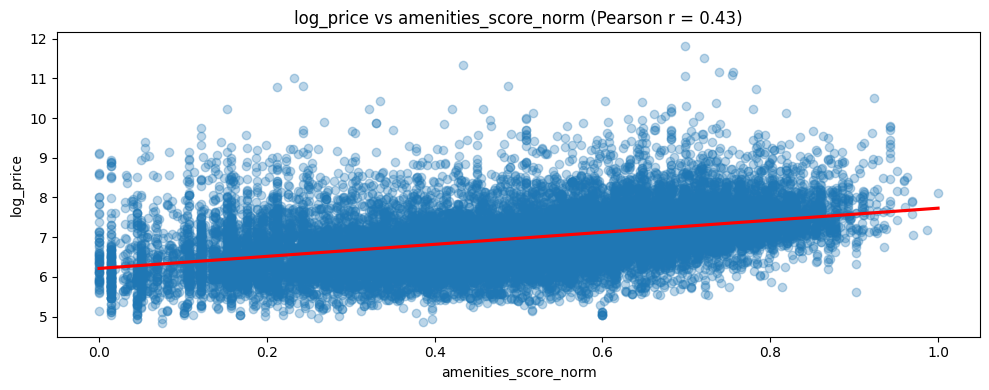

In [143]:
# Plot regplot to visualize relationship between log_price and amenities_score_norm
print("=========== Regression Plot: log_price vs amenities_score_norm ============")
print(" ")
plot_regplot(
    df=df_features,
    vars=['amenities_score_norm'],
    target='log_price',
    figsize_width=10
)


**Correlación con log_price**

La variable `amenities_score_norm` muestra una correlación positiva moderada con `log_price` (0.43). Esto implica que, en general, a medida que aumenta el score de amenidades, también lo hace el precio del listing.  La relación no es perfecta, pero sí consistente: el score logra capturar parte importante de la variación en los precios, reflejando que los amenities ponderados influyen en el valor de las propiedades. 

**Discretización de `amenities_score_norm`**

Para analizar el comportamiento de esta variable, será discretizada en 5 bins con el objetivo de:

- Evaluar si la relación con el target es *monotónica*
- Analizar la *capacidad de separación* entre distintos niveles del score
- Facilitar la interpretación del comportamiento de la variable

=========== Median log_price by amenities score bins ===========

amenities_score_norm_binned
(-0.001, 0.304]    6.451260
(0.304, 0.472]     6.659294
(0.472, 0.582]     6.911747
(0.582, 0.685]     7.098376
(0.685, 1.0]       7.402452
Name: log_price, dtype: float64

=========== Boxplot of log_price by amenities score bins ===========



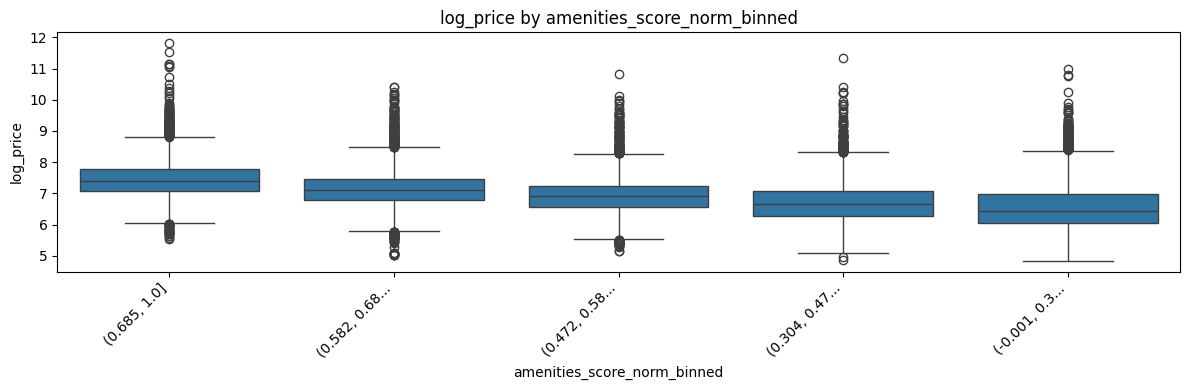

In [144]:
# Create quantile-based bins for amenities_score_norm (divide into 5 groups)
df_features["amenities_score_norm_binned"] = pd.qcut(df_features["amenities_score_norm"], q=5)

# Compute median log_price per bin to compare differences across groups
print("=========== Median log_price by amenities score bins ===========\n")
print(df_features.groupby("amenities_score_norm_binned")["log_price"].median())

# Plot boxplot to visualize log_price distribution by amenities_score_norm_binned
print("\n=========== Boxplot of log_price by amenities score bins ===========\n")
plot_boxplot(
    df=df_features,
    vars=['amenities_score_norm_binned'],
    target='log_price'
)

Se observa una tendencia creciente clara y sostenida en la mediana de `log_price` a medida que aumenta el score:

- La relación es *monotónica*, sin inversiones o comportamientos erráticos
- Existe una *separación progresiva entre bins*, lo que indica buena capacidad discriminativa
- El boxplot construido muestra cómo la distribución de precios se desplaza hacia arriba conforme aumenta el score.

La variable generada `amenities_score_norm` no solo está correlacionada con el precio, sino que también segmenta de manera efectiva los listings en grupos con diferencias claras en el precio. Dado esto, la variable parece capturar de forma efectiva una dimensión relevante del problema.

Como siguiente paso, se comparará directamente con `amenities_count` para evaluar redundancia, ganancia de señal e impacto en modelado.

##### Comparación entre `amenities_count` y `amenities_score`

La comparación entre ambas variables permitirá evaluar si `amenities_score_norm` realmente aporta valor adicional o simplemente reexpresa la misma información contenida en el conteo de amenidades (`amenities_count`)

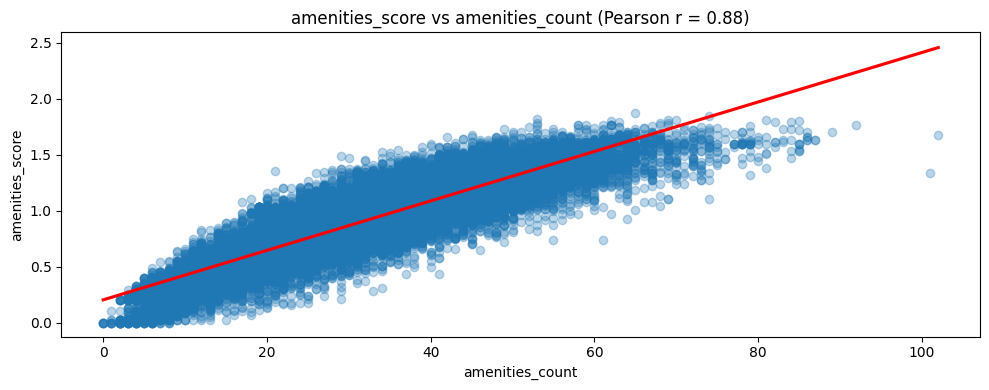

In [145]:
# Evaluate the linear relationship between amenities_count and amenities_score_norm
plot_regplot(
    df=df_features,
    vars=['amenities_count'],
    target='amenities_score'
)

La correlación entre ``amenities_count`` y `amenities_score_norm` es de 0.88, lo que indica una relación lineal muy fuerte, propiedades con más amenidades tienden a tener un score más alto. Esto implica que ambas variables están capturando esencialmente la misma dimensión del problema, es decir, el nivel general del listing en función de sus amenidades. 

En términos prácticos, existe una alta redundancia entre ambas representaciones, sin embargo, no son idénticos: el score introduce ponderaciones que diferencian la importancia relativa de cada amenidad, mientras que el conteo las trata todas por igual.

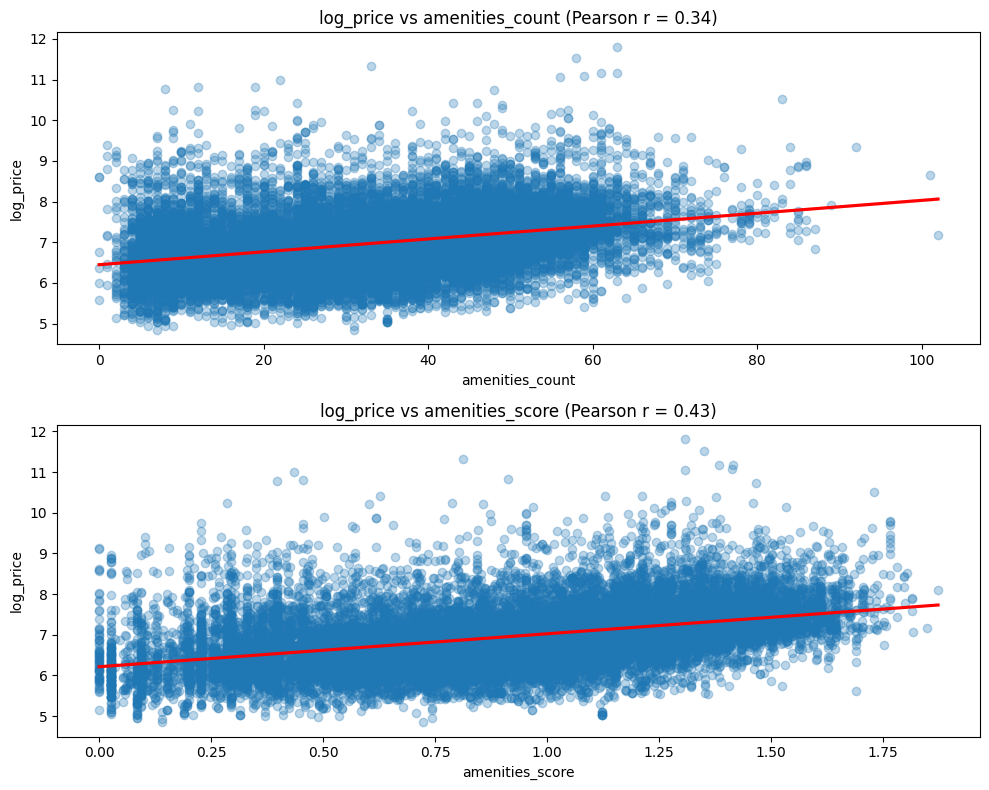

In [146]:
# Plot regplot to visualize relationship between amenities_count / amenities_score_norm and log_price
plot_regplot(
    df=df_features,
    vars=['amenities_count', 'amenities_score'],
    target='log_price'
)

A pesar de la alta correlación entre ambas variables, su relación con `log_price` presenta diferencias relevantes:

- `amenities_count`: r ≈ 0.34  
- `amenities_score_norm`: r ≈ 0.43  

Esto sugiere que `amenities_score_norm` refina la señal existente y tiene mayor poder explicativo respecto a la variación en el precio, sugiriendo que las amenidades ponderadas ofrecen una representación más significativa del precio de la propiedad. Además que reduce parcialmente el ruido presente en un conteo simple.

En otras palabras, mientras que `amenities_count` mide cantidad, el score aproxima una noción de *calidad o valor relativo* de las amenidades.


========= Median log_price by Amenities Count Bins =========
amenities_count_binned
low       6.507278
medium    6.845880
high      7.221105
Name: log_price, dtype: float64

============ Median log_price by Amenities Score Bins ============
amenities_score_norm_binned
(-0.001, 0.304]    6.451260
(0.304, 0.472]     6.659294
(0.472, 0.582]     6.911747
(0.582, 0.685]     7.098376
(0.685, 1.0]       7.402452
Name: log_price, dtype: float64

============ Boxplot of log_price by Count vs Score Bins ============


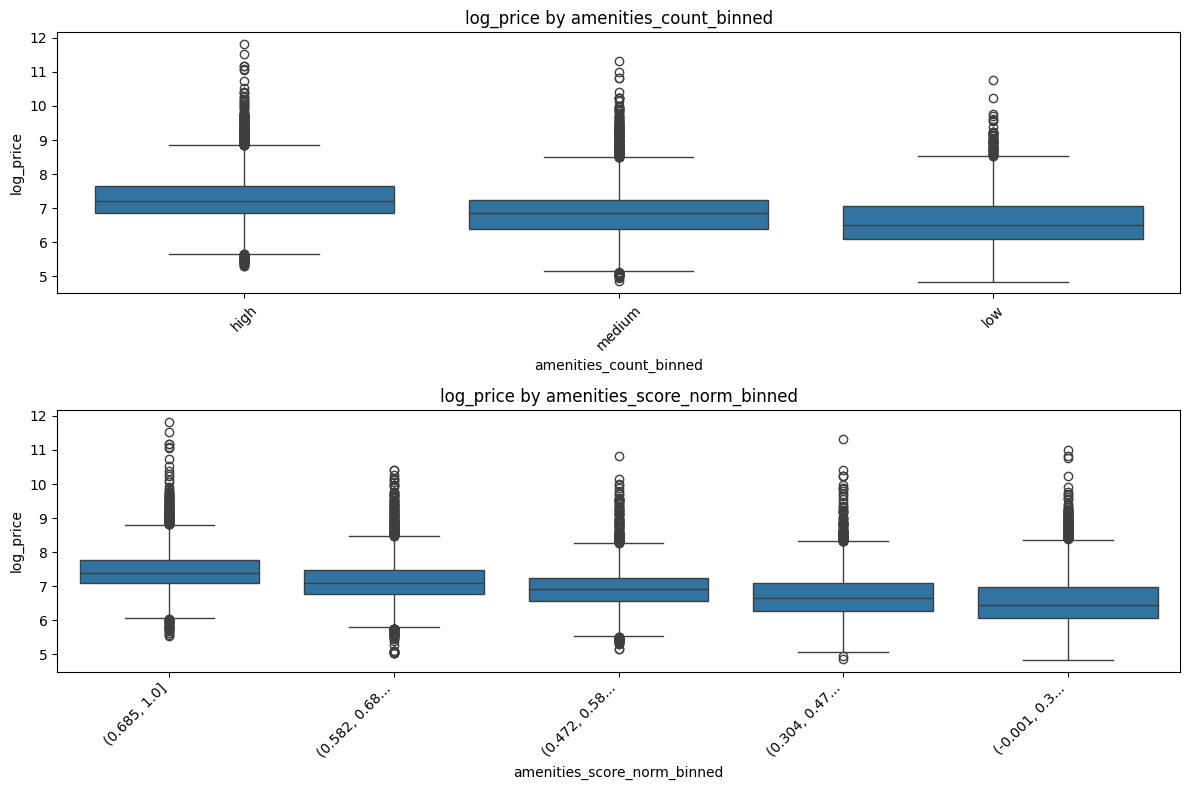

In [147]:
# Compute median log_price by amenities_count bins
print('========= Median log_price by Amenities Count Bins =========')
print(df_features.groupby('amenities_count_binned')['log_price'].median())

# Compute median log_price by amenities_score_norm bins
print("\n============ Median log_price by Amenities Score Bins ============")
print(df_features.groupby("amenities_score_norm_binned")["log_price"].median())

# Compare log_price distribution across bins of amenities_count and amenities_score_norm
print("\n============ Boxplot of log_price by Count vs Score Bins ============")
plot_boxplot(
    df=df_features,
    vars=['amenities_count_binned', 'amenities_score_norm_binned'],
    target='log_price'
)


Al comparar ambas variables mediante binning y su relación con la mediana de `log_price`, se observa que:

- `Amenities_count`: muestran una progresión clara, pero en pasos más gruesos (low ≈ 6.51, medium ≈ 6.85, high ≈ 7.22).
- `Amenities_score_norm`: revelan un incremento más gradual y continuo, desde ≈6.45 hasta ≈7.40, lo que refleja mejor cómo el nivel de equipamiento se relaciona con el precio.

El análisis conjunto sugiere que ambas variables parecen capturar la misma señal base (nivel del listing en función de sus amenidades). Pero `amenities_score_norm` aporta valor adicional porque diferencia amenidades mas relevantes de las menos influyentes, tiene mayor correlación con el precio y permite una segmentación mas granular y progresiva.

Dado el alto grado de redundancia entre ambas variables, se considera que podría no ser necesario incluir ambas en el modelo. La variable `amenities_score_norm` se posiciona como una representación más informativa y optimizada al capturar el impacto diferenciado de las amenidades y mostrar una correlación más fuerte con el precio. La decisión final sobre cuál utilizar deberá validarse en la etapa de modelado, evaluando su impacto real en métricas de desempeño del modelo.

### Características de perfil y comportamiento del anfitrión

Este grupo de variables busca capturar características relacionadas con el perfil, experiencia y comportamiento del anfitrión, las cuales pueden influir indirectamente en la percepción de valor del listing y, por lo tanto, en su precio.

Aunque todas pertenecen al mismo bloque temático, representan dimensiones distintas que deben analizarse por separado:

1. Reputación y confianza del anfitrión: variables que reflejan el nivel de credibilidad y confiabilidad percibida del host.

- `host_is_superhost`
- `host_identity_verified`
- `host_has_profile_pic`
- `host_verifications`

2. Profesionalización del anfitrión: variables que describen la escala de operación del host y su nivel de experiencia en la plataforma.

- `host_listings_count`
- `host_total_listings_count`
- `calculated_host_listings_count`
- `calculated_host_listings_count_entire_homes`
- `calculated_host_listings_count_private_rooms`
- `calculated_host_listings_count_shared_rooms`

3. Comportamiento operativo y fricción en la reserva: variables relacionadas con la interacción del host con los usuarios y la facilidad del proceso de reserva.

- `host_response_time`
- `host_response_rate`
- `host_acceptance_rate`
- `instant_bookable`

Cada uno de estos grupos será evaluado para determinar su relevancia, nivel de señal y posible contribución al modelo.

In [148]:
# Define hostfeatures in variable 'host_features'
host_features = [
     "host_response_time", "host_response_rate", "host_acceptance_rate",
    "host_listings_count", "host_is_superhost", "host_identity_verified",
    "host_has_profile_pic", "host_verifications", "host_total_listings_count",
    "calculated_host_listings_count", "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms", "calculated_host_listings_count_shared_rooms",
    "instant_bookable"
]

# ===============  Define host feature groups ==============

# 1. Host reputation features
host_profile_features = [
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "host_verifications"
]

# 2. Host listings features
host_listings_features = [
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms"
]

# 3. Host behavior features
host_behavior_features = [
    "host_response_time",
    "host_response_rate",
    "host_acceptance_rate",
    "instant_bookable"
]

#### Variables sobre el perfil del host

In [149]:
# ======== Binary Features Analysis: Imbalance + Median Difference ========

# List of binary host features to analyze
binary_features = [
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic"
]

target = "log_price"

print(" ======== Binary Features Analysis: Imbalance + Median Difference ========")
for col in binary_features:
    print(f"\n===== Analysis for: {col} =====")

    # 1. Basic distribution (including NaNs)
    print("\nValue Counts (including NaNs):")
    counts = df[col].value_counts(dropna=False)
    print(counts)

    # 2. Proportion of each class (imbalance check)
    print("\nProportion (%):")
    proportions = df[col].value_counts(normalize=True, dropna=False) * 100
    print(proportions.round(2))

    # 3. Median log_price by category
    print("\nMedian log_price by category:")
    median_values = df_features.groupby(col)[target].median()
    print(median_values)

    # 4. Median difference (True vs False)
    try:
        values = median_values.values
        if len(values) == 2:
            median_diff = abs(values[0] - values[1])
            print(f"\nMedian Difference: {median_diff:.4f}")
        else:
            print("\nMedian Difference: Not computed (unexpected number of categories)")
    except:
        print("\nMedian Difference: Error computing")

 ======== Binary Features Analysis: Imbalance + Median Difference ========

===== Analysis for: host_is_superhost =====

Value Counts (including NaNs):
host_is_superhost
f      12775
t       9277
NaN     1515
Name: count, dtype: int64

Proportion (%):
host_is_superhost
f      54.21
t      39.36
NaN     6.43
Name: proportion, dtype: float64

Median log_price by category:
host_is_superhost
f    6.882437
t    7.026427
Name: log_price, dtype: float64

Median Difference: 0.1440

===== Analysis for: host_identity_verified =====

Value Counts (including NaNs):
host_identity_verified
t      23208
f        357
NaN        2
Name: count, dtype: int64

Proportion (%):
host_identity_verified
t      98.48
f       1.51
NaN     0.01
Name: proportion, dtype: float64

Median log_price by category:
host_identity_verified
f    6.937780
t    6.956545
Name: log_price, dtype: float64

Median Difference: 0.0188

===== Analysis for: host_has_profile_pic =====

Value Counts (including NaNs):
host_has_profile_pi

Se evaluaron las variables binarias del perfil del anfitrión en términos de su distribución (desbalance) y su relación con `log_price`, utilizando la mediana por grupo y la diferencia de medianas como indicador de señal.

1. `host_is_superhost`

La variable `host_is_superhost` presenta una distribución relativamente balanceada, con una proporción suficiente de observaciones tanto en hosts que son superhost como en los que no lo son. Al analizar la relación con el precio, se observa que los listings de superhosts tienen una mediana mayor en comparación con los no superhosts, con una diferencia aproximada de 0.14. Esta diferencia, aunque moderada, es consistente y sugiere que la condición de superhost está asociada a listings con mayor precio. Dado que la variable tiene buena variabilidad y una señal interpretable, se podría considerar como una feature relevante dentro del modelo.

2. `host_identity_verified`

En el caso de `host_identity_verified`, la variable presenta un desbalance extremo, donde más del 98% de los hosts están verificados. Esto limita significativamente su capacidad de discriminación. Al evaluar la mediana de `log_price`, la diferencia entre hosts verificados y no verificados es prácticamente inexistente (~0.02), lo que refuerza la idea de que esta variable no aporta información útil para explicar el precio. En la práctica, se comporta como una constante, por lo que no resulta relevante para el modelo.


3. `host_has_profile_pic`

La variable `host_has_profile_pic` también presenta un desbalance importante, con casi la totalidad de los hosts teniendo foto de perfil. Aunque la diferencia en la mediana de `log_price` entre quienes tienen y no tienen foto es relativamente alta (~0.22), este resultado debe interpretarse con cautela. El grupo sin foto es muy pequeño, lo que hace que la estimación sea inestable y susceptible a ruido o valores atípicos. Por esta razón, a pesar de la aparente señal, la variable no se considera robusta ni confiable para su uso en el modelo.

Del conjunto de variables binarias analizadas, únicamente `host_is_superhost` muestra una combinación adecuada de variabilidad, señal y coherencia interpretativa. Las otras variables presentan problemas estructurales, principalmente relacionados con el desbalance extremo o la falta de impacto en el target, por lo que no aportarían valor al modelo.

El siguiente paso en este grupo de variabes relacionadas con el perfil del host será el análisis de `host_verifications`, abordando tanto su representación numérica (`verifications_count`) como posibles agrupaciones de las combinaciones más frecuentes. El objetivo será evaluar si esta variable aporta señal adicional o si resulta redundante dentro del conjunto de features de perfil del host.

In [150]:
# ===== Conversion of host_verifications to list and creation of count variable =====

# Replace NaN with '[]'
df_features['host_verifications'] = df_features['host_verifications'].fillna("[]")

# Convert the 'host_verifications' column (stored as strings that look like lists)
df_features['host_verifications_list'] = df_features['host_verifications'].apply(ast.literal_eval)

# Create a new column 'host_verifications_count' by counting the number of elements in each list of amenities
df_features['host_verifications_count'] = df_features['host_verifications_list'].apply(len)


===== host_verifications_count Analysis =====

Descriptive Statistics of host_verifications_count:
count    21547.000000
mean         2.022184
std          0.467022
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: host_verifications_count, dtype: float64

Value Counts (including NaNs):
host_verifications_count
2    16873
3     2582
1     2080
0       12
Name: count, dtype: int64

Correlation with log_price: 0.0685

Median log_price by verification count bins:
host_verifications_count_binned
(-0.001, 2.0]    6.932448
(2.0, 3.0]       7.104144
Name: log_price, dtype: float64

===== host_verifications_list Analysis =====

Top 10 most frequent combinations:
host_verifications_list
[email, phone]                16759
[email, phone, work_email]     2582
[phone]                        2050
[phone, work_email]             113
[email]                          29
[]                               12
[email, work_email]           

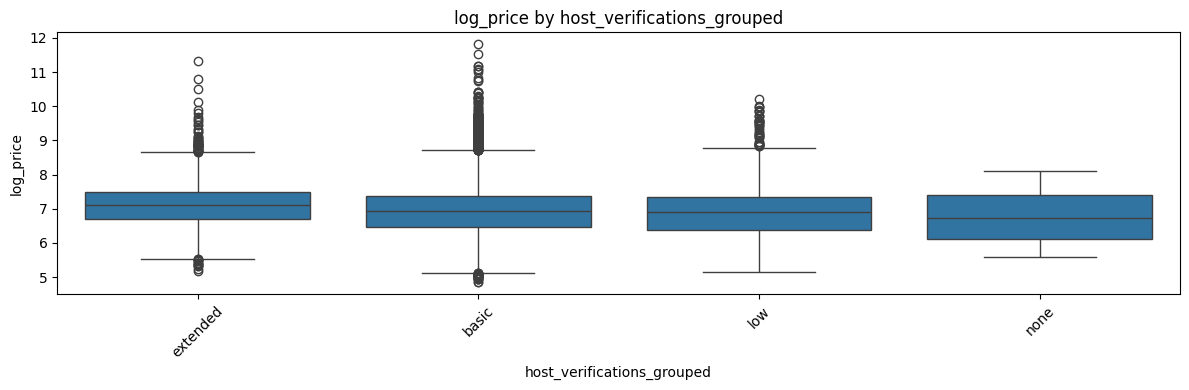

In [151]:
# ====== Host Verifications Analysis ======

# 1. Analysis: host_verifications_count

print("\n===== host_verifications_count Analysis =====")

# Basic stats
print("\nDescriptive Statistics of host_verifications_count:")
print(df_features["host_verifications_count"].describe())

# Value counts
print("\nValue Counts (including NaNs):")
print(df_features['host_verifications_count'].value_counts(dropna=False))

# Correlation with target
corr = df_features["host_verifications_count"].corr(df_features[target])
print(f"\nCorrelation with {target}: {corr:.4f}")

# Binning for interpretability
df_features["host_verifications_count_binned"] = pd.qcut(
    df_features["host_verifications_count"],
    q=4,
    duplicates="drop"
)

print("\nMedian log_price by verification count bins:")
print(df_features.groupby("host_verifications_count_binned")[target].median())

# 2. Analysis: host_verifications_list (raw)

print("\n===== host_verifications_list Analysis =====")

print("\nTop 10 most frequent combinations:")
print(df_features["host_verifications_list"].value_counts().head(10))

# 3. Grouping categories

# Function to group verification types into broader categories
def group_verifications(verif_list):
    if not isinstance(verif_list, list):
        return "unknown"
    
    if len(verif_list) == 0:
        return "none"
    
    if "work_email" in verif_list:
        return "extended"
    
    if set(verif_list) == {"email", "phone"}:
        return "basic"
    
    if len(verif_list) == 1:
        return "low"
    
    return "other"

# Apply grouping
df_features["host_verifications_grouped"] = df_features["host_verifications_list"].apply(group_verifications)

# 4. Analysis: grouped categories
print("\n===== Grouped Verifications Analysis =====")

# Distribution
print("\nValue Counts:")
print(df_features["host_verifications_grouped"].value_counts())

print("\nProportions (%):")
print((df_features["host_verifications_grouped"].value_counts(normalize=True) * 100).round(2))

# Median log_price by group
print("\nMedian log_price by grouped verifications:")
median_vals = df_features.groupby("host_verifications_grouped")[target].median().sort_values(ascending=False)
print(median_vals)

# Optional: difference vs baseline (most common group)
most_common_group = df_features["host_verifications_grouped"].value_counts().idxmax()
baseline = median_vals[most_common_group]

print(f"\nBaseline group: {most_common_group} (median = {baseline:.4f})")

print("\nMedian difference vs baseline:")
print((median_vals - baseline).sort_values())

# Plot boxplot to visualize log_price distribution by host_verifications_grouped
print("\n========== Boxplot of log_price by host_verifications_grouped ==========")
print("")
plot_boxplot(
    df=df_features,
    vars= ['host_verifications_grouped'],
    target= 'log_price'
    )

Se evaluó la variable `host_verifications` a través de dos representaciones:

- `host_verifications_count` (numérica)
- `host_verifications_grouped` (categórica agregada)

El objetivo fue determinar si las verificaciones del host aportan señal relevante

1. Análisis de `host_verifications_count`

La variable presenta una distribución altamente concentrada:

- La media es ≈ 2.02 y la mediana es exactamente 2
- El 50% y el 75% de los valores están en 2
- El rango efectivo es muy limitado (0 a 3)

Esto indica que la mayoría de los hosts tienen exactamente 2 verificaciones, lo que reduce significativamente la variabilidad de la variable.

En términos de relación con el target:

- La correlación con `log_price` es **≈ 0.07**, lo cual es **muy bajo**
- Al agrupar en bins, se observa una diferencia en medianas:
  - ≤2 verificaciones → 6.93  
  - \>2 verificaciones → 7.10  

La variable muestra una ligera tendencia positiva, donde más verificaciones se asocian con precios más altos. Sin embargo, esta señal es débil y limitada por la baja variabilidad estructural, la alta concentración en un solo valor (2) y la escasa capacidad de discriminación global

En la práctica, `host_verifications_count` aporta una señal marginal.


2. Análisis de `host_verifications_list` y agrupación en `host_verifications_grouped`

El análisis de combinaciones muestra una fuerte concentración en pocos patrones:

- **[email, phone]** domina ampliamente (~78%)
- **[email, phone, work_email]** es el segundo grupo (~12%)
- **[phone]** representa otro segmento (~9%)
- El resto son casos residuales

Esto confirma que la variable original tiene alta redundancia estructural, es decir, aunque parece que hay varias combinaciones posibles, en realidad casi todos los datos se repiten en los mismos patrones, con muy poca diversidad real.

Para mejorar interpretabilidad, se agruparon las combinaciones en:

- **basic** (email + phone)
- **extended** (incluye work_email)
- **low** (una sola verificación)
- **none** (sin verificaciones)

La distribución sigue siendo altamente desbalanceada:

- *basic*: ~78% (grupo dominante)
- *extended*: ~12%
- *low*: ~9.6%
- *none*: prácticamente inexistente

En términos de relación con el precio, extended muestra una mediana mayor (+0.17 vs baseline)
- *low* y *none* presentan medianas menores
- La relación es **consistente y ordenada**:
  
  *none < low < basic < extended*

Existe una señal interpretable, más verificaciones (o verificaciones “más completas”) muestran una tendencia a mayor precio y menor nivel de verificación una tendencia a menor precio. Esto sugiere que la variable captura parcialmente una dimensión de confianza o profesionalismo del host. Sin embargo, esta señal tiene limitaciones importantes:

- El grupo dominante (`basic`) concentra la mayoría de observaciones
- Los grupos con mayor señal (`extended`) son relativamente pequeños
- La separación, aunque consistente, no es particularmente fuerte

En general, el análisis muestra que `host_verifications` tiene una señar debil pero coherente:

- Captura una dimensión interpretable (nivel de verificación/confianza)
- Está limitada por:
  - Baja variabilidad
  - Fuerte concentración en pocos valores
  - Impacto moderado en el target

En comparación con otras features analizadas (por ejemplo, amenities o superhost), su capacidad explicativa es claramente menor. Dado su comportamiento, considero que existen dos caminos razonables:

- Mantener `host_verifications_grouped` como una feature categórica simple, ya que podría capturar señales marginales adicionales.
- Descartar completamente la variable si se prioriza simplicidad y reducción de ruido.

La decisión final podría depender de su impacto en la etapa de modelado.



#### Variables sobre el nivel de profesionalización y nivel de operación del host


===== Descriptive Statistics =====

--- host_listings_count ---
count    21545.000000
mean        27.389325
std         85.064936
min          1.000000
25%          2.000000
50%          5.000000
75%         17.000000
max        898.000000
Name: host_listings_count, dtype: float64

--- host_total_listings_count ---
count    21545.000000
mean        37.384822
std        121.080390
min          1.000000
25%          2.000000
50%          6.000000
75%         21.000000
max        964.000000
Name: host_total_listings_count, dtype: float64

--- calculated_host_listings_count ---
count    21547.000000
mean        16.354759
std         34.227301
min          1.000000
25%          1.000000
50%          4.000000
75%         13.000000
max        221.000000
Name: calculated_host_listings_count, dtype: float64

--- calculated_host_listings_count_entire_homes ---
count    21547.000000
mean        13.152829
std         33.658834
min          0.000000
25%          1.000000
50%          2.000000
75% 

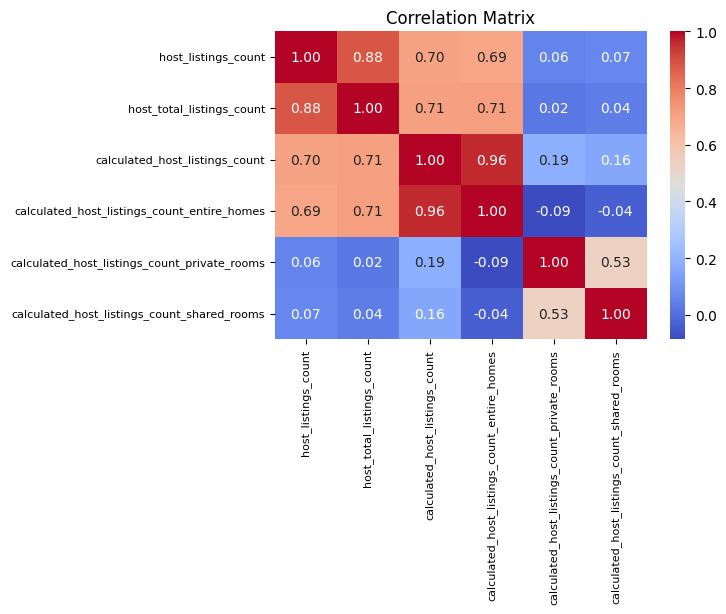

In [152]:
# ====== Host Listings Features Analysis =============

# This block evaluates:
# - Distribution and skewness
# - Correlation with target
# - Redundancy between variables
# - Relationship with log_price (via binning)

target = "log_price"

# 1. Basic distribution analysis

print("\n===== Descriptive Statistics =====")

for col in host_listings_features:
    print(f"\n--- {col} ---")
    print(df_features[col].describe())

# 2. Correlation with target

print("\n===== Correlation with log_price =====")

for col in host_listings_features:
    corr = df_features[col].corr(df_features[target])
    print(f"{col}: {corr:.4f}")

# 3. Distribution shape (skewness)

print("\n===== Skewness Analysis =====")

for col in host_listings_features:
    skew = df_features[col].skew()
    print(f"{col}: {skew:.2f}")

# 4. Binning analysis (relation with target)

print("\n===== Binning Analysis (Median log_price) =====")

for col in host_listings_features:
    print(f"\n--- {col} ---")
    
    unique_vals = df_features[col].nunique()
    
    try:
        if unique_vals > 10:
            df_features[f"{col}_binned"] = pd.qcut(df_features[col], q=5, duplicates="drop")
        else:
            df_features[f"{col}_binned"] = df_features[col]
        
        median_vals = df_features.groupby(f"{col}_binned")[target].median()
        print(median_vals)
        
    except Exception as e:
        print(f"Error in binning: {e}")

# 5. Log transformatio and correlation with target

print("\n===== Log Transformation Check (correlation with target) =====")

for col in host_listings_features:
    if df_features[col].min() >= 0:
        df_features[f"log_{col}"] = np.log1p(df_features[col])
        corr_log = df_features[f"log_{col}"].corr(df_features[target])
        print(f"log_{col}: {corr_log:.4f}")

host_listings_features_log = [
    "log_host_listings_count",
    "log_host_total_listings_count",
    "log_calculated_host_listings_count",
    "log_calculated_host_listings_count_entire_homes",
    "log_calculated_host_listings_count_private_rooms",
    "log_calculated_host_listings_count_shared_rooms"
]

# 6. Redundancy check (correlation matrix)

print("\n===== Correlation Matrix (Feature Redundancy) =====")

corr_matrix = df_features[host_listings_features].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Este grupo de variables busca capturar el nivel de profesionalización y de operatividad del anfitrión en la plataforma a través del número y tipo de propiedades que gestiona. En conjunto, representan la escala de operación del host, pero también podrían introducir redundancia y distribuciones altamente sesgadas que deben tratarse con cuidado.

Se identificaron dos dimensiones principales que reflejan este grupo de variables:

- Escala del host (Conteo general de listings)
- Tipo de inventario (Conteo de listings entire homes, habitaciones privadas o compartidas)

1. Distribución y comportamiento general.

Todas las variables presentan distribuciones altamente sesgadas a la derecha, con valores extremos muy elevados (por ejemplo, hosts con cientos de listings). La mayoría de los hosts tienen pocos listings:

- Medianas bajas (entre 2 y 6 en la mayoría de variables)
- Medias infladas por outliers
- Skewness muy alta (hasta ~9.6)

Esto indica que el mercado está dominado por hosts pequeños, con una minoría de operadores altamente profesionalizados. Esta estructura sugiere que el efecto sobre el precio podría no ser lineal, sino que dependerá de tramos (pequeños vs grandes hosts).

2. Relación con `log_price`

En términos de correlación, se observan patrones interesantes:

- Variables de conteo general(`host_listings_count`, `host_total_listings_count`, `calculated_host_listings_count`) tienen correlaciones positivas pero débiles (~0.10–0.14)
- Variables de conteo por tipo de habitación:
  - `calculated_host_listings_count_entire_homes` destaca con una correlación más alta (~0.20)
  - `calculated_host_listings_count_private_rooms`: correlación negativa (~ -0.19)
  - `calculated_host_listings_count_shared_rooms`: correlación negativa (~ -0.18)

Esto sugiere una diferenciación clara:

- Más listings de tipo **entire home** → mayor precio
- Más listings de tipo **private/shared** → menor precio

Es decir, no solo importa cuántos listings tiene el host, sino qué tipo de inventario maneja.

3. Análisis por bins (relación no lineal)

El binning revela mejor la estructura real. En variables de conteo general, el precio tiende a aumentar con el número de listings, pero de forma no perfectamente monotónica al inicio, el salto relevante ocurre en los bins más altos (hosts grandes), donde sí hay una diferencia clara

En particular:

- `calculated_host_listings_count_entire_homes` muestra una relación creciente fuerte y consistente, desde **~6.71** hasta **~7.23**
- `calculated_host_listings_count_private_rooms` muestra una caída clara en precio al aumentar
- `calculated_host_listings_count_shared_rooms` prácticamente no aporta señal (sin variación útil)

Esto confirma que el efecto está más relacionado con el tipo de propiedad que escala el host, no solo con la cantidad total.

4. Redundancia entre variables

La matriz de correlación muestra redundancia significativa:

- `host_listings_count` y `host_total_listings_count` → **0.88**
- `calculated_host_listings_count` y `calculated_host_listings_count_entire_homes` → **0.96**

Esto implica que varias variables están midiendo esencialmente lo mismo, con ligeras variaciones en definición. Por otro lado, `calculated_host_listings_count_private_rooms` y `calculated_host_listings_count_shared_rooms` están menos correlacionadas con las variables principales

5. Efecto de las transformaciones logarítmicas

La aplicación de log mejora la relación con el target en algunos casos:

- `log_calculated_host_listings_count_entire_homes` alcanza **~0.35**, siendo la señal más fuerte del grupo
- Las variables principales también mejoran ligeramente (~0.15–0.17)
- Las variables negativas (`calculated_host_listings_count_private_rooms`, `calculated_host_listings_count_shared_rooms`) refuerzan su relación inversa

Esto confirma que la relación con el precio es no lineal y que la escala debería comprimirse para capturar mejor la señal.

En este análisis, podemos observar que este grupo de variables no captura simplemente “cantidad de listings”, sino una combinación de nivel de profesionalismo y tipo de portafolio que maneja el host. El hallazgo mas importante es que no todos los listings adicionales aportan igual valor y el tipo de propiedad parece dominar sobre la cantidad total.

- Las variables de conteo general son redundantes y débiles individualmente.
- `calculated_host_listings_count_entire_homes` es la variable más informativa del grupo.
- `calculated_host_listings_count_private_rooms` podría aportar señal inversa útil.
- `calculated_host_listings_count_shared_rooms` tiene muy baja relevancia.


El análisis mostró que estas variables presentan alta redundancia y distribuciones muy sesgadas, por lo que no es conveniente incluirlas todas. En su lugar, se seleccionaría un subconjunto que, según el análisis, captura información clave con menor complejidad. Para el modelo se considerará estas variables que mejor representan las dimensiones de conteo general y que además muestran una relación más clara con el precio:

- `log_calculated_host_listings_count_entire_homes`: Variable con mayor señal y relación positiva clara con el precio.

- `log_calculated_host_listings_count_private_rooms`: Aporta señal inversa, capturando listings más económicos.

- `log_host_total_listings_count`: Representa la escala general en el conteo de listings del host.

El resto de variables se estarían excluyendo debido a la alta correlación con las variables relacionadas, la redundancia en la información que aportan y la menor relación con el target. Esto permitirá reducir la dimensionalidad sin perder capacidad explicativa.

#### Variables sobre el comportamiento del host y la facilidad en la reserva

In [153]:
# ========== host_response_time Analysis ============

# This block evaluates:
# - Distribution (including missing values)
# - Relationship with log_price
# - Ordinal structure (if any)
# - Potential transformation to ordered feature

col = "host_response_time"
target = "log_price"

# 1. Distribution (including NaNs)
print("===== Distribution of host_response_time =====")
print("\nValue Counts (including NaNs):")
counts = df_features[col].value_counts(dropna=False)
print(counts)

print("\nProportions (%):")
proportions = df_features[col].value_counts(normalize=True, dropna=False) * 100
print(proportions.round(2))

# Missing values
print("\nMissing values:")
missing_count = df_features[col].isna().sum()
missing_pct = (missing_count / len(df_features)) * 100
print(f"Missing: {missing_count} ({missing_pct:.2f}%)")

# 2. Median log_price by category
print("\n===== Median log price by category =====")
print("\nMedian log_price by response time:")
median_vals = df_features.groupby(col)[target].median()
print(median_vals)

# 3. Ordering the categories manually
# Define an ordinal mapping based on response speed
response_time_order = {
    "within an hour": 1,
    "within a few hours": 2,
    "within a day": 3,
    "a few days or more": 4
}

df_features["host_response_time_ordinal"] = df_features[col].map(response_time_order)

# 4. Correlation with target (ordinal version)
print("\n===== Correlation with target (ordinal version) =====")
corr = df_features["host_response_time_ordinal"].corr(df_features[target])
print(f"\nCorrelation (ordinal) with {target}: {corr:.4f}")

# 5. Median by ordinal bins (to check monotonicity)
print("\n===== Median log price by ordinal response time =====")
print("\nMedian log_price by ordinal response time:")
median_ord = df_features.groupby("host_response_time_ordinal")[target].median()
print(median_ord)

===== Distribution of host_response_time =====

Value Counts (including NaNs):
host_response_time
within an hour        17007
NaN                    1603
within a few hours     1497
within a day            786
a few days or more      654
Name: count, dtype: int64

Proportions (%):
host_response_time
within an hour        78.93
NaN                    7.44
within a few hours     6.95
within a day           3.65
a few days or more     3.04
Name: proportion, dtype: float64

Missing values:
Missing: 1603 (7.44%)

===== Median log price by category =====

Median log_price by response time:
host_response_time
a few days or more    6.608000
within a day          6.841081
within a few hours    6.703188
within an hour        6.981935
Name: log_price, dtype: float64

===== Correlation with target (ordinal version) =====

Correlation (ordinal) with log_price: -0.0992

===== Median log price by ordinal response time =====

Median log_price by ordinal response time:
host_response_time_ordinal
1.0   

La variable `host_response_time` representa la rapidez con la que un anfitrión responde a solicitudes, lo cual puede influir en la experiencia del usuario y, de forma indirecta, en el precio del listing. Sin embargo, su comportamiento en los datos revela varias limitaciones importantes.

1. Distribución

La variable presenta un **fuerte desbalance**:

- ~79% de los hosts responden *within an hour*
- El resto de categorías tienen una representación mucho menor (<7% cada una)
- Existe un ~7.4% de valores faltantes

Esto implica que la mayoría de los listings pertenecen a hosts altamente responsivos, lo que reduce la capacidad de la variable para discriminar entre diferentes niveles de precio.

2. Relación con `log_price`

Al analizar la mediana de `log_price` por categoría, se observa que:

- Los hosts que responden *within an hour* tienen el precio más alto (~6.98)
- Los más lentos (*a few days or more*) tienen el más bajo (~6.61)
- Las categorías intermedias no siguen un patrón completamente consistente

Aunque hay una tendencia general donde respuestas más rápidas se asocian con precios más altos, esta relación no es completamente estable.

3.  Análisis ordinal

Al transformar la variable en formato ordinal, la correlación con el target es: **r ≈ -0.10**

Esto indica una **relación negativa débil**, donde mayor tiempo de respuesta (peor categoría) se asocia con menor precio. Sin embargo, la magnitud es baja, lo que sugiere que el impacto de esta variable es limitado.

El análisis por niveles ordinales refuerza esta idea:

- Existe una tendencia general decreciente
- Pero no es estrictamente monotónica (por ejemplo, “within a day” no sigue el orden esperado)


En general, la variable captura una señal lógica desde el punto de vista del negocio: hosts más rápidos tienden a ofrecer listings más caros. Sin embargo, en la práctica:

- La señal es **débil**
- La variable está **altamente desbalanceada**
- La relación con el precio es **inconsistente en niveles intermedios**

Esto sugiere que `host_response_time` tiene un impacto marginal en el precio y probablemente esté capturando efectos ya explicados por otras variables (como reputación o calidad del listing).

Aunque la variable muestra cierta coherencia conceptual, su utilidad práctica es limitada debido a naja correlación con el target, fuerte concentración de listings en una sola categoría y falta de una relación monotónica clara. Esta variable podría mantenerse como una variable ordinal simple que podría capturar señales marginales adicionales o excluirla del modelo por simplicidad y reducción de ruido.



In [154]:
# ==================================================
# host_response_rate & host_acceptance_rate Analysis
# ==================================================

# This block evaluates:
# - Cleaning (string % → numeric)
# - Distribution and missing values
# - Correlation with target
# - Binning analysis (non-linear relationships)
# - Comparison between both variables (redundancy)

rate_features = ["host_response_rate", "host_acceptance_rate"]
target = "log_price"

# =========================================
# 1. CLEANING: Convert % strings to numeric
# =========================================

for col in rate_features:  
    # Convert percentage string to float
    df_features[f"{col}_num"] = (
        df_features[col]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

# =========================================
# 2. DISTRIBUTION + MISSING VALUES
# =========================================

for col in rate_features:
    col_num = f"{col}_num"
    
    print(f"\n{'='*40}")
    print(f"Distribution: {col_num}")
    print(f"{'='*40}")
    
    print("\nDescriptive Statistics:")
    print(df_features[col_num].describe())
    
    print("\nMissing values:")
    missing_count = df_features[col_num].isna().sum()
    missing_pct = (missing_count / len(df_features)) * 100
    print(f"Missing: {missing_count} ({missing_pct:.2f}%)")
    
    print("\nValue counts (top values):")
    print(df_features[col_num].value_counts().head(10))

# =========================================
# 3. CORRELATION WITH TARGET
# =========================================

print(f"\n{'='*40}")
print("Correlation with log_price")
print(f"{'='*40}")

for col in rate_features:
    col_num = f"{col}_num"
    corr = df_features[col_num].corr(df_features[target])
    print(f"{col_num}: {corr:.4f}")

# =========================================
# 4. BINNING ANALYSIS
# =========================================

print(f"\n{'='*40}")
print("Binning Analysis (Median log_price)")
print(f"{'='*40}")

for col in rate_features:
    col_num = f"{col}_num"
    col_bin = f"{col}_num_binned"
    
    print(f"\n--- {col_num} ---")
    
    try:
        df_features[col_bin] = pd.qcut(df_features[col_num], q=5, duplicates="drop")
        
        median_vals = df_features.groupby(col_bin)[target].median()
        print(median_vals)
        
    except Exception as e:
        print(f"Error in binning: {e}")

# =========================================
# 5. RELATION BETWEEN BOTH VARIABLES
# =========================================

print(f"\n{'='*40}")
print("Correlation Between Rates")
print(f"{'='*40}")

corr_rates = df_features[[f"{col}_num" for col in rate_features]].corr()
print(corr_rates)


Distribution: host_response_rate_num

Descriptive Statistics:
count    19944.000000
mean        95.071199
std         17.335132
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate_num, dtype: float64

Missing values:
Missing: 1603 (7.44%)

Value counts (top values):
host_response_rate_num
100.0    15502
99.0       887
0.0        435
90.0       408
98.0       381
96.0       328
97.0       189
80.0       175
94.0       129
95.0       117
Name: count, dtype: int64

Distribution: host_acceptance_rate_num

Descriptive Statistics:
count    20530.000000
mean        92.235753
std         19.542165
min          0.000000
25%         96.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_acceptance_rate_num, dtype: float64

Missing values:
Missing: 1017 (4.72%)

Value counts (top values):
host_acceptance_rate_num
100.0    10654
99.0      2692
98.0      1229
97.0       806
96.0      

Las variables `host_response_rate` y `host_acceptance_rate`  representan métricas operativas del anfitrión relacionadas con su nivel de respuesta y disposición a aceptar solicitudes. 

1. Distribución.

Ambas variables presentan una fuerte concentración en valores altos, especialmente en 100%:

- En `host_response_rate`, más del 75% de los valores están en 100%
- En `host_acceptance_rate`, ocurre algo similar, aunque con un poco más de dispersión
- Existen valores en 0%, pero representan una minoría
- Missing values moderados (~7.4% y ~4.7%)

Esto indica una baja variabilidad efectiva, donde la mayoría de los hosts se comportan de manera similar en estas métricas.

2. Relación con el target.

Las correlaciones con el target son:

- `host_response_rate`: ~0.08  
- `host_acceptance_rate`: ~0.12  

Ambas son positivas pero débiles, lo que sugiere que mayores tasas se asocian con precios ligeramente más altos, aunque el efecto es muy limitado.

El análisis por bins refuerza esta idea:

- En ambos casos, los grupos con tasas más altas tienen mayor `log_price`
- La relación es más clara en `host_acceptance_rate`, donde se observa una progresión más consistente entre bins
- En `host_response_rate`, la separación es más simple (básicamente 100% vs resto)

3. Correlación entre ambas variables.

La correlación entre ambas variables es **r ≈ 0.69**. Esto indica una relación moderadamente alta, lo que sugiere que ambas capturan comportamientos similares del host. Sin embargo, no son completamente redundantes, ya que `acceptance_rate` muestra mayor variabilidad y `response_rate` está más concentrada en 100%


Estas variables reflejan un aspecto operativo del host, pero en la práctica la mayoría de los hosts tienen tasas muy altas, la variabilidad es limitada y la relación con el precio es débil. Esto sugiere que estas métricas no son un factor determinante en el precio, sino más bien una condición casi estándar dentro del dataset.

En conclusión:

- Ambas variables presentan señal débil pero consistente
- `host_acceptance_rate` es ligeramente más informativa que `host_response_rate`
- Existe redundancia parcial entre ambas

Dado su comportamiento, se podría considerar `host_acceptance_rate` por su mayor variabilidad y señal con el precio y excluir `host_response_rate` para evitar redundancia. En general, estas variables pueden aportar señal marginal, pero no justifican un peso importante dentro del modelo.

In [155]:
# =========================================
# instant_bookable Analysis
# =========================================

# This block evaluates:
# - Distribution and imbalance
# - Relationship with log_price
# - Median difference
# - Correlation with target (binary encoding)

col = "instant_bookable"
target = "log_price"

# =========================================
# 1. DISTRIBUTION (INCLUDING NaNs)
# =========================================

print(f"\n{'='*40}")
print("Distribution")
print(f"{'='*40}")

print("\nValue Counts (including NaNs):")
counts = df_features[col].value_counts(dropna=False)
print(counts)

print("\nProportions (%):")
proportions = df_features[col].value_counts(normalize=True, dropna=False) * 100
print(proportions.round(2))

missing_count = df_features[col].isna().sum()
missing_pct = (missing_count / len(df_features)) * 100

print("\nMissing values:")
print(f"Missing: {missing_count} ({missing_pct:.2f}%)")

# =========================================
# 2. MEDIAN log_price BY CATEGORY
# =========================================

print(f"\n{'='*40}")
print("Relation with target")
print(f"{'='*40}")

print("\nMedian log_price by instant_bookable:")
median_vals = df_features.groupby(col)[target].median()
print(median_vals)

# Median difference
if "t" in median_vals and "f" in median_vals:
    diff = median_vals["t"] - median_vals["f"]
    print(f"\nMedian Difference (t - f): {diff:.4f}")


Distribution

Value Counts (including NaNs):
instant_bookable
f    11709
t     9838
Name: count, dtype: int64

Proportions (%):
instant_bookable
f    54.34
t    45.66
Name: proportion, dtype: float64

Missing values:
Missing: 0 (0.00%)

Relation with target

Median log_price by instant_bookable:
instant_bookable
f    6.866933
t    7.044033
Name: log_price, dtype: float64

Median Difference (t - f): 0.1771


La variable `instant_bookable` indica si un listing puede reservarse de forma inmediata sin aprobación del anfitrión. A diferencia de otras variables de comportamiento, esta representa una decisión directa sobre la operación del listing, lo que la hace potencialmente más relevante.

1. Distribución

La variable presenta una distribución bastante balanceada:

- ~54% no permiten reserva instantánea  
- ~46% sí la permiten  
- No hay valores faltantes  

Esto es importante, ya que permite una comparación confiable entre ambos grupos sin problemas de desbalance o sesgo estructural.

2.  Relación con `log_price`

El análisis de medianas muestra una diferencia clara:

- Listings sin instant booking → ~6.87  
- Listings con instant booking → ~7.04  

La diferencia es de aproximadamente 0.18 en log_price, lo cual es relevante en términos prácticos. i lo llevamos a precios reales (exponenciando), esa diferencia equivale aproximadamente a un ~20% más en precio para listings con instant bookable. Esta separación indica que los listings que permiten reserva inmediata tienden a estar en un segmento de mayor precio.

A diferencia de otras variables de comportamiento del host, `instant_bookable` muestra una señal clara, consistente y estable:

- La diferencia entre grupos es significativa
- No depende de subgrupos pequeños o distribuciones sesgadas
- La interpretación es directa

Esta variable probablemente está capturando factores como mayor profesionalización del host, opimización para conversión (menos fricción) y experiencia más fluida para el usuario. También podría estar asociada indirectamente con listings mejor gestionados o con mayor demanda.

`instant_bookable` es una variable con buena distribución, diferencia clara en el target e interpretación sencilla. Aporta señal real sin introducir complejidad.

